In [1]:
# !pip install --upgrade numpy scipy

In [2]:
# !jupyter --version

In [3]:
# !pip install numpy scipy

In [4]:
import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import root_scalar
from scipy.special import erf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
from scipy.special import erfc

# Reference Petromod

In [5]:
# Параметры задачи
kappa = 1.234e-6  # м^2/с
T_swi = 0         # °C
T_b = 1333        # °C
h_c = 30e3        # м
h_m = 95e3        # м
h0 = h_c + h_m    # начальная толщина литосферы, м
lmbd = 2.6        # Вт/м/К
q0 = lmbd * (T_b - T_swi) / h0  # исходный тепловой поток, Вт/м^2


"""
Модель 1 

"""
ts_My = 120        # млн лет
t_max_My = 130
beta = 1.2
time_points_m1 = np.array([6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 
                        108, 114, 120, 121, 122, 123, 124, 125, 126,127, 128, 129, 130])
heat_flow_m1 = np.array([26.97, 27.43, 27.93, 28.45, 29.02, 29.62, 30.26, 30.94, 31.67, 32.45, 33.28, 34.16, 
             35.09, 36.06, 37.08, 38.12, 39.17, 40.19, 41.13, 41.89, 39.01, 36.3, 33.76, 31.39, 
             29.17, 27.11, 25.2, 23.43, 21.79, 20.28])


"""
Модель 2 

"""
ts_My = 120        # млн лет
t_max_My = 130
beta = 6
time_points_m2 = np.array([2.45, 4.9, 7.35, 9.8, 12.25, 14.7, 17.15, 19.6, 22.05, 24.5, 26.95, 29.4, 31.85, 34.3, 36.75, 
                        39.2, 41.65, 44.1, 46.55, 49, 49.1, 49.2, 49.3, 49.4, 49.5, 49.6, 49.7, 49.8, 49.9, 50])
heat_flow_m2 = np.array([46.78, 47.92, 49.15, 50.48, 51.93, 53.51, 55.24, 57.14, 59.27, 61.64, 64.33, 67.4, 70.95, 
                          75.14, 80.16, 86.34, 94.24, 104.86, 120.4, 146.18, 121.38, 100.01, 81.98, 67.03, 54.78, 44.81,
                          36.71, 30.1, 24.7, 20.28])

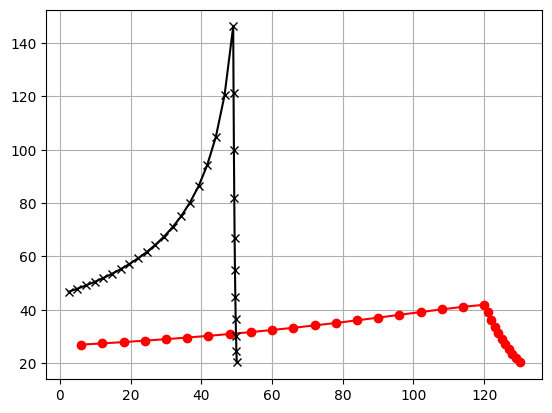

In [6]:
plt.plot(time_points_m1, heat_flow_m1, marker='o', color='red', label='beta=1.2')
plt.plot(time_points_m2, heat_flow_m2, marker='x', color='black', label='beta=6')
plt.grid()

# Initial Data

In [7]:
# # Параметры задачи
# kappa = 1.23e-6  # м^2/с
# T_swi = 0         # °C
# T_b = 1333        # °C
# h_c = 30e3        # м
# h_m = 95e3        # м
# h0 = h_c + h_m    # начальная толщина литосферы, м
# ts_My = 50        # млн лет
# t_max_My = 130
# lmbd = 2.6        # Вт/м/К
# q0 = lmbd * (T_b - T_swi) / h0  # исходный тепловой поток, Вт/м^2

# # Переводим ts в секунды
# My_to_s = 1e6 * 365.25 * 24 * 3600
# t_My = np.linspace(0, t_max_My, 500)
# t_sec = t_My * My_to_s
# ts_sec = ts_My * My_to_s

# # Stretching factors
# betas = [2, 3, 4, 5, 6]


# Параметры задачи
kappa = 0.80410e-6  # м^2/с
T_swi = 0         # °C
T_b = 1333        # °C
h_c = 30e3        # м
h_m = 95e3        # м
h0 = h_c + h_m    # начальная толщина литосферы, м
ts_My = 50        # млн лет
t_max_My = 100
lmbd = 3.5        # Вт/м/К
beta=beta_c=beta_m = 2
q0 = lmbd * (T_b - T_swi) / h0  # исходный тепловой поток, Вт/м^2

# Переводим ts в секунды
My_to_s = 1e6 * 365.25 * 24 * 3600
t_My = np.linspace(0, t_max_My, 500)
t_sec = t_My * My_to_s
ts_sec = ts_My * My_to_s

# Stretching factors
betas = [2, 3, 4, 5, 6]

# Cooling 

## One layer mode: Crust - Mantle

### Формула расчёта теплового потока для модели растяжения литосферы

Исходная формула теплового потока:

$$
Q(t, \beta) = \frac{\lambda T_1}{a} \left[1 + 2 \sum_{n=1}^{\infty} \frac{\beta}{n\pi} \sin\left(\frac{n\pi}{\beta}\right) \exp\left(-\frac{n^2 t}{\tau}\right)\right]
$$

где

$$
\tau = \frac{a^2}{\kappa \pi^2}, \quad \kappa = \frac{k}{\rho c_p}
$$

---

#### Условия из кода

| Условие                                 | Описание                                                                                         |
|----------------------------------------|------------------------------------------------------------------------------------------------|
| Время растяжения $( t_{stretching} )$ | Вводит сдвиг по времени в экспоненту:                                                          |
|                                        | $(\displaystyle \exp\left(-\frac{n^2 (t - t_{stretching})}{\tau}\right), \quad t \geq t_{stretching})$ |
|                                        | При $( t < t_{stretching})$ тепловой поток считается равным начальному или нулю.                |
| Число членов ряда                      | Если $( t_{stretching} \leq 30 )$ млн лет — суммируем ряд Фурье с \( n=1..N \) (например, \(N=100\)).  |
|                                        | Если $( t_{stretching} > 30 $) млн лет — учитываем только первый член ряда \( n=1 \).           |

---

#### Физические параметры

| Параметр                  | Обозначение      | Единицы измерения       | Пример значения                |
|---------------------------|------------------|------------------------|-------------------------------|
| Теплопроводность          | $\lambda$        | Вт/(м·K)               | 2.6                           |
| Температура астеносферы   | $T_1$            | Кельвины (K)           | $1333 + 273.15 = 1606.15$     |
| Толщина литосферы         | $a$              | Метры (м)              | $125 \times 10^3$             |
| Коэффициент теплопроводности | $k$              | м$^2$/с                | $1.234 \times 10^{-6}$        |
| Плотность                 | $\rho$           | кг/м$^3$               | (зависит от материала)         |
| Удельная теплоёмкость     | $c_p$            | Дж/(кг·K)              | (зависит от материала)         |

---

#### Итоговая формула с учётом условий

$$
Q(t, \beta) = \frac{\lambda T_1}{a} \left[ 1 + 2 \cdot F(t, \beta, t_{stretching}) \right]
$$

где **(аналитический вид)**

$$
F(t, \beta, t_{stretching}) = 
\begin{cases}
\displaystyle \sum_{n=1}^{N} \frac{\beta}{n\pi} \sin\left(\frac{n\pi}{\beta}\right) \exp\left(-\frac{n^2 (t - t_{stretching})}{\tau}\right), & t \geq t_{stretching}, \quad t_{stretching} \leq 30 \\
\\
\displaystyle \frac{\beta}{\pi} \sin\left(\frac{\pi}{\beta}\right) \exp\left(-\frac{(t - t_{stretching})}{\tau}\right), & t \geq t_{stretching}, \quad t_{stretching} > 30 \\
\\
0, & t < t_{stretching}
\end{cases}
$$

где **(численный вид)**

$$
b_n = \frac{2}{a T_1} \int_0^a \left[ T(z, \Delta t) + T_1 \left(\frac{z}{a} - 1\right) \right] \sin\left(\frac{n \pi z}{a}\right) \, dz
$$

где:

- $b_n$ — коэффициент ряда Фурье,
- $a$ — толщина литосферы (в сантиметрах),
- $T_1$ — температура астеносферы (в градусах Цельсия),
- $T(z, \Delta t)$ — температурный профиль в литосфере на глубине $z$ и времени после растяжения $\Delta t$ (°C),
- $z$ — глубина (в сантиметрах),
- $n$ — номер гармонического члена ряда Фурье,
- $\pi$ — число пи (≈ 3.14159).


---

#### Пояснения

- Времена $( t )$ и $( t_{stretching} )$ должны быть согласованы по единицам с $tau$ (секунды или миллионы лет).

- Термическая постоянная времени:

  $$
  \tau = \frac{a^2}{\kappa \pi^2}, \quad \kappa = \frac{k}{\rho c_p}
  $$

- При $( t < t_{stretching} )$ тепловой поток не меняется (можно считать равным начальному или нулю).

---

#### Комментарии
Формулы запичаны по статьям:
* McKenzie, SOME REMARKS ON THE DEVELOPMENT OF SEDIMENTARY BASINS, 1977
* McKenzie, SEDIMENTARY BASIN FORMATION WITH FINITE EXTENSION RATES, 1979


[  0.          11.11111111  22.22222222  33.33333333  44.44444444
  55.55555556  66.66666667  77.77777778  88.88888889 100.        ] [40.09018978 40.18277223 40.10677671 39.74506858 39.13431757 38.42695381
 37.72874331 37.0902214  36.52881681 36.04561564]


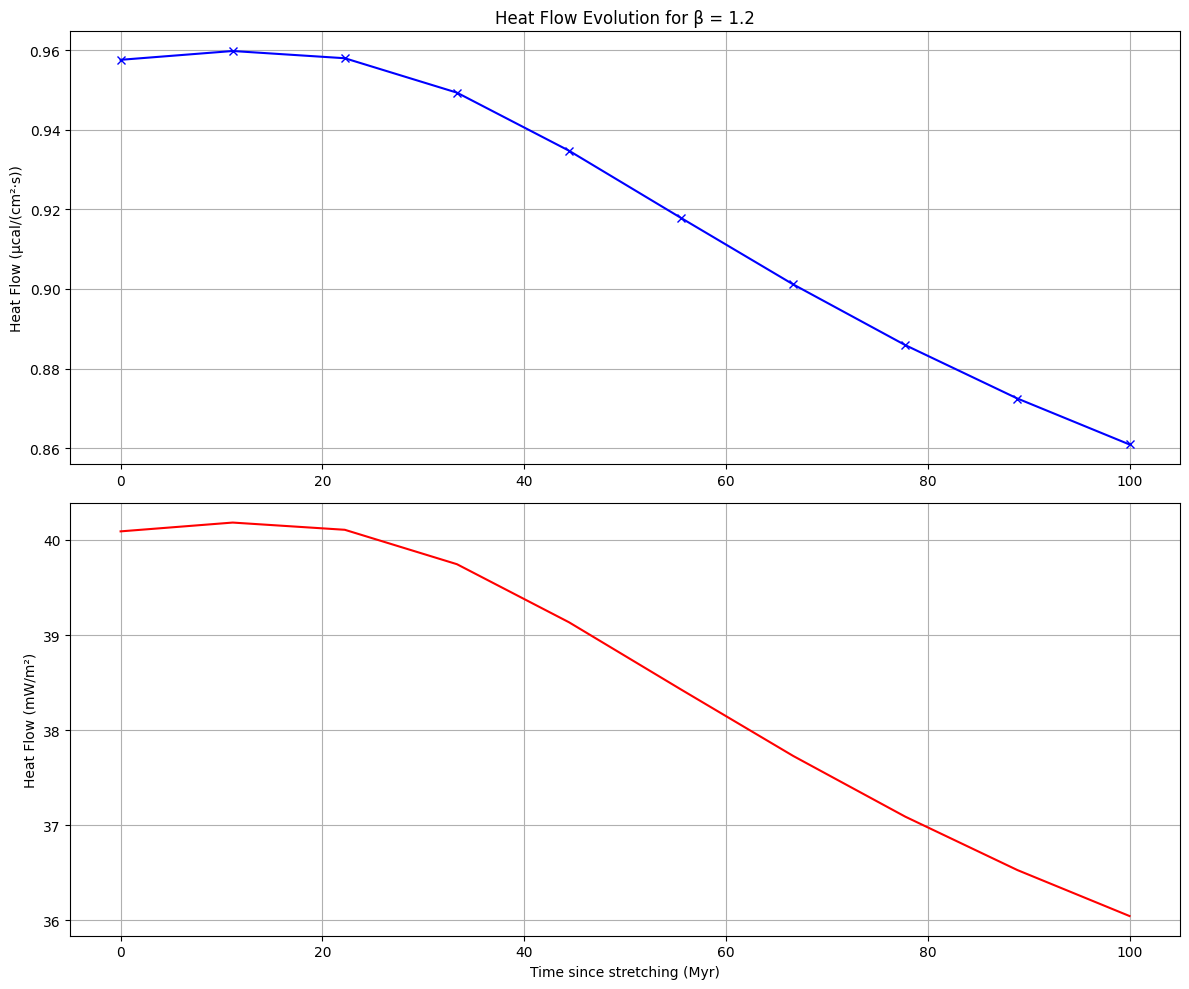

In [8]:
import numpy as np
from typing import Union
import matplotlib.pyplot as plt

def heat_flow_fundament_calculation(
    beta: float,
    t: Union[float, np.ndarray],  # Time in MILLION YEARS (Myr)!
    Q_const: float = 63e-3,       # Constant heat flow (W/m²)
    constant: bool = False,       # Flag to return Q_const
    a: float = 1.25e7,          # Lithosphere thickness (cm)
    k: float = 0.00804,          # Thermal diffusivity (cm²/s)
    lam: float = 0.0075,         # Thermal conductivity (cal/(°C·cm·s))
    T1: float = 1333,            # Asthenosphere temperature (°C)
    n_terms: int = 100           # Number of Fourier terms
) -> Union[float, np.ndarray]:
    """
    Calculate heat flow for lithospheric stretching models.
    All time values must be in MILLION YEARS (Myr).
    Returns both µcal/(cm²·s) and mW/m².
    """
    if constant:
        heat_flux_mucal = Q_const * 1e7 / 4.184  # Convert to µcal/(cm²·s)
        heat_flux_mw = Q_const * 1e3             # Convert to mW/m²
        return heat_flux_mucal, heat_flux_mw

    # Input validation
    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if np.any(t < 0):
        raise ValueError("Time t must be non-negative")

    # Convert units for calculations
    MYR_TO_S = 1e6 * 3.154e7  # 1 Myr = 3.154e13 s
    a_cm = a                  # a already in cm
    k_cm2s = k                # k already in cm²/s

    # Calculate time constant in Myr
    tau_s = (a_cm**2) / (np.pi**2 * k_cm2s)  # Time constant in seconds
    tau_myr = tau_s / MYR_TO_S                # Convert to Myr (~39.7 Myr for default params)

    # Vectorized Fourier series calculation (all times in Myr)
    n = np.arange(1, n_terms + 1)
    exponent = -np.outer(n**2, t) / tau_myr
    sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
    Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
    F_sum = np.sum(Cn, axis=0)

    # Calculate heat flow in both units
    heat_flux_cal = (lam * T1 / a_cm) * (1 + 2 * F_sum)  # cal/(cm²·s)
    heat_flux_mucal = heat_flux_cal * 1e6               # µcal/(cm²·s)
    heat_flux_mw = heat_flux_cal * 41868                # mW/m²

    print(t, heat_flux_mw*1e3)
    return heat_flux_mucal, heat_flux_mw

# Time array in Myr (0-10 Myr with 1000 points)
t_myr = np.linspace(0, 100, 10)

# Calculation for β=6
beta = 1.2
heat_flux_mucal, heat_flux_mw = heat_flow_fundament_calculation(beta=beta, t=t_myr)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: µcal/(cm²·s)
ax1.plot(t_myr, heat_flux_mucal, 'b-', linewidth=1.5, marker='x')
ax1.set_title(f"Heat Flow Evolution for β = {beta}")
ax1.set_ylabel("Heat Flow (µcal/(cm²·s))")
ax1.grid(True)

# Plot 2: mW/m²
ax2.plot(t_myr, heat_flux_mw*1e3, 'r-', linewidth=1.5)
ax2.set_xlabel("Time since stretching (Myr)")
ax2.set_ylabel("Heat Flow (mW/m²)")
ax2.grid(True)

plt.tight_layout()
plt.show()

### Example: McKenzie,SOME REMARKS ON THE DEVELOPMENT OF SEDIMENTARY BASINS, 1977
- Initial data -->  Table 1. Values of parameters used (mostly taken from Parsons and
Sclater [9])
- Equtions --> (7) & (9)
- Figure 2 --> Heat flux as a function of time for various values of $\beta$,
obtained from equation (7)

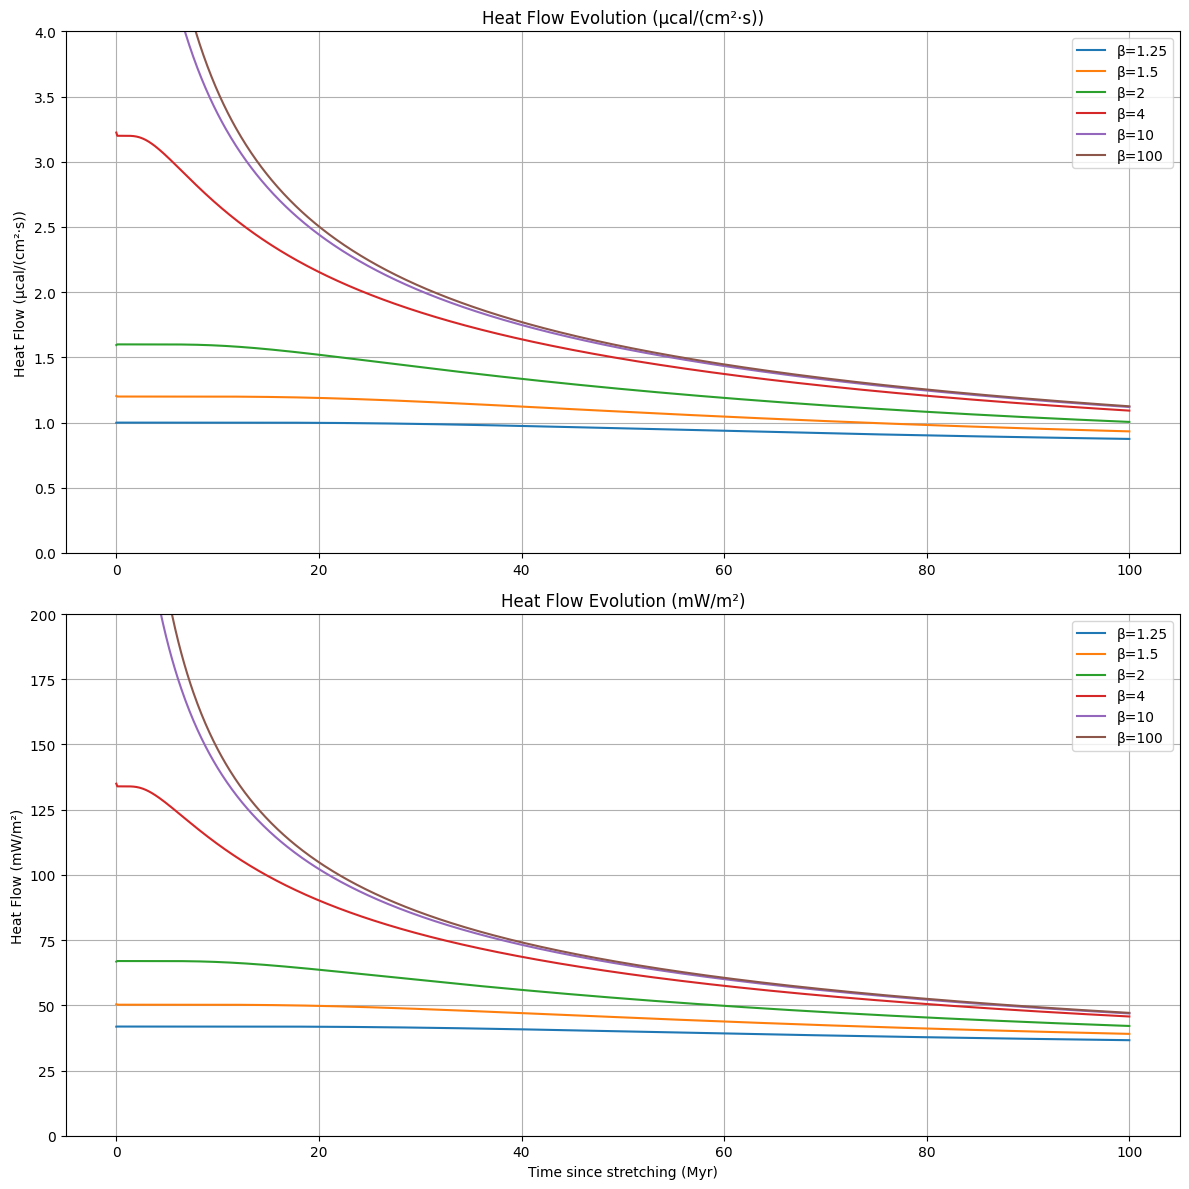

In [9]:
import numpy as np
from typing import Union
import matplotlib.pyplot as plt

def heat_flow_fundament_calculation(
    beta: float,
    t: Union[float, np.ndarray],  # Time in MILLION YEARS (Myr)!
    Q_const: float = 63e-3,       # Constant heat flow (W/m²)
    constant: bool = False,       # Flag to return Q_const
    a: float = 1.25e7,          # Lithosphere thickness (cm)
    k: float = 0.00804,          # Thermal diffusivity (cm²/s)
    lam: float = 0.0075,         # Thermal conductivity (cal/(°C·cm·s))
    T1: float = 1333,            # Asthenosphere temperature (°C)
    n_terms: int = 100           # Number of Fourier terms
) -> Union[float, np.ndarray]:
    """
    Calculate heat flow for lithospheric stretching models.
    All time values must be in MILLION YEARS (Myr).
    Returns both µcal/(cm²·s) and mW/m².
    """
    if constant:
        heat_flux_mucal = Q_const * 1e7 / 4.184  # Convert to µcal/(cm²·s)
        heat_flux_mw = Q_const * 1e3             # Convert to mW/m²
        return heat_flux_mucal, heat_flux_mw

    # Input validation
    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if np.any(t < 0):
        raise ValueError("Time t must be non-negative")

    # Convert units for calculations
    MYR_TO_S = 1e6 * 3.154e7  # 1 Myr = 3.154e13 s
    a_cm = a                  # a already in cm
    k_cm2s = k                # k already in cm²/s

    # Calculate time constant in Myr
    tau_s = (a_cm**2) / (np.pi**2 * k_cm2s)  # Time constant in seconds
    tau_myr = tau_s / MYR_TO_S                # Convert to Myr (~39.7 Myr for default params)

    # Vectorized Fourier series calculation (all times in Myr)
    n = np.arange(1, n_terms + 1)
    exponent = -np.outer(n**2, t) / tau_myr
    sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
    Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
    F_sum = np.sum(Cn, axis=0)

    # Calculate heat flow in both units
    heat_flux_cal = (lam * T1 / a_cm) * (1 + 2 * F_sum)  # cal/(cm²·s)
    heat_flux_mucal = heat_flux_cal * 1e6               # µcal/(cm²·s)
    heat_flux_mw = heat_flux_cal * 41868                # mW/m²

    return heat_flux_mucal, heat_flux_mw

# Time array in Myr (0-100 Myr with 1000 points)
t_myr = np.linspace(0, 100, 1000)

# Beta values to analyze
betas = [1.25, 1.5, 2, 4, 10, 100]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Calculate and plot for each beta
for beta in betas:
    heat_flux_mucal, heat_flux_mw = heat_flow_fundament_calculation(beta=beta, t=t_myr)
    
    # Plot 1: µcal/(cm²·s)
    ax1.plot(t_myr, heat_flux_mucal, '-', linewidth=1.5, label=f'β={beta}')
    
    # Plot 2: mW/m²
    ax2.plot(t_myr, heat_flux_mw*1e3, '-', linewidth=1.5, label=f'β={beta}')

# Format µcal plot
ax1.set_title("Heat Flow Evolution (µcal/(cm²·s))")
ax1.set_ylabel("Heat Flow (µcal/(cm²·s))")
ax1.grid(True)
ax1.legend()
ax1.set_ylim(0, 4)  # Adjusted range

# Format mW/m² plot
ax2.set_title("Heat Flow Evolution (mW/m²)")
ax2.set_xlabel("Time since stretching (Myr)")
ax2.set_ylabel("Heat Flow (mW/m²)")
ax2.grid(True)
ax2.legend()
ax2.set_ylim(0, 200)  # Typical geological range

plt.tight_layout()
plt.show()

### Comparison: McKenzie Vs. Petromod

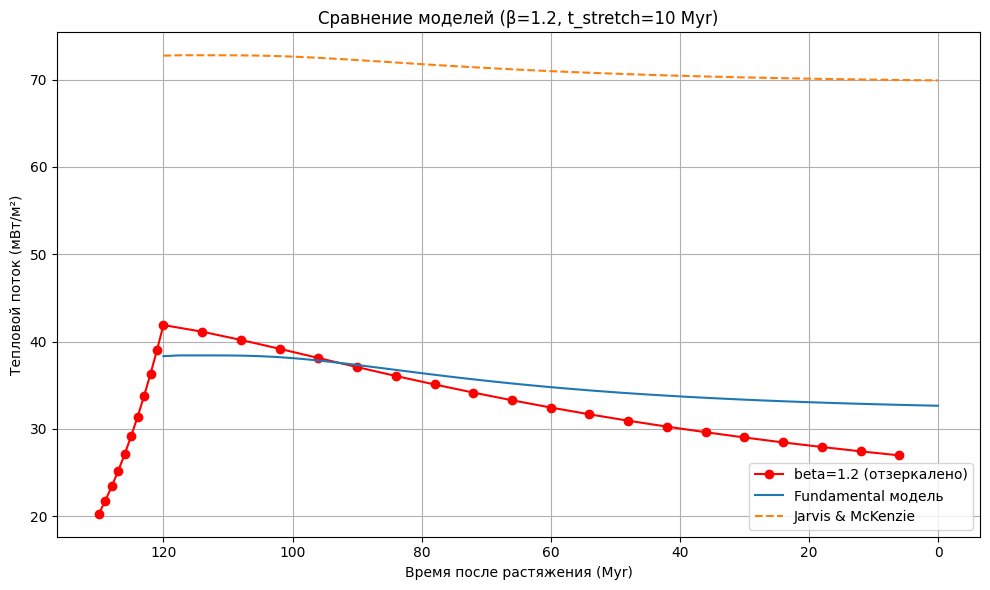

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special

# Исходные значения
k_m2_s = 1.234e-6      # м²/с
lam_w_mk = 3           # Вт/(м·K)

# Перевод термодиффузии: м²/с → см²/с
k_cm2_s = k_m2_s * 1e4

# Перевод теплопроводности: Вт/(м·K) → кал/(см·с·°C)
lam_cal_cmC_s = lam_w_mk * 0.239005736 / 100

def heat_flow_fundament_calculation(beta, t, t_stretching, Q_const=63e-3, a=1.25e7, 
                                  k=k_cm2_s, lam=lam_cal_cmC_s, T1=1333, n_terms=100):
    """Расчёт теплового потока для моделей растяжения литосферы"""
    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if np.any(t < 0):
        raise ValueError("Time t must be non-negative")
    if t_stretching < 0:
        raise ValueError("Stretching time t_stretching must be non-negative")

    MYR_TO_S = 1e6 * 3.154e7
    tau_s = (a**2) / (np.pi**2 * k)
    tau_myr = tau_s / MYR_TO_S

    if t_stretching <= 30:
        n = np.arange(1, n_terms + 1)
        exponent = -np.outer(n**2, (t - t_stretching)) / tau_myr
        sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
        Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
        F_sum = np.sum(Cn, axis=0)
    else:
        n = 1
        exponent = -n**2 * (t - t_stretching) / tau_myr
        sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
        F_sum = (beta * sin_term) * np.exp(exponent)

    heat_flux_cal = (lam * T1 / a) * (1 + 2 * F_sum)
    return heat_flux_cal * 41868  # мВт/м²

def heat_flow_jarvis_mckenzie(beta, t, t_stretching, a=1.25e7, kappa=k_cm2_s, 
                             lam=lam_cal_cmC_s, T1=1333):
    """Модель Jarvis & McKenzie с исправлением размерностей"""
    MYR_TO_S = 1e6 * 3.154e7
    G = np.log(beta) / (t_stretching * MYR_TO_S)
    G_prime = (a**2 * G) / kappa
    
    steady_term = np.sqrt(2 * G_prime / np.pi) / scipy.special.erf(np.sqrt(G_prime / 2))
    
    tau = a**2 / (np.pi**2 * kappa)
    tau_myr = tau / MYR_TO_S
    
    # Исправление: учитываем размерности массивов
    n = np.arange(1, 101)
    t_rel = np.atleast_1d(t - t_stretching)
    exponent = -np.outer(n**2, t_rel) / tau_myr
    
    fourier_terms = (beta / (n * np.pi)) * np.sin(n * np.pi / beta)
    fourier_term = np.sum(fourier_terms[:, np.newaxis] * np.exp(exponent), axis=0)
    
    heat_flow_cal = (lam * T1 / a) * (steady_term + fourier_term)
    return heat_flow_cal * 41868  # мВт/м²

# Параметры для расчета
beta = 1.2
t_myr = np.linspace(10, 130, 50)
t_stretching = 10

# Расчет тепловых потоков
heat_flow_1 = heat_flow_fundament_calculation(beta=beta, t=t_myr, t_stretching=t_stretching) * 1e3
heat_flow_2 = heat_flow_jarvis_mckenzie(beta=beta, t=t_myr, t_stretching=t_stretching) * 1e3


# Визуализация
plt.figure(figsize=(10, 6))

plt.plot(time_points_m1, heat_flow_m1, marker='o', color='red', label='beta=1.2 (отзеркалено)')  # Отзеркалено по X
plt.gca().invert_xaxis()  # Инвертирует ось X

plt.plot((t_myr - t_stretching)[::-1], heat_flow_1, label='Fundamental модель')
plt.plot((t_myr - t_stretching)[::-1], heat_flow_2, '--', label='Jarvis & McKenzie')

plt.xlabel('Время после растяжения (Myr)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title(f'Сравнение моделей (β={beta}, t_stretch={t_stretching} Myr)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

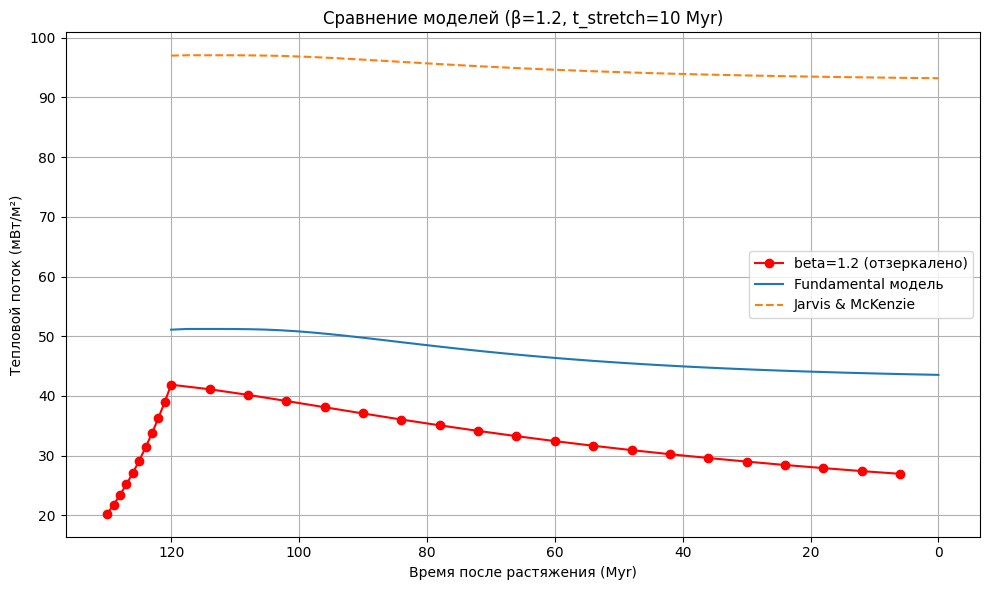

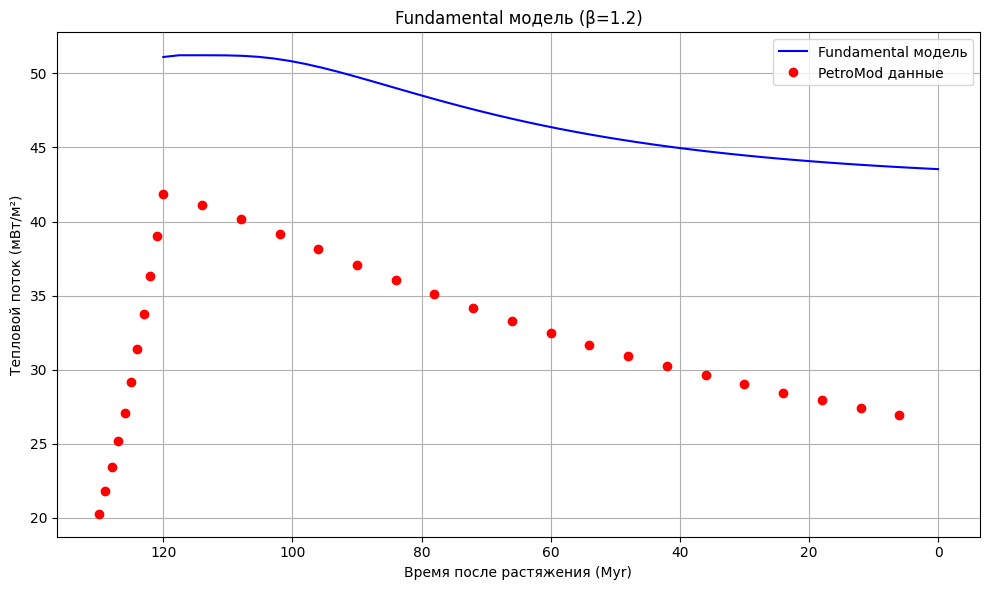

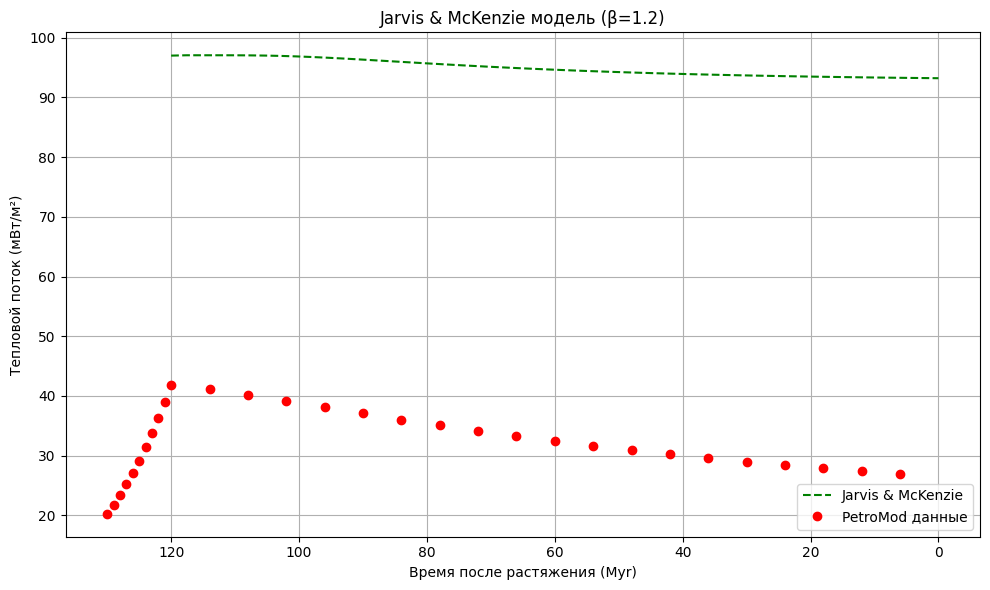

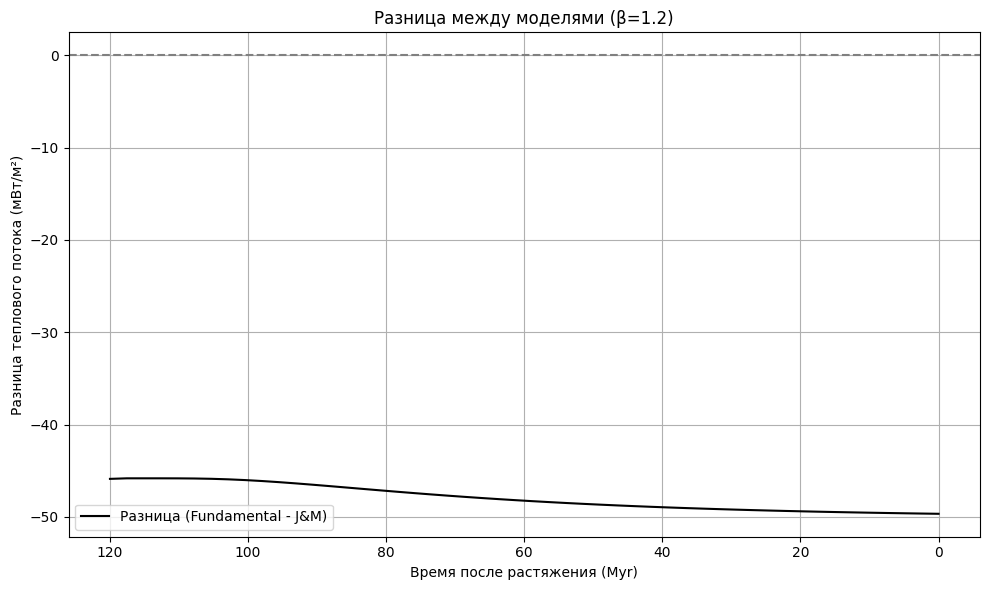

Все графики сохранены в папку: thermal_flow_plots


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
import os

# Создаем папку для сохранения графиков
output_dir = "thermal_flow_plots"
os.makedirs(output_dir, exist_ok=True)

# Исходные значения
k_m2_s = 1.234e-6      # м²/с
lam_w_mk = 4           # Вт/(м·K)

# Перевод термодиффузии: м²/с → см²/с
k_cm2_s = k_m2_s * 1e4

# Перевод теплопроводности: Вт/(м·K) → кал/(см·с·°C)
lam_cal_cmC_s = lam_w_mk * 0.239005736 / 100

def heat_flow_fundament_calculation(beta, t, t_stretching, Q_const=63e-3, a=1.25e7, 
                                  k=k_cm2_s, lam=lam_cal_cmC_s, T1=1333, n_terms=100):
    """Расчёт теплового потока для моделей растяжения литосферы"""
    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if np.any(t < 0):
        raise ValueError("Time t must be non-negative")
    if t_stretching < 0:
        raise ValueError("Stretching time t_stretching must be non-negative")

    MYR_TO_S = 1e6 * 3.154e7
    tau_s = (a**2) / (np.pi**2 * k)
    tau_myr = tau_s / MYR_TO_S

    if t_stretching <= 30:
        n = np.arange(1, n_terms + 1)
        exponent = -np.outer(n**2, (t - t_stretching)) / tau_myr
        sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
        Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
        F_sum = np.sum(Cn, axis=0)
    else:
        n = 1
        exponent = -n**2 * (t - t_stretching) / tau_myr
        sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
        F_sum = (beta * sin_term) * np.exp(exponent)

    heat_flux_cal = (lam * T1 / a) * (1 + 2 * F_sum)
    return heat_flux_cal * 41868  # мВт/м²

def heat_flow_jarvis_mckenzie(beta, t, t_stretching, a=1.25e7, kappa=k_cm2_s, 
                             lam=lam_cal_cmC_s, T1=1333):
    """Модель Jarvis & McKenzie с исправлением размерностей"""
    MYR_TO_S = 1e6 * 3.154e7
    G = np.log(beta) / (t_stretching * MYR_TO_S)
    G_prime = (a**2 * G) / kappa
    
    steady_term = np.sqrt(2 * G_prime / np.pi) / scipy.special.erf(np.sqrt(G_prime / 2))
    
    tau = a**2 / (np.pi**2 * kappa)
    tau_myr = tau / MYR_TO_S
    
    # Исправление: учитываем размерности массивов
    n = np.arange(1, 101)
    t_rel = np.atleast_1d(t - t_stretching)
    exponent = -np.outer(n**2, t_rel) / tau_myr
    
    fourier_terms = (beta / (n * np.pi)) * np.sin(n * np.pi / beta)
    fourier_term = np.sum(fourier_terms[:, np.newaxis] * np.exp(exponent), axis=0)
    
    heat_flow_cal = (lam * T1 / a) * (steady_term + fourier_term)
    return heat_flow_cal * 41868  # мВт/м²

# Параметры для расчета
beta = 1.2
t_myr = np.linspace(10, 130, 50)
t_stretching = 10

# Расчет тепловых потоков
heat_flow_1 = heat_flow_fundament_calculation(beta=beta, t=t_myr, t_stretching=t_stretching) * 1e3
heat_flow_2 = heat_flow_jarvis_mckenzie(beta=beta, t=t_myr, t_stretching=t_stretching) * 1e3

# 1. Основной график сравнения моделей
plt.figure(figsize=(10, 6))
plt.plot(time_points_m1, heat_flow_m1, marker='o', color='red', label='beta=1.2 (отзеркалено)')
plt.gca().invert_xaxis()
plt.plot((t_myr - t_stretching)[::-1], heat_flow_1, label='Fundamental модель')
plt.plot((t_myr - t_stretching)[::-1], heat_flow_2, '--', label='Jarvis & McKenzie')
plt.xlabel('Время после растяжения (Myr)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title(f'Сравнение моделей (β={beta}, t_stretch={t_stretching} Myr)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/comparison_plot.png", dpi=300)
plt.show()

# 2. Отдельный график для Fundamental модели
plt.figure(figsize=(10, 6))
plt.plot((t_myr - t_stretching)[::-1], heat_flow_1, 'b-', label='Fundamental модель')
plt.plot(time_points_m1, heat_flow_m1, 'ro', label='PetroMod данные')
plt.gca().invert_xaxis()
plt.xlabel('Время после растяжения (Myr)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title(f'Fundamental модель (β={beta})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/fundamental_model.png", dpi=300)
plt.show()

# 3. Отдельный график для Jarvis & McKenzie модели
plt.figure(figsize=(10, 6))
plt.plot((t_myr - t_stretching)[::-1], heat_flow_2, 'g--', label='Jarvis & McKenzie')
plt.plot(time_points_m1, heat_flow_m1, 'ro', label='PetroMod данные')
plt.gca().invert_xaxis()
plt.xlabel('Время после растяжения (Myr)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title(f'Jarvis & McKenzie модель (β={beta})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/jarvis_mckenzie_model.png", dpi=300)
plt.show()

# 4. График разницы между моделями
plt.figure(figsize=(10, 6))
difference = heat_flow_1 - heat_flow_2
plt.plot((t_myr - t_stretching)[::-1], difference, 'k-', label='Разница (Fundamental - J&M)')
plt.axhline(0, color='gray', linestyle='--')
plt.gca().invert_xaxis()
plt.xlabel('Время после растяжения (Myr)')
plt.ylabel('Разница теплового потока (мВт/м²)')
plt.title(f'Разница между моделями (β={beta})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/models_difference.png", dpi=300)
plt.show()

print(f"Все графики сохранены в папку: {output_dir}")

## Сравнение моделей теплового потока при растяжении литосферы

### 1. Фундаментальная модель (полный ряд Фурье) McKenzie, 1977

$$
Q_{\text{fund}}(t) = \frac{\lambda T_1}{a} \left[ 
1 + 2 \sum_{n=1}^{N} \frac{\beta}{n\pi} \sin\left(\frac{n\pi}{\beta}\right) 
\exp\left(-\frac{n^2(t-t_{\text{stretch}})}{\tau}\right)
\right]
$$

**Особенности:**
- Использует полное разложение в ряд Фурье
- Применима для любых времен растяжения
- Требует больше вычислительных ресурсов (N=100 членов ряда)
- Более точная для малых времен после растяжения
- Не содержит стационарного члена Маккензи

**Параметры:**
- $\tau = \frac{a^2}{\pi^2\kappa}$ - характерное время релаксации
- $a = 1.25\times10^7$ см - толщина литосферы
- $\kappa = 0.01234$ см²/с - температуропроводность

---

### 2. Модель Jarvis-McKenzie (1980)

$$
Q_{\text{JM}}(t) = \frac{\lambda T_1}{a} \left[
\underbrace{\frac{\sqrt{2G'/\pi}}{\text{erf}(\sqrt{G'/2})}}_{\text{Стационарный член}} 
+ \sum_{n=1}^{\infty} \frac{\beta}{n\pi} \sin\left(\frac{n\pi}{\beta}\right)
\exp\left(-\frac{n^2(t-t_{\text{stretch}})}{\tau}\right)
\right]
$$

**Особенности:**
- Содержит специальный стационарный член для фазы растяжения
- Использует упрощенное представление для больших времен растяжения (>30 Myr)
- Более физична для описания процесса растяжения
- Лучше описывает ранние стадии термической эволюции
- Включает безразмерный параметр растяжения $G'$

**Новые параметры:**
- $G' = \frac{a^2 G}{\kappa}$ - безразмерный параметр растяжения
- $G = \frac{\ln\beta}{t_{\text{stretch}}}$ - скорость растяжения

---

### Ключевые различия:

1. **Стационарный член**:
   - В модели JM присутствует специальный член для фазы растяжения
   - Фундаментальная модель использует только ряд Фурье
2. **Вычислительная сложность**:
   - Модель JM требует расчета дополнительного параметра $G'$
   - Фундаментальная модель проще в реализации
3. **Точность**:
   - При малых $t_{\text{stretch}}$ (<30 Myr) обе модели дают схожие результаты
   - При больших временах растяжения модель JM более точна
4. **Физическая интерпретация**:
   - Модель JM явно разделяет фазы растяжения и релаксации
   - Фундаментальная модель рассматривает процесс как единое целое

### Рекомендации по применению:
- Для быстрых растяжений (<10 Myr) - использовать фундаментальную модель
- Для точного моделирования всех фаз - модель Jarvis-McKenzie

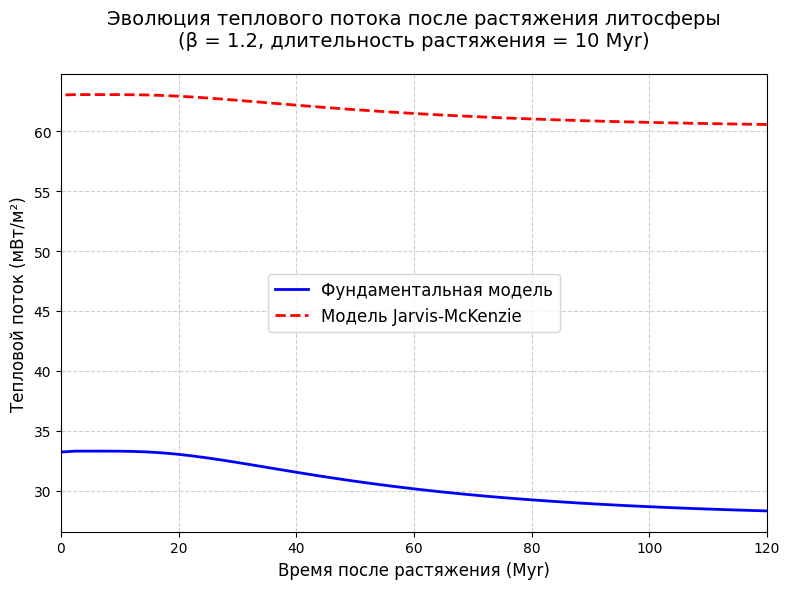

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
from typing import Tuple

# Константы для перевода единиц
MYR_TO_S = 1e6 * 3.154e7  # 1 миллион лет в секундах
CAL_TO_MW = 41868  # Коэффициент перевода кал/см²·с → мВт/м²

class ThermalModel:
    """
    Класс для расчета теплового потока при растяжении литосферы
    с использованием двух различных моделей.
    """
    
    def __init__(self):
        # Физические параметры по умолчанию
        self.a = 1.25e7  # Толщина литосферы [см]
        self.kappa = 0.01234  # Температуропроводность [см²/с]
        self.lam = 0.006214  # Теплопроводность [кал/(см·с·°C)]
        self.T1 = 1333  # Температура астеносферы [°C]
        
    def calculate_fundamental_model(self, beta: float, t_myr: np.ndarray, 
                                  t_stretch_myr: float, n_terms: int = 100) -> np.ndarray:
        """
        Фундаментальная модель теплового потока с рядом Фурье.
        
        Параметры:
            beta: фактор растяжения
            t_myr: массив времен в млн лет
            t_stretch_myr: время растяжения в млн лет
            n_terms: число членов ряда
            
        Возвращает:
            Тепловой поток в мВт/м²
        """
        tau_myr = self._calculate_tau_myr()
        
        if t_stretch_myr <= 30:
            n = np.arange(1, n_terms + 1)
            exponent = -np.outer(n**2, t_myr - t_stretch_myr) / tau_myr
            sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
            Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
            F_sum = np.sum(Cn, axis=0)
        else:
            n = 1
            exponent = -n**2 * (t_myr - t_stretch_myr) / tau_myr
            sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
            F_sum = (beta * sin_term) * np.exp(exponent)

        return (self.lam * self.T1 / self.a) * (1 + 2 * F_sum) * CAL_TO_MW

    def calculate_jarvis_mckenzie(self, beta: float, t_myr: np.ndarray, 
                                t_stretch_myr: float) -> np.ndarray:
        """
        Модель Jarvis-McKenzie (1980) теплового потока.
        
        Параметры:
            beta: фактор растяжения
            t_myr: массив времен в млн лет
            t_stretch_myr: время растяжения в млн лет
            
        Возвращает:
            Тепловой поток в мВт/м²
        """
        G_prime = self._calculate_g_prime(beta, t_stretch_myr)
        tau_myr = self._calculate_tau_myr()
        
        # Стационарный член
        steady_term = np.sqrt(2 * G_prime / np.pi) / scipy.special.erf(np.sqrt(G_prime / 2))
        
        # Переходный член (ряд Фурье)
        n = np.arange(1, 101)
        exponent = -np.outer(n**2, (t_myr - t_stretch_myr)) / tau_myr
        sin_term = np.sin(n * np.pi / beta)
        
        fourier_term = np.sum(
            (beta / (n[:, None] * np.pi)) * sin_term[:, None] * np.exp(exponent),
            axis=0
        )

        return (self.lam * self.T1 / self.a) * (steady_term + fourier_term) * CAL_TO_MW
    
    def _calculate_tau_myr(self) -> float:
        """Вычисляет характерное время диффузии в млн лет."""
        return (self.a**2) / (np.pi**2 * self.kappa) / MYR_TO_S
    
    def _calculate_g_prime(self, beta: float, t_stretch_myr: float) -> float:
        """Вычисляет безразмерный параметр растяжения G'."""
        G = np.log(beta) / (t_stretch_myr * MYR_TO_S)
        return (self.a**2 * G) / self.kappa

def plot_results(time: np.ndarray, fund_flow: np.ndarray, jm_flow: np.ndarray, 
                t_stretch: float, beta: float) -> plt.Figure:
    """
    Создает график сравнения моделей теплового потока.
    
    Параметры:
        time: массив времен в млн лет
        fund_flow: тепловой поток по фундаментальной модели
        jm_flow: тепловой поток по модели Jarvis-McKenzie
        t_stretch: время растяжения
        beta: фактор растяжения
        
    Возвращает:
        Объект matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Основной график
    ax.plot(time, fund_flow, 'b-', linewidth=2, label='Фундаментальная модель')
    ax.plot(time, jm_flow, 'r--', linewidth=2, label='Модель Jarvis-McKenzie')
    
    # Вертикальная линия окончания растяжения
    # ax.axvline(x=0, color='k', linestyle=':', label='Окончание растяжения')
    
    # Настройки графика
    ax.set_xlabel('Время после растяжения (Myr)', fontsize=12)
    ax.set_ylabel('Тепловой поток (мВт/м²)', fontsize=12)
    ax.set_title(
        f'Эволюция теплового потока после растяжения литосферы\n'
        f'(β = {beta}, длительность растяжения = {t_stretch} Myr)',
        fontsize=14, pad=20
    )
    
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.legend(fontsize=12, loc='center')
    ax.set_xlim(time.min(), time.max())
    
    plt.tight_layout()
    return fig

# Основной расчет
def main():
    # Инициализация модели
    model = ThermalModel()
    
    # Параметры расчета
    beta = 1.2
    t_stretch_myr = 10
    t_myr = np.linspace(10, 130, 50)  # Временная шкала
    
    # Расчет тепловых потоков
    fund_flow = model.calculate_fundamental_model(beta, t_myr, t_stretch_myr)
    jm_flow = model.calculate_jarvis_mckenzie(beta, t_myr, t_stretch_myr)
    
    # Построение графиков (переводим время в отсчет от окончания растяжения)
    time_after_stretch = t_myr - t_stretch_myr
    fig = plot_results(time_after_stretch[::-1], fund_flow[::-1]*1e3, jm_flow[::-1]*1e3, 
                      t_stretch_myr, beta)
    
    plt.show()

if __name__ == "__main__":
    main()

## Уравнения модели McKenzie-Jarvis 
### (McKenzie & Jarvis, 1980, "Sedimentary Basin Formation with Finite Extension Rates")

---

### 1. Основное дифференциальное уравнение теплопереноса (A-3)

Уравнение для собственных функций θ(z):

$$
\frac{d^2θ_n}{dz^2} + G'(1-z)\frac{dθ_n}{dz} + K_nθ_n = 0
$$

**Где:**
- $G' = \frac{a^2 \ln(\beta)}{κΔt}$ - безразмерный параметр растяжения
- $K_n$ - собственные значения задачи
- $a = 125$ км - толщина литосферы
- $κ = 1.234 \times 10^{-6}$ м²/с - коэффициент температуропроводности
- $Δt$ - длительность растяжения (10 млн лет в базовом случае)

---

### 2. Тепловой поток во время фазы растяжения (уравнение 16)

$$
F_{\text{stretch}}(t) = \frac{kT_1}{a} \left[ 
\sqrt{\frac{2G'}{\pi}} \frac{1}{\text{erf}(\sqrt{G'/2})} 
- \sum_{n=1}^N a_n \left.\frac{dθ_n}{dz}\right|_{z=1} e^{-K_n \frac{κt}{a^2}} 
\right]
$$

**Компоненты:**
1. Стационарный член: $\sqrt{\frac{2G'}{\pi}} \frac{1}{\text{erf}(\sqrt{G'/2})}$
2. Транзиентный член: $\sum_{n=1}^N a_n \frac{dθ_n}{dz}\big|_{z=1} e^{-K_n \frac{κt}{a^2}}$

---

### 3. Тепловой поток после растяжения (уравнение 22)

$$
F_{\text{post}}(t) = \frac{kT_1}{a} \left[ 
1 + \pi \sum_{n=1}^N n b_n (-1)^{n+1} e^{-n^2π^2 \frac{κ(t-Δt)}{a^2}} 
\right]
$$

**Особенности:**
- Первый член (1) соответствует установившемуся тепловому потоку
- Сумма описывает релаксацию термического возмущения

---

### 4. Коэффициенты разложения

#### Коэффициенты $a_n$:
$$
a_n = \frac{\int_0^1 \left[(1-z) + \frac{\text{erf}((z-1)\sqrt{G'/2})}{\text{erf}(\sqrt{G'/2})}\right] θ_n e^{(z-1)^2G'/2} dz}{\int_0^1 θ_n^2 e^{(z-1)^2G'/2} dz}
$$

#### Коэффициенты $b_n$:
$$
b_n = 2 \int_0^1 \left[ T(z,Δt) + (z-1) \right] \sin(nπz) dz
$$

---

### 5. Системы единиц и преобразования

**Базовые единицы:**
- Тепловой поток: $F_0 = \frac{kT_1}{a} \approx 27.8$ мВт/м² (для базовых параметров)

**Перевод единиц:**
$$
1 \text{ мВт/м}^2 = 0.0238846 \text{ μcal·cm}^{-2}\text{·sec}^{-1}
$$

**Безразмерная форма:**
$$
F_{\text{norm}} = \frac{F}{F_0} = \frac{F}{kT_1/a}
$$

---

### Параметры модели (базовый набор)

| Параметр | Значение | Единицы измерения |
|----------|----------|-------------------|
| $a$ | 125 | км |
| $κ$ | 1.234×10⁻⁶ | м²/с |
| $k$ | 2.6 | Вт/(м·K) |
| $T_1$ | 1330 | °C |
| $\beta$ | 1.2-4.0 | - |
| $G'$ | 5-100 | - |
| $Δt$ | 10 | млн лет |

---

### Примечания:
1. Все уравнения записаны в **размерной форме** с явным выделением физических параметров
2. Для численных расчетов рекомендуется использовать представленные параметры по умолчанию
3. Переход между системами единиц осуществляется через указанные коэффициенты

7.315414179088963


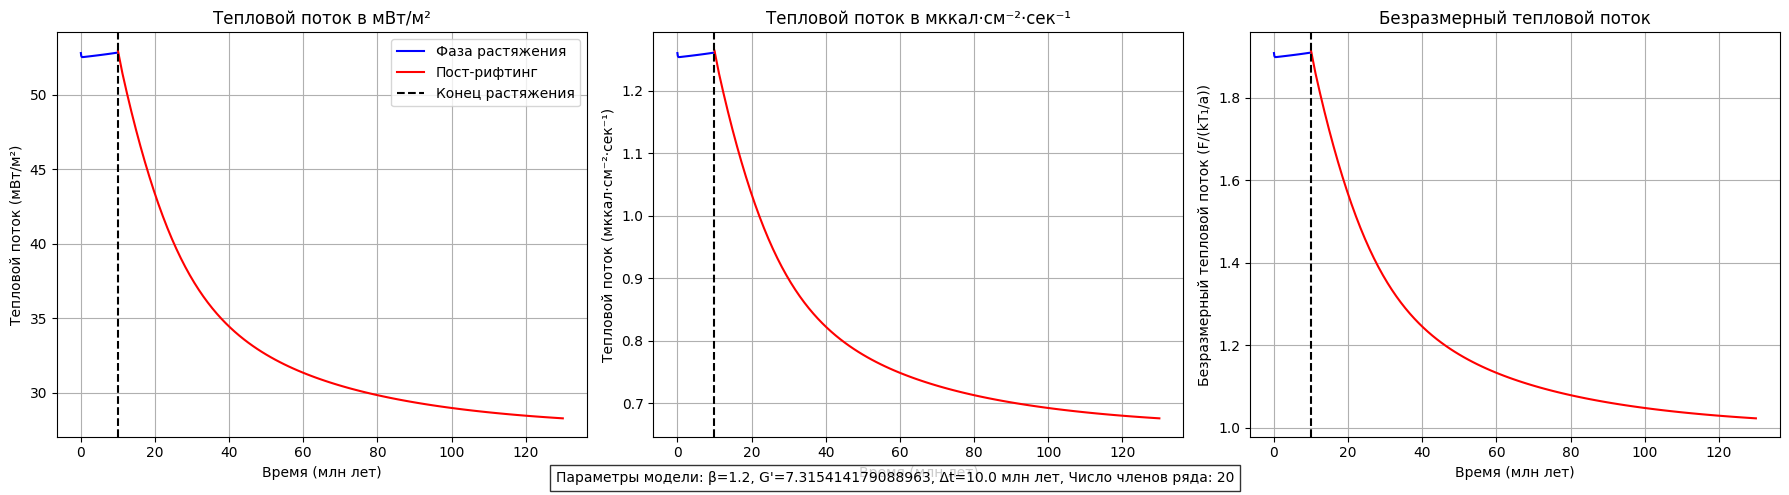

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import root_scalar

# Параметры модели (из статьи)
a = 125e3  # толщина литосферы (м)
kappa = 1.234 * 1e-6   # тепловая диффузия (m^2/s)
k = 2.6  # теплопроводность (W/m/K)
T1 = 1330  # температура астеносферы (°C)
beta = 1.2  # фактор растяжения (как на рис. 4)
G_prime = 10  # безразмерный параметр (как на рис. 4)

# Расчет длительности растяжения
# duration = (a**2 * np.log(beta)) / (kappa * G_prime)  # в секундах
# duration_myr = duration / (1e6 * 365.25 * 24 * 3600)  # в млн лет
# print(duration_myr)

# Расчет безразмерный параметр G_prime
duration_myr = 10 # в млн лет
duration = duration_myr * (1e6 * 365.25 * 24 * 3600)  # в млн лет
G_prime = (a**2 * np.log(beta)) / (kappa * duration)
print(G_prime)


class McKenzieThermalModel:
    def __init__(self, G_prime, n_eigenvalues=10, z_resolution=1000):
        self.G_prime = G_prime
        self.n_eigenvalues = n_eigenvalues
        self.z_points = np.linspace(0, 1, z_resolution)
        self.eigenvalues = []
        self.eigenfunctions = []
        self.dtheta_n = []
        self.coefficients = []
        
    def diff_eq(self, z, y, K):
        """Уравнение (A-3) из статьи"""
        theta, dtheta = y
        return [dtheta, -self.G_prime*(1-z)*dtheta - K*theta]
    
    def propagator_matrix(self, K):
        """Решение уравнения для матрицы propagator"""
        sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                        (0, 1), [0, 1],  # Начальные условия: θ(0)=0, dθ/dz(0)=1
                        method='RK45', dense_output=True)
        return sol.sol(1)[0]  # Возвращаем θ(1)
    
    def find_eigenvalues(self):
        """Нахождение собственных значений K_n"""
        # Начальные приближения (из асимптотики)
        K_guesses = [(n+1)**2 * np.pi**2 + self.G_prime/2 for n in range(self.n_eigenvalues)]
        
        for guess in K_guesses:
            try:
                res = root_scalar(self.propagator_matrix, 
                                 x0=guess, 
                                 method='newton',
                                 fprime=lambda K: (self.propagator_matrix(K+1e-6) - self.propagator_matrix(K-1e-6))/2e-6)
                if res.converged and res.root > 0:
                    self.eigenvalues.append(res.root)
            except Exception as e:
                print(f"Error for guess {guess}: {e}")
        
        self.eigenvalues = sorted(list(set(self.eigenvalues)))[:self.n_eigenvalues]
    
    def compute_eigenfunctions(self):
        """Вычисление собственных функций θ_n(z)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1],  # θ(0)=0, dθ/dz(0)=1
                           t_eval=self.z_points, 
                           method='RK45')
            self.eigenfunctions.append(sol.y[0])
    
    def compute_derivatives(self):
        """Вычисление производных dθ_n/dz на поверхности (z=1)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1], 
                           t_eval=[1], 
                           method='RK45')
            self.dtheta_n.append(sol.y[1][0])  # dθ/dz at z=1
    
    def _compute_normalization(self, theta_n):
        """Вычисление нормировочного интеграла для θ_n"""
        integrand = np.exp((self.z_points - 1)**2 * self.G_prime/2) * theta_n**2
        return trapezoid(integrand, self.z_points)
    
    def _compute_coefficient(self, initial_condition, theta_n, norm):
        """Вычисление коэффициента a_n"""
        integrand = initial_condition(self.z_points) * theta_n * np.exp((self.z_points - 1)**2 * self.G_prime/2)
        return trapezoid(integrand, self.z_points) / norm
    
    def compute_coefficients(self):
        """Вычисление всех коэффициентов a_n"""
        # Начальное условие (правая часть уравнения A-17)
        def initial_condition(z):
            return (1 - z) + erf((z - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        for theta_n in self.eigenfunctions:
            norm = self._compute_normalization(theta_n)
            an = self._compute_coefficient(initial_condition, theta_n, norm)
            self.coefficients.append(an)
    
    def heat_flow_during_stretching(self, t):
        """Точный расчет теплового потока во время растяжения (уравнение 16)"""
        t_dimless = kappa * t / a**2  # Безразмерное время
        
        # Стационарный член
        steady_term = np.sqrt(2 * self.G_prime / np.pi) / erf(np.sqrt(self.G_prime / 2))
        
        # Транзиентный член
        transient_term = 0
        for an, Kn, dtheta in zip(self.coefficients, self.eigenvalues, self.dtheta_n):
            transient_term += an * np.exp(-Kn * t_dimless) * dtheta
        
        return (k * T1 / a) * (steady_term - transient_term)

    def compute_post_rift_coefficients(self):
        """Вычисление коэффициентов b_n для пост-рифтинга"""
        # Температура в момент окончания растяжения (t = Δt)
        z_points = self.z_points
        T_final = np.zeros_like(z_points)
        
        # Стационарный член
        T_final += -erf((z_points - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        # Транзиентный член (сумма по собственным функциям)
        t_final = (a**2 * np.log(beta)) / (kappa * self.G_prime)  # t = Δt
        t_dimless = kappa * t_final / a**2
        
        for an, Kn, theta_n in zip(self.coefficients, self.eigenvalues, self.eigenfunctions):
            T_final += an * np.exp(-Kn * t_dimless) * theta_n
        
        # Вычисление b_n (уравнение 19)
        b_coeffs = []
        for n in range(1, self.n_eigenvalues + 1):
            integrand = (T_final + (z_points - 1)) * np.sin(n * np.pi * z_points)
            bn = 2 * trapezoid(integrand, z_points)
            b_coeffs.append(bn)
        
        return b_coeffs

    def heat_flow_post_rift(self, t_post, b_coeffs):
        """Точный расчёт теплового потока после растяжения"""
        t_dimless = kappa * t_post / a**2
        steady_term = 1  # Исправлено: стационарный член должен быть 1 (см. уравнение 22)
        transient_term = 0
        
        for n, bn in enumerate(b_coeffs, start=1):
            transient_term += n * bn * (-1)**(n+1) * np.exp(-n**2 * np.pi**2 * t_dimless)
        
        return (k * T1 / a) * (steady_term + np.pi * transient_term)


# Инициализация модели
model = McKenzieThermalModel(G_prime=G_prime, n_eigenvalues=20)

# Шаг 1: Находим собственные значения K_n
model.find_eigenvalues()
# print(f"Найдено {len(model.eigenvalues)} собственных значений")
# print("Первые 5 K_n:", model.eigenvalues[:5])

# Шаг 2: Вычисляем собственные функции θ_n(z) и их производные
model.compute_eigenfunctions()
model.compute_derivatives()

# Шаг 3: Вычисляем коэффициенты a_n
model.compute_coefficients()
# print("Первые 5 a_n:", model.coefficients[:5])

# Вычисляем коэффициенты b_n для пост-рифтинга
b_coeffs = model.compute_post_rift_coefficients()

# Расчет теплового потока
time_stretch = np.linspace(0, duration, 100)  # Фаза растяжения
time_post = np.linspace(0, 120e6*365.25*24*3600, 100)  # Пост-рифтинг (100 млн лет)

F_stretch = [model.heat_flow_during_stretching(t) for t in time_stretch]
F_post = [model.heat_flow_post_rift(t, b_coeffs) for t in time_post]

# Конвертируем в разные единицы
F_stretch_mW = np.array(F_stretch) * 1e3  # В мВт/м²
F_post_mW = np.array(F_post) * 1e3        # В мВт/м²

# Конвертация в мккал·см⁻²·сек⁻¹
mW_to_mkcal = 0.0238846  # Коэффициент перевода
F_stretch_mkcal = F_stretch_mW * mW_to_mkcal
F_post_mkcal = F_post_mW * mW_to_mkcal

# Конвертируем время в млн лет
t_stretch_myr = time_stretch / (1e6 * 365.25 * 24 * 3600)
t_post_myr = time_post / (1e6 * 365.25 * 24 * 3600) + duration_myr

# Создаем фигуру с тремя графиками
plt.figure(figsize=(18, 5))

# 1. Тепловой поток в мВт/м²
plt.subplot(1, 3, 1)
plt.plot(t_stretch_myr, F_stretch_mW, 'b-', label='Фаза растяжения')
plt.plot(t_post_myr, F_post_mW, 'r-', label='Пост-рифтинг')
plt.axvline(x=duration_myr, color='k', linestyle='--', label='Конец растяжения')
plt.xlabel('Время (млн лет)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title('Тепловой поток в мВт/м²')
plt.legend()
plt.grid(True)

# 2. Тепловой поток в мккал·см⁻²·сек⁻¹
plt.subplot(1, 3, 2)
plt.plot(t_stretch_myr, F_stretch_mkcal, 'b-', label='Фаза растяжения')
plt.plot(t_post_myr, F_post_mkcal, 'r-', label='Пост-рифтинг')
plt.axvline(x=duration_myr, color='k', linestyle='--')
plt.xlabel('Время (млн лет)')
plt.ylabel('Тепловой поток (мккал·см⁻²·сек⁻¹)')
plt.title('Тепловой поток в мккал·см⁻²·сек⁻¹')
plt.grid(True)

# 3. Безразмерный тепловой поток (F/(kT₁/a))
plt.subplot(1, 3, 3)
F_norm_stretch = np.array(F_stretch) / (k * T1 / a)
F_norm_post = np.array(F_post) / (k * T1 / a)
plt.plot(t_stretch_myr, F_norm_stretch, 'b-', label='Фаза растяжения')
plt.plot(t_post_myr, F_norm_post, 'r-', label='Пост-рифтинг')
plt.axvline(x=duration_myr, color='k', linestyle='--')
plt.xlabel('Время (млн лет)')
plt.ylabel('Безразмерный тепловой поток (F/(kT₁/a))')
plt.title('Безразмерный тепловой поток')
plt.grid(True)

# Общая информация о параметрах модели
plt.figtext(0.5, 0.02, 
         f'Параметры модели: β={beta}, G\'={G_prime}, Δt={duration_myr:.1f} млн лет, Число членов ряда: {model.n_eigenvalues}',
         ha='center', va='bottom', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import root_scalar

# Параметры модели (все в размерных единицах)
a = 125e3  # толщина литосферы [м]
kappa = 8.04e-7  # температуропроводность [м²/с]
k = 3.138  # теплопроводность [Вт/(м·K)]
T1 = 1330  # температура астеносферы [°C]
beta = 4  # фактор растяжения
G_prime_values = [5, 10, 20, 50, 100]  # значения параметра G'

# Коэффициенты перевода единиц
mW_per_m2_to_mkcal = 0.0238846  # 1 мВт/м² = 0.0238846 μcal·cm⁻²·sec⁻¹

class McKenzieThermalModel:
    def __init__(self, G_prime, n_eigenvalues=30, z_resolution=1000):
        self.G_prime = G_prime
        self.n_eigenvalues = n_eigenvalues
        self.z_points = np.linspace(0, 1, z_resolution)
        self.eigenvalues = []
        self.eigenfunctions = []
        self.dtheta_n = []
        self.coefficients = []
        
    def diff_eq(self, z, y, K):
        theta, dtheta = y
        return [dtheta, -self.G_prime*(1-z)*dtheta - K*theta]
    
    def propagator_matrix(self, K):
        sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                       (0, 1), [0, 1], method='RK45', dense_output=True)
        return sol.sol(1)[0]
    
    def find_eigenvalues(self):
        K_guesses = [(n+1)**2 * np.pi**2 + self.G_prime/2 for n in range(self.n_eigenvalues)]
        for guess in K_guesses:
            try:
                res = root_scalar(self.propagator_matrix, x0=guess, method='newton',
                                fprime=lambda K: (self.propagator_matrix(K+1e-6) - self.propagator_matrix(K-1e-6))/2e-6)
                if res.converged and res.root > 0:
                    self.eigenvalues.append(res.root)
            except:
                continue
        self.eigenvalues = sorted(list(set(self.eigenvalues)))[:self.n_eigenvalues]
    
    def compute_eigenfunctions(self):
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                          (0, 1), [0, 1], t_eval=self.z_points, method='RK45')
            self.eigenfunctions.append(sol.y[0])
    
    def compute_derivatives(self):
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                          (0, 1), [0, 1], t_eval=[1], method='RK45')
            self.dtheta_n.append(sol.y[1][0])
    
    def _compute_normalization(self, theta_n):
        integrand = np.exp((self.z_points - 1)**2 * self.G_prime/2) * theta_n**2
        return trapezoid(integrand, self.z_points)
    
    def _compute_coefficient(self, initial_condition, theta_n, norm):
        integrand = initial_condition(self.z_points) * theta_n * np.exp((self.z_points - 1)**2 * self.G_prime/2)
        return trapezoid(integrand, self.z_points) / norm
    
    def compute_coefficients(self):
        def initial_condition(z):
            return (1 - z) + erf((z - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        for theta_n in self.eigenfunctions:
            norm = self._compute_normalization(theta_n)
            an = self._compute_coefficient(initial_condition, theta_n, norm)
            self.coefficients.append(an)
    
    def heat_flow_during_stretching(self, t):
        """Тепловой поток во время растяжения в мВт/м²"""
        t_scale = kappa * t / a**2
        
        # Основные члены в размерной форме
        steady_flow = (k * T1 / a) * np.sqrt(2 * self.G_prime / np.pi) / erf(np.sqrt(self.G_prime / 2))
        
        transient_flow = 0
        for an, Kn, dtheta in zip(self.coefficients, self.eigenvalues, self.dtheta_n):
            transient_flow += (k * T1 / a) * an * dtheta * np.exp(-Kn * t_scale)
        
        return (steady_flow - transient_flow) * 1e3  # Переводим в мВт/м²

    def compute_post_rift_coefficients(self):
        """Коэффициенты для пост-рифтинга в размерной форме"""
        z_points = self.z_points
        T_final = np.zeros_like(z_points)
        
        # Стационарный член в размерных единицах
        T_final += -(k * T1 / a) * erf((z_points - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        t_final = (a**2 * np.log(beta)) / (kappa * self.G_prime)
        t_scale = kappa * t_final / a**2
        
        # Транзиентные члены в размерных единицах
        for an, Kn, theta_n in zip(self.coefficients, self.eigenvalues, self.eigenfunctions):
            T_final += (k * T1 / a) * an * np.exp(-Kn * t_scale) * theta_n
        
        b_coeffs = []
        for n in range(1, self.n_eigenvalues + 1):
            integrand = (T_final + (k * T1 / a) * (z_points - 1)) * np.sin(n * np.pi * z_points)
            bn = 2 * trapezoid(integrand, z_points) / (k * T1 / a)  # Нормировка
            b_coeffs.append(bn)
        
        return b_coeffs

    def heat_flow_post_rift(self, t_post, b_coeffs):
        """Тепловой поток после растяжения в мВт/м²"""
        t_scale = kappa * t_post / a**2
        
        # Стационарный поток в размерных единицах
        steady_flow = k * T1 / a
        
        transient_flow = 0
        for n, bn in enumerate(b_coeffs, start=1):
            transient_flow += (k * T1 / a) * np.pi * n * bn * (-1)**(n+1) * np.exp(-n**2 * np.pi**2 * t_scale)
        
        return (steady_flow + transient_flow) * 1e3  # Переводим в мВт/м²

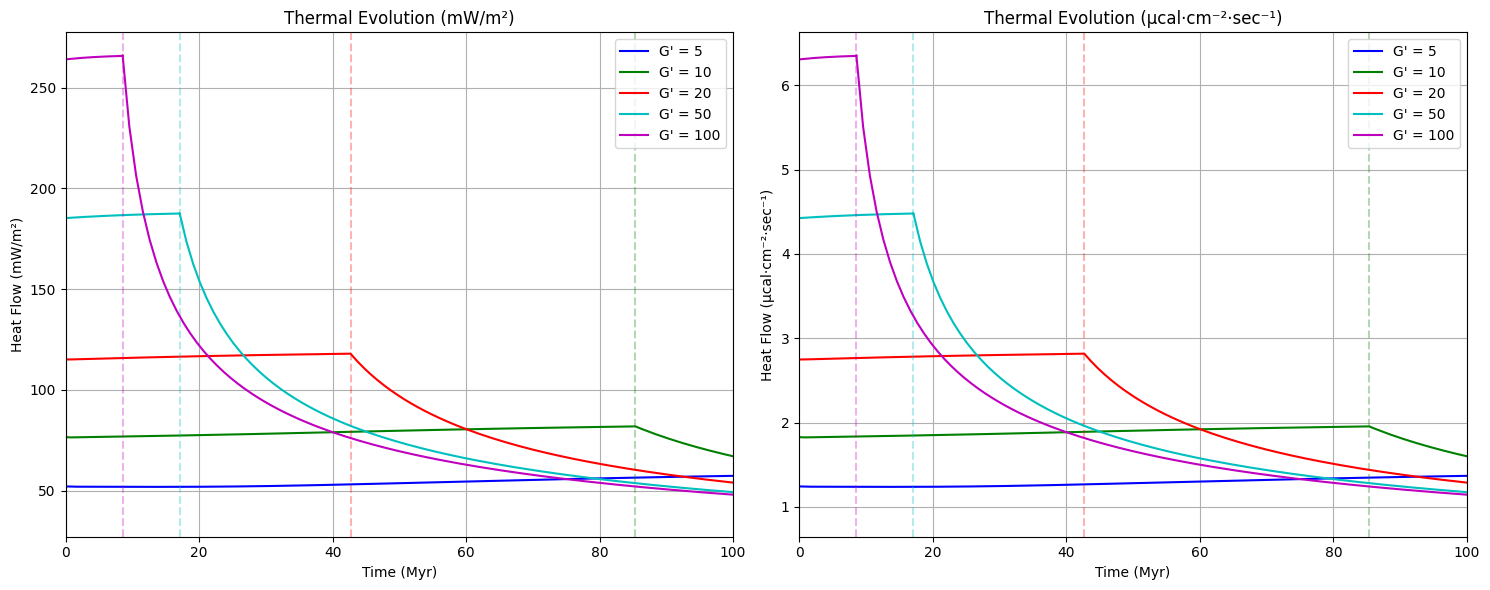

In [41]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for G_prime, color in zip(G_prime_values, ['b', 'g', 'r', 'c', 'm']):
    duration = (a**2 * np.log(beta)) / (kappa * G_prime)
    duration_myr = duration / (1e6 * 365.25 * 24 * 3600)
    
    model = McKenzieThermalModel(G_prime)
    model.find_eigenvalues()
    model.compute_eigenfunctions()
    model.compute_derivatives()
    model.compute_coefficients()
    b_coeffs = model.compute_post_rift_coefficients()
    
    # Фаза растяжения
    time_stretch = np.linspace(0, duration, 100)
    F_stretch = [model.heat_flow_during_stretching(t) for t in time_stretch]
    t_stretch_myr = time_stretch / (1e6 * 365.25 * 24 * 3600)
    
    # Пост-рифтинг
    time_post = np.linspace(0, 100e6*365.25*24*3600, 100)
    F_post = [model.heat_flow_post_rift(t, b_coeffs) for t in time_post]
    t_post_myr = time_post / (1e6 * 365.25 * 24 * 3600) + duration_myr
    
    plt.plot(np.concatenate([t_stretch_myr, t_post_myr]), 
             np.concatenate([F_stretch, F_post]), 
             color, label=f"G' = {G_prime}")
    plt.axvline(duration_myr, color=color, ls='--', alpha=0.3)

plt.xlabel('Time (Myr)')
plt.ylabel('Heat Flow (mW/m²)')
plt.title('Thermal Evolution (mW/m²)')
plt.legend()
plt.grid(True)
plt.xlim(0, 100)


plt.subplot(1, 2, 2)
for G_prime, color in zip(G_prime_values, ['b', 'g', 'r', 'c', 'm']):
    duration = (a**2 * np.log(beta)) / (kappa * G_prime)
    duration_myr = duration / (1e6 * 365.25 * 24 * 3600)
    
    model = McKenzieThermalModel(G_prime)
    model.find_eigenvalues()
    model.compute_eigenfunctions()
    model.compute_derivatives()
    model.compute_coefficients()
    b_coeffs = model.compute_post_rift_coefficients()
    
    # Фаза растяжения
    time_stretch = np.linspace(0, duration, 100)
    F_stretch = [model.heat_flow_during_stretching(t) * mW_per_m2_to_mkcal for t in time_stretch]
    t_stretch_myr = time_stretch / (1e6 * 365.25 * 24 * 3600)
    
    # Пост-рифтинг
    time_post = np.linspace(0, 100e6*365.25*24*3600, 100)
    F_post = [model.heat_flow_post_rift(t, b_coeffs) * mW_per_m2_to_mkcal for t in time_post]
    t_post_myr = time_post / (1e6 * 365.25 * 24 * 3600) + duration_myr
    
    plt.plot(np.concatenate([t_stretch_myr, t_post_myr]), 
             np.concatenate([F_stretch, F_post]), 
             color, label=f"G' = {G_prime}")
    plt.axvline(duration_myr, color=color, ls='--', alpha=0.3)

plt.xlabel('Time (Myr)')
plt.ylabel('Heat Flow (μcal·cm⁻²·sec⁻¹)')
plt.title('Thermal Evolution (μcal·cm⁻²·sec⁻¹)')
plt.legend()
plt.grid(True)
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

### Адиабата мантии

Температурный профиль в коре (линейный градиент):
$$
T(z) = T_0 + G \cdot z, \quad 0 \leq z \leq z_c
$$

Температурный профиль в мантии (адиабатический рост):
$$
T(z) = T_c \cdot \exp\left( \frac{\alpha g}{C_p} (z - z_c) \right), \quad z_c < z \leq z_c + z_m
$$

где

\begin{align*}
& T_0 \quad \text{— температура на поверхности}, \\
& G \quad \text{— линейный геотермический градиент в коре (°C/м)}, \\
& z_c = 30\,\text{км} \quad \text{— толщина коры}, \\
& T_c = T_0 + G \cdot z_c \quad \text{— температура на границе кора-мантий}, \\
& \alpha \quad \text{— коэффициент теплового расширения (1/К)}, \\
& g \quad \text{— ускорение свободного падения (м/с}^2\text{)}, \\
& C_p = 1000\, \text{Дж/(кг·К)} \quad \text{— изобарная теплоёмкость}, \\
& z_m = 95\,\text{км} \quad \text{— толщина мантии}.
\end{align*}


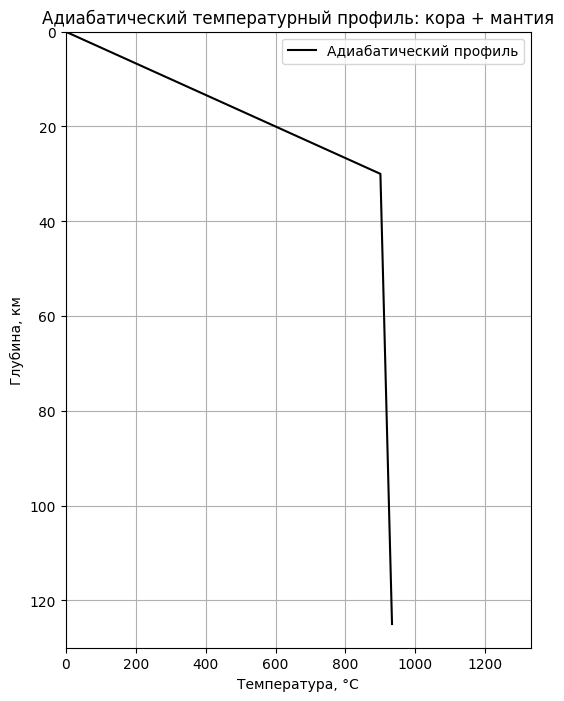

In [42]:
def adiabat_temperature_profile(
    T_surface=0,            # Температура на поверхности, °C
    thickness_crust=30e3,   # Толщина коры, м
    grad_crust=30/1e3,      # Градиент температуры в коре, °C/м
    thickness_mantle=95e3,  # Толщина мантии, м
    alpha=3e-5,             # Коэффициент теплового расширения, 1/К
    g=9.8,                  # Ускорение свободного падения, м/с²
    Cp=1000                 # Изобарная теплоёмкость, Дж/(кг·К)
):
    # Расчёт температуры в коре (линейный градиент)
    z_crust = np.linspace(0, thickness_crust, 300)
    T_crust = T_surface + grad_crust * z_crust

    # Температура на границе кора-мантия
    T_base_crust = T_crust[-1]

    # Расчёт температуры в мантии (адиабата)
    z_mantle = np.linspace(thickness_crust, thickness_crust + thickness_mantle, 500)
    T0_K = T_base_crust + 273.15  # перевод в Кельвины

    exponent = (alpha * g / Cp) * (z_mantle - thickness_crust)
    T_mantle_K = T0_K * np.exp(exponent)
    T_mantle = T_mantle_K - 273.15  # обратно в °C

    z_total = np.concatenate((z_crust, z_mantle)) / 1e3  # глубина в км
    T_total = np.concatenate((T_crust, T_mantle))

    plt.figure(figsize=(6,8))
    plt.plot(T_total, z_total, label='Адиабатический профиль', color='black')
    plt.gca().invert_yaxis()  # глубина вниз
    plt.xlim(0, 1330)
    plt.ylim(130, 0)
    plt.xlabel('Температура, °C')
    plt.ylabel('Глубина, км')
    plt.title('Адиабатический температурный профиль: кора + мантия')
    plt.grid(True)
    plt.legend()
    plt.show()

    # return z_total, T_total

# Вызов функции с параметрами
adiabat_temperature_profile()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import root_scalar
import time

# Параметры модели (из статьи Hellinger and Sclater, 1983)
a = 125e3  # толщина литосферы (м)
t_c = 30e3  # толщина коры (м)
kappa = 1.234 * 1e-6   # тепловая диффузия (m^2/s)
k = 2.6  # теплопроводность (W/m/K)
T_m = 1330  # температура астеносферы (°C)
alpha = 3.28e-5  # коэффициент теплового расширения (1/°C)
rho_m = 3.33  # плотность мантии при 0°C (g/cm^3)
rho_c = 2.8  # плотность коры при 0°C (g/cm^3)
rho_w = 1.03  # плотность воды (g/cm^3)

# Два коэффициента растяжения (как в статье)
beta_c = 1.2  # для коры (из анализа Pattani Trough)
beta_sc = 1.2  # для субкоровой литосферы

# Расчет эквивалентного растяжения для всей литосферы (уравнение 1 из статьи)
beta_L = 1 / ( (t_c/a)/beta_c + (1 - t_c/a)/beta_sc )

# Параметры для модели растяжения
# G_prime = 10  # безразмерный параметр
duration_myr = 200  # продолжительность растяжения (млн лет) для Pattani Trough
duration = duration_myr * (1e6 * 365.25 * 24 * 3600)  # в млн лет

# FIX: Changed 'beta' to 'beta_L' in the G_prime calculation
G_prime = (a**2 * np.log(beta_L)) / (kappa * 10)

# Benchmarking setup
benchmark_times = {}
def start_benchmark(name):
    return time.time()

def end_benchmark(name, start_time):
    elapsed = time.time() - start_time
    benchmark_times[name] = elapsed
    print(f"BENCHMARK - {name}: {elapsed:.4f} seconds")
    return elapsed

# Start overall timing
overall_start = start_benchmark("Overall execution")

class TwoLayerMcKenzieModel:
    def __init__(self, beta_c, beta_sc, G_prime=10, n_eigenvalues=10):
        self.beta_c = beta_c
        self.beta_sc = beta_sc
        self.G_prime = G_prime
        self.n_eigenvalues = n_eigenvalues
        self.z_points = np.linspace(0, 1, 1000)
        
        # Расчет параметров gamma (уравнения после (1) в статье)
        self.gamma_c = 1 - 1/beta_c
        self.gamma_sc = 1 - 1/beta_sc
        self.gamma_L = (t_c/a)*self.gamma_c + (1 - t_c/a)*self.gamma_sc
        
        # Инициализация массивов
        self.eigenvalues = []
        self.eigenfunctions = []
        self.dtheta_n = []
        self.coefficients = []
    
    def diff_eq(self, z, y, K):
        """Уравнение (A-3) из McKenzie (1978)"""
        theta, dtheta = y
        return [dtheta, -self.G_prime*(1-z)*dtheta - K*theta]
    
    def propagator_matrix(self, K):
        """Решение уравнения для матрицы propagator"""
        sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                        (0, 1), [0, 1],  # Начальные условия: θ(0)=0, dθ/dz(0)=1
                        method='RK45', dense_output=True)
        return sol.sol(1)[0]  # Возвращаем θ(1)
    
    def find_eigenvalues(self):
        """Нахождение собственных значений K_n"""
        K_guesses = [(n+1)**2 * np.pi**2 + self.G_prime/2 for n in range(self.n_eigenvalues)]
        
        for guess in K_guesses:
            try:
                res = root_scalar(self.propagator_matrix, 
                                 x0=guess, 
                                 method='newton',
                                 fprime=lambda K: (self.propagator_matrix(K+1e-6) - self.propagator_matrix(K-1e-6))/2e-6)
                if res.converged and res.root > 0:
                    self.eigenvalues.append(res.root)
            except:
                continue
        
        self.eigenvalues = sorted(list(set(self.eigenvalues))[:self.n_eigenvalues])
    
    def compute_eigenfunctions(self):
        """Вычисление собственных функций θ_n(z)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1],
                           t_eval=self.z_points, 
                           method='RK45')
            self.eigenfunctions.append(sol.y[0])
    
    def compute_derivatives(self):
        """Вычисление производных dθ_n/dz на поверхности (z=1)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1], 
                           t_eval=[1], 
                           method='RK45')
            self.dtheta_n.append(sol.y[1][0])
    
    def _compute_normalization(self, theta_n):
        """Вычисление нормировочного интеграла для θ_n"""
        integrand = np.exp((self.z_points - 1)**2 * self.G_prime/2) * theta_n**2
        return trapezoid(integrand, self.z_points)
    
    def _compute_coefficient(self, initial_condition, theta_n, norm):
        """Вычисление коэффициента a_n"""
        integrand = initial_condition(self.z_points) * theta_n * np.exp((self.z_points - 1)**2 * self.G_prime/2)
        return trapezoid(integrand, self.z_points) / norm
    
    def compute_coefficients(self):
        """Вычисление всех коэффициентов a_n"""
        def initial_condition(z):
            return (1 - z) + erf((z - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        for theta_n in self.eigenfunctions:
            norm = self._compute_normalization(theta_n)
            an = self._compute_coefficient(initial_condition, theta_n, norm)
            self.coefficients.append(an)
    
    def initial_subsidence(self, water_loaded=True):
        """Начальное погружение (уравнение 3 или 4 из статьи)"""
        if water_loaded:
            return 7.27*self.gamma_c - 3.00*self.gamma_L  # в км (уравнение 3)
        else:
            return 4.99*self.gamma_c - 2.06*self.gamma_L  # в км (уравнение 4)
    
    def final_subsidence(self):
        """Финальное погружение (уравнение 6 из статьи)"""
        return 8.44 * self.gamma_c  # в км
    
    def heat_flow_during_stretching(self, t):
        """Тепловой поток во время растяжения с учетом beta_sc"""
        t_dimless = kappa * t / (a**2 * self.beta_sc**2)  # ключевое изменение!
        steady_term = np.sqrt(2 * self.G_prime / np.pi) / erf(np.sqrt(self.G_prime / 2))
        transient_term = 0
        
        for an, Kn, dtheta in zip(self.coefficients, self.eigenvalues, self.dtheta_n):
            transient_term += an * np.exp(-Kn * t_dimless) * dtheta
        
        return (k * T_m / a) * (steady_term - transient_term)
    
    def compute_post_rift_coefficients(self):
        """Коэффициенты для пост-рифтинговой фазы"""
        z_points = self.z_points
        T_final = np.zeros_like(z_points)
        
        # Стационарный член
        T_final += -erf((z_points - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        # Транзиентный член
        t_final = (a**2 * np.log(beta_L)) / (kappa * self.G_prime)
        t_dimless = kappa * t_final / a**2
        
        for an, Kn, theta_n in zip(self.coefficients, self.eigenvalues, self.eigenfunctions):
            T_final += an * np.exp(-Kn * t_dimless) * theta_n
        
        # Коэффициенты b_n
        b_coeffs = []
        for n in range(1, self.n_eigenvalues + 1):
            integrand = (T_final + (z_points - 1)) * np.sin(n * np.pi * z_points)
            bn = 2 * trapezoid(integrand, z_points)
            b_coeffs.append(bn)
        
        return b_coeffs
    
    def heat_flow_post_rift(self, t_post, b_coeffs):
        """Тепловой поток после растяжения с учетом beta_sc"""
        t_dimless = kappa * t_post / (a**2 * self.beta_sc**2)  # ключевое изменение!
        steady_term = 1
        transient_term = 0
        
        for n, bn in enumerate(b_coeffs, start=1):
            transient_term += n * bn * (-1)**(n+1) * np.exp(-n**2 * np.pi**2 * t_dimless)
        
        return (k * T_m / a) * (steady_term + np.pi * transient_term)
    
    def thermal_subsidence(self, t_post):
        """Термическое погружение после растяжения"""
        tau = a**2 / (np.pi**2 * kappa)  # характерное время
        subsidence = 0
        for n in range(1, 20):
            term = (1 - np.exp(-n**2 * t_post / tau)) / n**2
            subsidence += term
        return (4 * a * alpha * rho_m * T_m / (np.pi**2 * (rho_m - rho_w))) * subsidence

# Инициализация модели с двумя коэффициентами растяжения
print("\nStarting model initialization and calculations...")
model_init_start = start_benchmark("Model initialization")
model = TwoLayerMcKenzieModel(beta_c=beta_c, beta_sc=beta_sc, G_prime=G_prime)

eigenvalues_start = start_benchmark("Finding eigenvalues")
model.find_eigenvalues()
end_benchmark("Finding eigenvalues", eigenvalues_start)

eigenfunctions_start = start_benchmark("Computing eigenfunctions")
model.compute_eigenfunctions()
end_benchmark("Computing eigenfunctions", eigenfunctions_start)

derivatives_start = start_benchmark("Computing derivatives")
model.compute_derivatives()
end_benchmark("Computing derivatives", derivatives_start)

coefficients_start = start_benchmark("Computing coefficients")
model.compute_coefficients()
end_benchmark("Computing coefficients", coefficients_start)

post_rift_start = start_benchmark("Computing post-rift coefficients")
b_coeffs = model.compute_post_rift_coefficients()
end_benchmark("Computing post-rift coefficients", post_rift_start)

end_benchmark("Model initialization", model_init_start)

# Расчет теплового потока
print("\nCalculating heat flow...")
heat_flow_start = start_benchmark("Heat flow calculations")

time_stretch = np.linspace(0, duration, 100)  # фаза растяжения
time_post = np.linspace(0, 120e6*365.25*24*3600, 100)  # пост-рифтинг (100 млн лет)

stretch_start = start_benchmark("Stretching phase heat flow")
F_stretch = [model.heat_flow_during_stretching(t) for t in time_stretch]
end_benchmark("Stretching phase heat flow", stretch_start)

post_start = start_benchmark("Post-rift heat flow")
F_post = [model.heat_flow_post_rift(t, b_coeffs) for t in time_post]
end_benchmark("Post-rift heat flow", post_start)

end_benchmark("Heat flow calculations", heat_flow_start)

# Конвертация единиц
F_stretch_mW = np.array(F_stretch) * 1e3  # мВт/м²
F_post_mW = np.array(F_post) * 1e3        # мВт/м²
mW_to_mkcal = 0.0238846  # коэффициент перевода
F_stretch_mkcal = F_stretch_mW * mW_to_mkcal
F_post_mkcal = F_post_mW * mW_to_mkcal

# Временные оси
t_stretch_myr = time_stretch / (1e6 * 365.25 * 24 * 3600)
t_post_myr = time_post / (1e6 * 365.25 * 24 * 3600) + duration_myr

# Расчет погружения
S_i = model.initial_subsidence(water_loaded=True)
S_inf = model.final_subsidence()
time_subsidence = np.linspace(0, 100, 100)  # млн лет после растяжения
S_t = S_i + (S_inf - S_i) * (1 - np.exp(-time_subsidence/62.5))  # упрощенная модель

# Визуализация результатов
plt.figure(figsize=(18, 5))

# 1. Тепловой поток
plt.subplot(1, 3, 1)
plt.plot(t_stretch_myr, F_stretch_mW, 'b-', label='Фаза растяжения')
plt.plot(t_post_myr, F_post_mW, 'r-', label='Пост-рифтинг')
plt.axvline(duration_myr, color='k', linestyle='--')
plt.xlabel('Время (млн лет)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title('Тепловой поток')
plt.grid()
plt.legend()

# 2. Погружение
plt.subplot(1, 3, 2)
plt.plot(time_subsidence, S_t, 'g-')
plt.xlabel('Время после растяжения (млн лет)')
plt.ylabel('Погружение (км)')
plt.title(f'Начальное погружение: {S_i:.2f} км, Финальное: {S_inf:.2f} км')
plt.grid()

# 3. Параметры модели
plt.subplot(1, 3, 3)
plt.axis('off')
plt.text(0.1, 0.9, f'Параметры модели (Pattani Trough):', fontsize=12)
plt.text(0.1, 0.8, f'β_c (кора) = {beta_c:.2f}', fontsize=12)
plt.text(0.1, 0.7, f'β_sc (мантия) = {beta_sc:.2f}', fontsize=12)
plt.text(0.1, 0.6, f'β_L (литосфера) = {beta_L:.2f}', fontsize=12)
plt.text(0.1, 0.5, f'γ_c = {model.gamma_c:.2f}', fontsize=12)
plt.text(0.1, 0.4, f'γ_sc = {model.gamma_sc:.2f}', fontsize=12)
plt.text(0.1, 0.3, f'γ_L = {model.gamma_L:.2f}', fontsize=12)
plt.text(0.1, 0.2, f'Длительность растяжения = {duration_myr} млн лет', fontsize=12)
plt.text(0.1, 0.1, f'G\' = {G_prime}', fontsize=12)

plt.tight_layout()

# End overall timing and print summary
end_benchmark("Overall execution", overall_start)

# Print benchmark summary
print("\nBenchmark Summary:")
print("-" * 40)
sorted_benchmarks = sorted(benchmark_times.items(), key=lambda x: x[1], reverse=True)
for name, time_taken in sorted_benchmarks:
    print(f"{name:30s}: {time_taken:.4f} seconds")
print("-" * 40)

plt.show()



Starting model initialization and calculations...


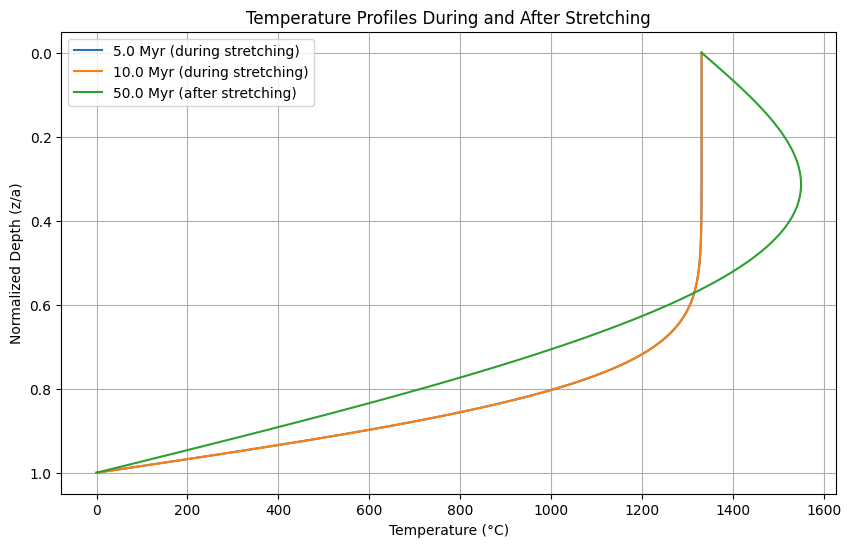

In [ ]:
import numpy as np
from scipy.special import erf

def calculate_temperature(z, a, T1, beta, kappa, t, Delta_t):
    """
    Calculate temperature during and after stretching phase.

    Parameters:
    z : float or array-like
        Depth (in meters)
    a : float
        Lithospheric thickness (in meters)
    T1 : float
        Asthenospheric temperature (in degrees Celsius)
    beta : float
        Stretching factor
    kappa : float
        Thermal diffusivity (in m^2/s)
    t : float
        Time since onset of stretching (in seconds)
    Delta_t : float
        Duration of stretching phase (in seconds)

    Returns:
    float or array-like
        Temperature at depth z and time t
    """
    # Convert time to years for more intuitive parameters
    t_yr = t / (365.25 * 24 * 3600)
    Delta_t_yr = Delta_t / (365.25 * 24 * 3600)
    
    # Dimensionless variables
    z_prime = z / a
    t_prime = t * kappa / a**2
    Delta_t_prime = Delta_t * kappa / a**2
    G_prime = np.log(beta) / Delta_t_prime
    
    if t <= Delta_t:
        # During stretching phase (equation 13 simplified)
        term1 = -T1 * erf((z_prime - 1) * np.sqrt(G_prime / 2)) / erf(np.sqrt(G_prime / 2))
        
        # For simplicity, we'll just use the steady-state solution during stretching
        # as the transient terms decay quickly and are complex to compute
        T = term1
    else:
        # After stretching ceases (equations 17-20)
        # Steady-state solution (equation 17)
        T_steady = T1 * (1 - z_prime)
        
        # Initial temperature at end of stretching (equation 20)
        if z_prime <= (1 - 1/beta):
            T_initial = T1
        else:
            T_initial = T1 * beta * (1 - z_prime)
        
        # Transient terms (equation 18)
        transient_sum = 0
        n_max = 100  # Number of terms in the series
        
        for n in range(1, n_max + 1):
            # Coefficient b_n (equation 21)
            b_n = (2 / np.pi) * ((-1)**(n+1)) * (beta / n) * np.sin(n * np.pi / beta)
            
            # Transient term
            transient_term = b_n * np.exp(-n**2 * np.pi**2 * (t - Delta_t) * kappa / a**2) * np.sin(n * np.pi * z_prime)
            transient_sum += transient_term
        
        T = T_steady + T1 * transient_sum
    
    return T

# Example usage
if __name__ == "__main__":
    # Parameters (example values)
    a = 125000  # Lithospheric thickness (125 km in meters)
    T1 = 1330    # Asthenospheric temperature (°C)
    beta = 2.0    # Stretching factor
    kappa = 1e-6  # Thermal diffusivity (m^2/s)
    Delta_t = 10e6 * 365.25 * 24 * 3600  # 10 Myr stretching duration (in seconds)
    
    # Calculate temperature profile at different times
    depths = np.linspace(0, a, 100)  # From surface to base of lithosphere
    
    # Time points: during stretching (5 Myr), just after stretching (10 Myr), and long after (50 Myr)
    times = [5e6, 10e6, 50e6]  # in years
    times_seconds = [t * 365.25 * 24 * 3600 for t in times]
    
    # Calculate and plot temperature profiles
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 6))
    for t, t_sec in zip(times, times_seconds):
        temperatures = [calculate_temperature(z, a, T1, beta, kappa, t_sec, Delta_t) for z in depths]
        label = f'{t/1e6} Myr'
        if t_sec <= Delta_t:
            label += ' (during stretching)'
        else:
            label += ' (after stretching)'
        plt.plot(temperatures, depths/a, label=label)
    
    plt.gca().invert_yaxis()
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Normalized Depth (z/a)')
    plt.title('Temperature Profiles During and After Stretching')
    plt.legend()
    plt.grid(True)
    plt.show()

## Comparison: analytical Vs. numerical calculation of $b_{n}$


$$
b_n = \frac{2}{a T_1} \int_0^a \left[ T(z, \Delta t) + T_1 \left(\frac{z}{a} - 1\right) \right] \sin\left(\frac{n \pi z}{a}\right) \, dz
$$

где:

- $b_n$ — коэффициент ряда Фурье,
- $a$ — толщина литосферы (в сантиметрах),
- $T_1$ — температура астеносферы (в градусах Цельсия),
- $T(z, \Delta t)$ — температурный профиль в литосфере на глубине $z$ и времени после растяжения $\Delta t$ (°C),
- $z$ — глубина (в сантиметрах),
- $n$ — номер гармонического члена ряда Фурье,
- $\pi$ — число пи (≈ 3.14159).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import simpson 

def adiabat_temperature_profile(
    T_surface=0,
    thickness_crust=30e3,
    grad_crust=30/1e3,
    thickness_mantle=95e3,
    alpha=3e-5,
    g=9.8,
    Cp=1000
):
    z_crust = np.linspace(0, thickness_crust, 300)
    T_crust = T_surface + grad_crust * z_crust

    T_base_crust = T_crust[-1]

    z_mantle = np.linspace(thickness_crust, thickness_crust + thickness_mantle, 500)
    T0_K = T_base_crust + 273.15

    exponent = (alpha * g / Cp) * (z_mantle - thickness_crust)
    T_mantle_K = T0_K * np.exp(exponent)
    T_mantle = T_mantle_K - 273.15

    z_total = np.concatenate((z_crust, z_mantle)) / 1e3  # в км для графика
    T_total = np.concatenate((T_crust, T_mantle))

    # Для интегрирования глубина в см
    z_total_cm = np.concatenate((z_crust, z_mantle)) * 100

    return z_total_cm, T_total


In [ ]:
def heat_flow_fundament_calculation_numeric(
    beta: float,
    t: np.ndarray,
    t_stretching: float,
    Q_const: float = 63e-3,
    a: float = 1.25e7,
    k: float = 0.00804,
    lam: float = 0.0075,
    T1: float = 1333,
    n_terms: int = 100,
    use_numeric_bn: bool = False
) -> np.ndarray:
    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if np.any(t < 0):
        raise ValueError("Time t must be non-negative")
    if t_stretching < 0:
        raise ValueError("Stretching time t_stretching must be non-negative")

    MYR_TO_S = 1e6 * 3.154e7
    tau_s = (a**2) / (np.pi**2 * k)
    tau_myr = tau_s / MYR_TO_S

    # Получаем профиль температуры T(z) для интегрирования
    z_cm, T_profile = adiabat_temperature_profile()

    # Интерполяция профиля в z от 0 до a
    from scipy.interpolate import interp1d
    # Ограничиваем профиль по глубине до a
    mask = z_cm <= a
    z_cm_cut = z_cm[mask]
    T_profile_cut = T_profile[mask]
    
    z_unique, unique_indices = np.unique(z_cm_cut, return_index=True)
    unique_indices = np.sort(unique_indices)
    z_cm_unique = z_cm_cut[unique_indices]
    T_profile_unique = T_profile_cut[unique_indices]
    
    T_interp = interp1d(z_cm_unique, T_profile_unique, kind='cubic', fill_value="extrapolate")


    def compute_bn(n):
        # Функция под интеграл
        z_vals = np.linspace(0, a, 1000)
        Tz = T_interp(z_vals)
        integrand = (Tz + T1 * (z_vals / a - 1)) * np.sin(n * np.pi * z_vals / a)
        integral = simpson(integrand, z_vals)
        return 2 / (a * T1) * integral

    if use_numeric_bn:
        if t_stretching <= 30:
            n_arr = np.arange(1, n_terms + 1)
        else:
            n_arr = np.array([1])
        b_n = np.array([compute_bn(n) for n in n_arr])

        # Рассчитываем сумму Фурье
        exponent = -np.outer(n_arr**2, t) / tau_myr
        Cn = b_n[:, np.newaxis] * np.exp(exponent)
        F_sum = np.sum(Cn, axis=0)
    else:
        # Аналитический вариант (как в вашем коде)
        if t_stretching <= 30:
            n_arr = np.arange(1, n_terms + 1)
        else:
            n_arr = np.array([1])
        sin_term = np.sin(n_arr * np.pi / beta) / (n_arr * np.pi)
        exponent = -np.outer(n_arr**2, t) / tau_myr
        Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
        F_sum = np.sum(Cn, axis=0)

    heat_flux_cal = (lam * T1 / a) * (1 + 2 * F_sum)
    heat_flux_mw = heat_flux_cal * 41868

    return heat_flux_mw


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры модели
t_myr = np.linspace(0, 130, 500)
beta = 1.2
t_stretching_1 = 10  # Первое время растяжения (Myr)
t_stretching_2 = 50  # Второе время растяжения (Myr)

# Расчет тепловых потоков для t_stretching = 20 Myr
heat_analytic_20 = heat_flow_fundament_calculation_numeric(beta, t_myr, t_stretching_1, use_numeric_bn=False) * 1e3
heat_numeric_20 = heat_flow_fundament_calculation_numeric(beta, t_myr, t_stretching_1, use_numeric_bn=True) * 1e3

# Расчет тепловых потоков для t_stretching = 50 Myr
heat_analytic_50 = heat_flow_fundament_calculation_numeric(beta, t_myr, t_stretching_2, use_numeric_bn=False) * 1e3
heat_numeric_50 = heat_flow_fundament_calculation_numeric(beta, t_myr, t_stretching_2, use_numeric_bn=True) * 1e3

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Первый график (t_stretching = 20 Myr)
ax1.plot(t_myr, heat_analytic_20, label='Аналитический b_n (20 Myr)')
ax1.plot(t_myr, heat_numeric_20, '--', label='Численный b_n (20 Myr)')
ax1.set_xlabel('Время после растяжения (Myr)')
ax1.set_ylabel('Тепловой поток (мВт/м²)')
ax1.set_title(f'Сравнение методов расчета для β={beta}, t_stretching=20 Myr')
ax1.legend()
ax1.grid(True)

# Второй график (t_stretching = 50 Myr)
ax2.plot(t_myr, heat_analytic_50, label='Аналитический b_n (50 Myr)')
ax2.plot(t_myr, heat_numeric_50, '--', label='Численный b_n (50 Myr)')
ax2.set_xlabel('Время после растяжения (Myr)')
ax2.set_ylabel('Тепловой поток (мВт/м²)')
ax2.set_title(f'Сравнение методов расчета для β={beta}, t_stretching=50 Myr')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'heat_flow_fundament_calculation_numeric' is not defined

### Вывод по использованию аналитических и численных методов для расчёта $b_n$

#### Практические рекомендации

-   **Аналитический подход**: Используйте, если растяжение **быстрое**, например, длительность растяжения $\Delta t \leq 30 $ Myr).
-   **Численый подход**: Используйте, если растяжение **медленное**, профиль температуры сложный, или вы хотите учесть реальные данные.

#### Связь с работой Jarvis & McKenzie (1980):

В статье Jarvis & McKenzie (1980), на страницах 43-44 и далее, прямо указано, что:

> *"...Provided the period of stretching is short compared to the relevant thermal time constant the conclusions drawn in that paper [McKenzie, 1978] are valid. However, when stretching occurs over a period comparable to the diffusion time scale some of the heat diffuses away before stretching is completed. The resultant thermal anomaly (and hence subsequent contraction) is thus reduced. In the case of very slow extension, no thermal anomaly is produced."*

Это подчёркивает, что аналитическое решение хорошо работает при **коротких фазах растяжения**, тогда как при **длительном растяжении** или сложных условиях необходимы более сложные подходы, включая численное интегрирование. Для большинства бассейнов, простая модель даёт достаточно точные результаты, если **длительность растяжения менее 20 Ma**.


# Two-layer extension model

### Уравнения для расчёта теплового потока и связи параметров растяжения

#### 1. Уравнение для температуры (уравнение 8)

Температурное распределение после растяжения литосферы:

$$
T(z, t) = T_m \left(1 - \frac{n \pi z}{a}\right) \exp\left(-\frac{n^2 \pi^2 t}{a^2}\right) + C_n \sin\left(\frac{n \pi z}{a}\right) \exp\left(-\frac{n^2 \pi^2 t}{a^2}\right)
$$

где:
- $T(z, t)$ — температура на глубине $z$ и времени $t$
- $T_m$ — температура на основании литосферы
- $a$ — толщина литосферы
- $n$ — номер гармоники (натуральное число)
- $C_n$ — коэффициенты разложения по Фурье

#### 2. Уравнение для теплового потока (уравнение 9)

Тепловой поток на поверхности:

$$
Q(t) = K T_m \left[1 + \frac{2\pi C_n}{a} \left( \exp\left(-\frac{\pi^2 t}{a^2}\right) - 2\exp\left(-\frac{4\pi^2 t}{a^2}\right) + 3\exp\left(-\frac{9\pi^2 t}{a^2}\right) - \dots \right) \right]
$$


$$
Q(t) = \frac{\lambda T_m}{a} \left( 1 + \sum_{n=1}^{N} (-1)^{n+1} n \pi C_n \exp\left(-\frac{n^2 t}{\tau}\right) \right) + \frac{0.8}{\beta_c} \cdot 10^{-6}
$$

$$ C_n = \frac{2 (-1)^{n+1}}{n^2 \pi^2} \left[ (\beta_c - \beta_{sc}) \sin\left( \frac{n \pi t_c}{a \beta_c} \right) + \beta_{sc} \sin\left( \frac{n \pi}{\beta_L} \right) \right] $$

где

- $ \lambda = K = 7.5 \times 10^{-3} \, \text{cal}/(\text{cm} \cdot \text{s} \cdot {}^\circ\text{C}) $ — теплопроводность,
- $ T_m = 1333\,{}^\circ\text{C} $ — температура астеносферы,
- $ a = 1.25 \times 10^7 \, \text{cm} $ — начальная толщина литосферы,
- $ t $ — время после растяжения (в секундах),
- $ \tau = \frac{a^2}{\pi^2 \kappa} $ — тепловая постоянная времени,
- $ \kappa = 8.04 \times 10^{-3} \, \text{cm}^2/\text{s} $ — температуропроводность,
- $ C_n = \frac{2 (-1)^{n+1}}{n^2 \pi^2} \left[ (\beta_c - \beta_{sc}) \sin\left( \frac{n \pi t_c}{a \beta_c} \right) + \beta_{sc} \sin\left( \frac{n \pi}{\beta_L} \right) \right] $,
- $ \beta_c = 2.35 $ — коэффициент утонения коры,
- $ \beta_L = 1.9 $ — коэффициент утонения литосферы,
- $ \beta_{sc} = \frac{a - t_c}{a / \beta_L - t_c / \beta_c} $ — коэффициент утонения субкоровой литосферы,
- $ t_c = 30 \times 10^5 \, \text{cm} $ — начальная толщина коры.

#### 3. Связь между параметрами растяжения

$$
\frac{a}{\beta_L} = \frac{t_c}{\beta_c} + \frac{a - t_c}{\beta_{sc}}
$$

**Где:**
- $a$ - толщина литосферы до растяжения
- $t_c$ - толщина коры до растяжения
- $\beta_L$ - коэффициент утонения всей литосферы
- $\beta_c$ - коэффициент утонения коры
- $\beta_{sc}$ - коэффициент утонения субкоровой литосферы

**Вычисление $\beta_{sc}$:**

$$
\beta_{sc} = \frac{a - t_c}{\frac{a}{\beta_L} - \frac{t_c}{\beta_c}}
$$


### Example: McKenzie,SOME REMARKS ON THE DEVELOPMENT OF SEDIMENTARY BASINS, 1977

- Initial data -->  Table 1. Values of parameters used (mostly taken from Parsons and
Sclater [9])
- Equtions --> (7) & (9)
- Figure 2 --> Heat flux as a function of time for various values of $\beta$,
obtained from equation (7)

$$
Q(t) = K T_m \left[1 + \frac{2\pi C_n}{a} \left( \exp\left(-\frac{\pi^2 t}{a^2}\right) - 2\exp\left(-\frac{4\pi^2 t}{a^2}\right) + 3\exp\left(-\frac{9\pi^2 t}{a^2}\right) - \dots \right) \right]
$$

5.699999999999999


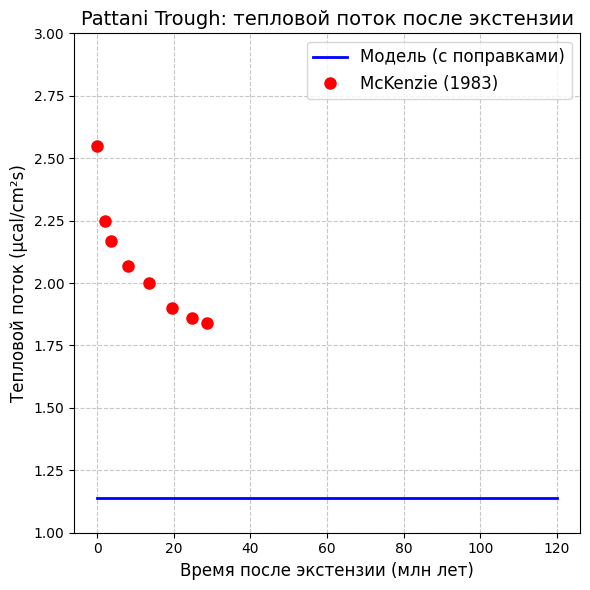

In [4]:
import numpy as np
import matplotlib.pyplot as plt

K = 7.5e-3       # теплопроводность (cal/cm s °C)
Tm = 1333        # температура астеносферы (°C)
a = 125e7        # толщина литосферы (cm)
tc = 30e7        # толщина коры (cm)
kappa = 8.04e-3  # температуропроводность (cm²/s)
rho_m = 3.33     # плотность мантии (g/cm³)
rho_c = 2.8      # плотность коры (g/cm³)
alpha = 3.28e-5  # коэффициент теплового расширения (1/°C)

# beta_c = 2.35    # утонение коры
# beta_L = 1.9     # утонение литосферы

beta_c = 1.2    # утонение коры
beta_L = 3     # утонение литосферы
beta_sc = 1 / ((a/beta_L - tc/beta_c) / (a - tc))
print(beta_sc)

# Временной диапазон (0-30 млн лет)
t_myr = np.linspace(0, 120, 100)
t_sec = t_myr * 1e6 * 365.25 * 24 * 3600  # секунды
tau = a**2 / (np.pi**2 * kappa)           # тепловая постоянная времени

def calculate_heat_flow(t):
    Q_sum = 0
    for n in range(1, 5):  # Увеличиваем число членов ряда
        term1 = (beta_c - beta_sc) * np.sin(n * np.pi * tc / (a * beta_c))
        term2 = beta_sc * np.sin(n * np.pi / beta_L)
        Cn = (2 * (-1)**(n+1)) / (n**2 * np.pi**2) * (term1 + term2)
        Q_sum += (-1)**(n+1) * n * np.pi * Cn * np.exp(-n**2 * t / tau)
    
    Q_total = (K * Tm / a) * (1 + Q_sum) * 1e6  # Основной поток (µcal/cm²s)
    Q_total += 0.8 + 0.4 / beta_c               # Фон + радиогенный вклад коры
    return Q_total
    

Q = np.array([calculate_heat_flow(t) for t in t_sec])

# Данные McKenzie (1983)
data = np.array([
    [0, 2.55], [2, 2.25], [3.66, 2.17], [8.21, 2.07],
    [13.59, 2.00], [19.53, 1.90], [24.82, 1.86], [28.63, 1.84]
])

# График
plt.figure(figsize=(6, 6))
plt.plot(t_myr, Q, 'b-', linewidth=2, label='Модель (с поправками)')
plt.plot(data[:,0], data[:,1], 'ro', markersize=8, label='McKenzie (1983)')
plt.xlabel('Время после экстензии (млн лет)', fontsize=12)
plt.ylabel('Тепловой поток (µcal/cm²s)', fontsize=12)
plt.title('Pattani Trough: тепловой поток после экстензии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.xlim(0, 30)
plt.ylim(1, 3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

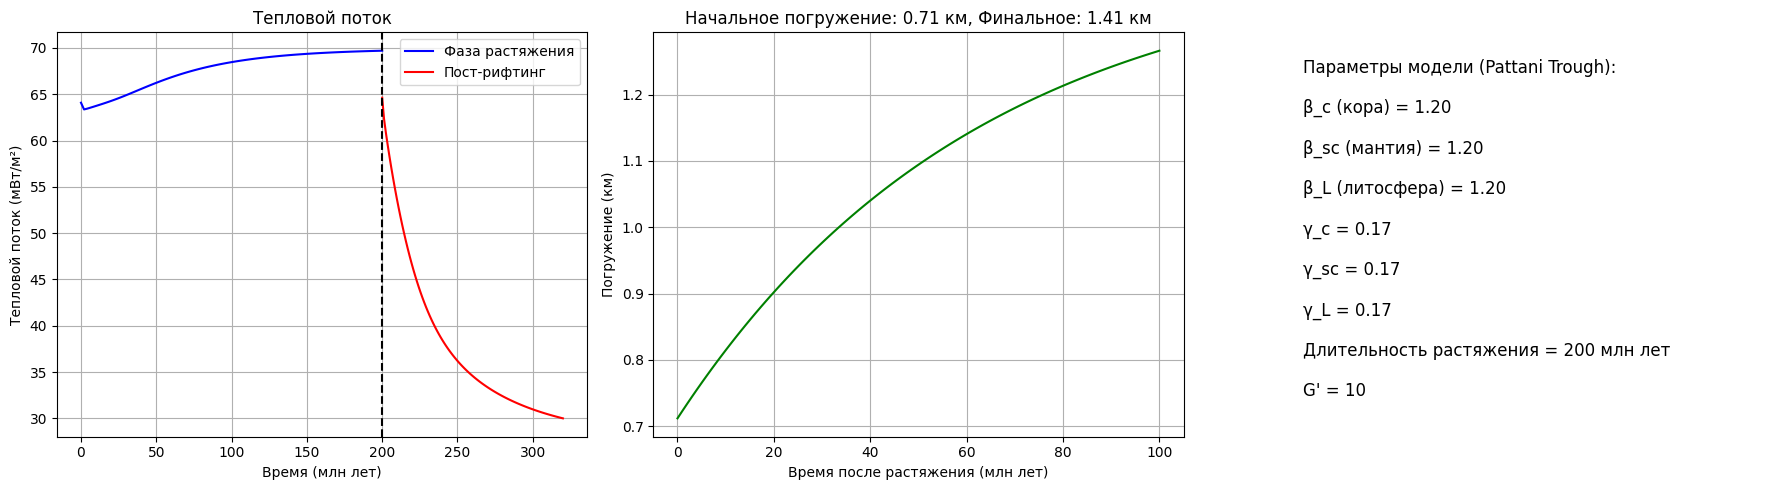

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import root_scalar

# Параметры модели (из статьи Hellinger and Sclater, 1983)
a = 125e3  # толщина литосферы (м)
t_c = 30e3  # толщина коры (м)
kappa = 1.234 * 1e-6   # тепловая диффузия (m^2/s)
k = 2.6  # теплопроводность (W/m/K)
T_m = 1330  # температура астеносферы (°C)
alpha = 3.28e-5  # коэффициент теплового расширения (1/°C)
rho_m = 3.33  # плотность мантии при 0°C (g/cm^3)
rho_c = 2.8  # плотность коры при 0°C (g/cm^3)
rho_w = 1.03  # плотность воды (g/cm^3)

# Два коэффициента растяжения (как в статье)
beta_c = 1.2  # для коры (из анализа Pattani Trough)
beta_sc = 1.2  # для субкоровой литосферы

# Расчет эквивалентного растяжения для всей литосферы (уравнение 1 из статьи)
beta_L = 1 / ( (t_c/a)/beta_c + (1 - t_c/a)/beta_sc )

# Параметры для модели растяжения
G_prime = 10  # безразмерный параметр
duration_myr = 200  # продолжительность растяжения (млн лет) для Pattani Trough
duration = duration_myr * (1e6 * 365.25 * 24 * 3600)  # в млн лет
# G_prime = (a**2 * np.log(beta)) / (kappa * 10)

class TwoLayerMcKenzieModel:
    def __init__(self, beta_c, beta_sc, G_prime=10, n_eigenvalues=10):
        self.beta_c = beta_c
        self.beta_sc = beta_sc
        self.G_prime = G_prime
        self.n_eigenvalues = n_eigenvalues
        self.z_points = np.linspace(0, 1, 1000)
        
        # Расчет параметров gamma (уравнения после (1) в статье)
        self.gamma_c = 1 - 1/beta_c
        self.gamma_sc = 1 - 1/beta_sc
        self.gamma_L = (t_c/a)*self.gamma_c + (1 - t_c/a)*self.gamma_sc
        
        # Инициализация массивов
        self.eigenvalues = []
        self.eigenfunctions = []
        self.dtheta_n = []
        self.coefficients = []
    
    def diff_eq(self, z, y, K):
        """Уравнение (A-3) из McKenzie (1978)"""
        theta, dtheta = y
        return [dtheta, -self.G_prime*(1-z)*dtheta - K*theta]
    
    def propagator_matrix(self, K):
        """Решение уравнения для матрицы propagator"""
        sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                        (0, 1), [0, 1],  # Начальные условия: θ(0)=0, dθ/dz(0)=1
                        method='RK45', dense_output=True)
        return sol.sol(1)[0]  # Возвращаем θ(1)
    
    def find_eigenvalues(self):
        """Нахождение собственных значений K_n"""
        K_guesses = [(n+1)**2 * np.pi**2 + self.G_prime/2 for n in range(self.n_eigenvalues)]
        
        for guess in K_guesses:
            try:
                res = root_scalar(self.propagator_matrix, 
                                 x0=guess, 
                                 method='newton',
                                 fprime=lambda K: (self.propagator_matrix(K+1e-6) - self.propagator_matrix(K-1e-6))/2e-6)
                if res.converged and res.root > 0:
                    self.eigenvalues.append(res.root)
            except:
                continue
        
        self.eigenvalues = sorted(list(set(self.eigenvalues))[:self.n_eigenvalues])
    
    def compute_eigenfunctions(self):
        """Вычисление собственных функций θ_n(z)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1],
                           t_eval=self.z_points, 
                           method='RK45')
            self.eigenfunctions.append(sol.y[0])
    
    def compute_derivatives(self):
        """Вычисление производных dθ_n/dz на поверхности (z=1)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1], 
                           t_eval=[1], 
                           method='RK45')
            self.dtheta_n.append(sol.y[1][0])
    
    def _compute_normalization(self, theta_n):
        """Вычисление нормировочного интеграла для θ_n"""
        integrand = np.exp((self.z_points - 1)**2 * self.G_prime/2) * theta_n**2
        return trapezoid(integrand, self.z_points)
    
    def _compute_coefficient(self, initial_condition, theta_n, norm):
        """Вычисление коэффициента a_n"""
        integrand = initial_condition(self.z_points) * theta_n * np.exp((self.z_points - 1)**2 * self.G_prime/2)
        return trapezoid(integrand, self.z_points) / norm
    
    def compute_coefficients(self):
        """Вычисление всех коэффициентов a_n"""
        def initial_condition(z):
            return (1 - z) + erf((z - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        for theta_n in self.eigenfunctions:
            norm = self._compute_normalization(theta_n)
            an = self._compute_coefficient(initial_condition, theta_n, norm)
            self.coefficients.append(an)
    
    def initial_subsidence(self, water_loaded=True):
        """Начальное погружение (уравнение 3 или 4 из статьи)"""
        if water_loaded:
            return 7.27*self.gamma_c - 3.00*self.gamma_L  # в км (уравнение 3)
        else:
            return 4.99*self.gamma_c - 2.06*self.gamma_L  # в км (уравнение 4)
    
    def final_subsidence(self):
        """Финальное погружение (уравнение 6 из статьи)"""
        return 8.44 * self.gamma_c  # в км
    
    def heat_flow_during_stretching(self, t):
        """Тепловой поток во время растяжения с учетом beta_sc"""
        t_dimless = kappa * t / (a**2 * self.beta_sc**2)  # ключевое изменение!
        steady_term = np.sqrt(2 * self.G_prime / np.pi) / erf(np.sqrt(self.G_prime / 2))
        transient_term = 0
        
        for an, Kn, dtheta in zip(self.coefficients, self.eigenvalues, self.dtheta_n):
            transient_term += an * np.exp(-Kn * t_dimless) * dtheta
        
        return (k * T_m / a) * (steady_term - transient_term)
    
    def compute_post_rift_coefficients(self):
        """Коэффициенты для пост-рифтинговой фазы"""
        z_points = self.z_points
        T_final = np.zeros_like(z_points)
        
        # Стационарный член
        T_final += -erf((z_points - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        # Транзиентный член
        t_final = (a**2 * np.log(beta_L)) / (kappa * self.G_prime)
        t_dimless = kappa * t_final / a**2
        
        for an, Kn, theta_n in zip(self.coefficients, self.eigenvalues, self.eigenfunctions):
            T_final += an * np.exp(-Kn * t_dimless) * theta_n
        
        # Коэффициенты b_n
        b_coeffs = []
        for n in range(1, self.n_eigenvalues + 1):
            integrand = (T_final + (z_points - 1)) * np.sin(n * np.pi * z_points)
            bn = 2 * trapezoid(integrand, z_points)
            b_coeffs.append(bn)
        
        return b_coeffs
    
    def heat_flow_post_rift(self, t_post, b_coeffs):
        """Тепловой поток после растяжения с учетом beta_sc"""
        t_dimless = kappa * t_post / (a**2 * self.beta_sc**2)  # ключевое изменение!
        steady_term = 1
        transient_term = 0
        
        for n, bn in enumerate(b_coeffs, start=1):
            transient_term += n * bn * (-1)**(n+1) * np.exp(-n**2 * np.pi**2 * t_dimless)
        
        return (k * T_m / a) * (steady_term + np.pi * transient_term)
    
    def thermal_subsidence(self, t_post):
        """Термическое погружение после растяжения"""
        tau = a**2 / (np.pi**2 * kappa)  # характерное время
        subsidence = 0
        for n in range(1, 20):
            term = (1 - np.exp(-n**2 * t_post / tau)) / n**2
            subsidence += term
        return (4 * a * alpha * rho_m * T_m / (np.pi**2 * (rho_m - rho_w))) * subsidence

# Инициализация модели с двумя коэффициентами растяжения
model = TwoLayerMcKenzieModel(beta_c=beta_c, beta_sc=beta_sc, G_prime=G_prime)
model.find_eigenvalues()
model.compute_eigenfunctions()
model.compute_derivatives()
model.compute_coefficients()
b_coeffs = model.compute_post_rift_coefficients()

# Расчет теплового потока
time_stretch = np.linspace(0, duration, 100)  # фаза растяжения
time_post = np.linspace(0, 120e6*365.25*24*3600, 100)  # пост-рифтинг (100 млн лет)

F_stretch = [model.heat_flow_during_stretching(t) for t in time_stretch]
F_post = [model.heat_flow_post_rift(t, b_coeffs) for t in time_post]

# Конвертация единиц
F_stretch_mW = np.array(F_stretch) * 1e3  # мВт/м²
F_post_mW = np.array(F_post) * 1e3        # мВт/м²
mW_to_mkcal = 0.0238846  # коэффициент перевода
F_stretch_mkcal = F_stretch_mW * mW_to_mkcal
F_post_mkcal = F_post_mW * mW_to_mkcal

# Временные оси
t_stretch_myr = time_stretch / (1e6 * 365.25 * 24 * 3600)
t_post_myr = time_post / (1e6 * 365.25 * 24 * 3600) + duration_myr

# Расчет погружения
S_i = model.initial_subsidence(water_loaded=True)
S_inf = model.final_subsidence()
time_subsidence = np.linspace(0, 100, 100)  # млн лет после растяжения
S_t = S_i + (S_inf - S_i) * (1 - np.exp(-time_subsidence/62.5))  # упрощенная модель

# Визуализация результатов
plt.figure(figsize=(18, 5))

# 1. Тепловой поток
plt.subplot(1, 3, 1)
plt.plot(t_stretch_myr, F_stretch_mW, 'b-', label='Фаза растяжения')
plt.plot(t_post_myr, F_post_mW, 'r-', label='Пост-рифтинг')
plt.axvline(duration_myr, color='k', linestyle='--')
plt.xlabel('Время (млн лет)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title('Тепловой поток')
plt.grid()
plt.legend()

# 2. Погружение
plt.subplot(1, 3, 2)
plt.plot(time_subsidence, S_t, 'g-')
plt.xlabel('Время после растяжения (млн лет)')
plt.ylabel('Погружение (км)')
plt.title(f'Начальное погружение: {S_i:.2f} км, Финальное: {S_inf:.2f} км')
plt.grid()

# 3. Параметры модели
plt.subplot(1, 3, 3)
plt.axis('off')
plt.text(0.1, 0.9, f'Параметры модели (Pattani Trough):', fontsize=12)
plt.text(0.1, 0.8, f'β_c (кора) = {beta_c:.2f}', fontsize=12)
plt.text(0.1, 0.7, f'β_sc (мантия) = {beta_sc:.2f}', fontsize=12)
plt.text(0.1, 0.6, f'β_L (литосфера) = {beta_L:.2f}', fontsize=12)
plt.text(0.1, 0.5, f'γ_c = {model.gamma_c:.2f}', fontsize=12)
plt.text(0.1, 0.4, f'γ_sc = {model.gamma_sc:.2f}', fontsize=12)
plt.text(0.1, 0.3, f'γ_L = {model.gamma_L:.2f}', fontsize=12)
plt.text(0.1, 0.2, f'Длительность растяжения = {duration_myr} млн лет', fontsize=12)
plt.text(0.1, 0.1, f'G\' = {G_prime}', fontsize=12)

plt.tight_layout()
plt.show()

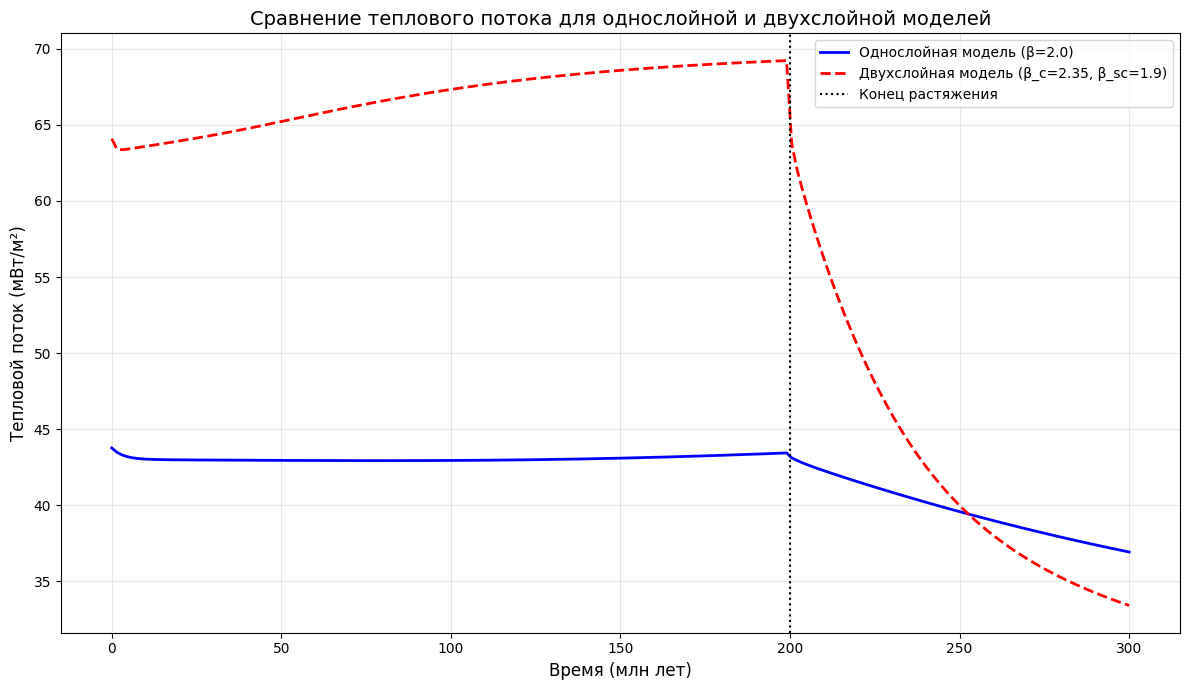

In [6]:
# Инициализация моделей
model_one_layer = TwoLayerMcKenzieModel(beta_c=1.2, beta_sc=3, G_prime=5)
model_two_layer = TwoLayerMcKenzieModel(beta_c=1.2, beta_sc=1.44, G_prime=10)

# Инициализация и расчеты для обеих моделей
for model in [model_one_layer, model_two_layer]:
    model.find_eigenvalues()
    model.compute_eigenfunctions()
    model.compute_derivatives()
    model.compute_coefficients()


# Расчет теплового потока
time_myr = np.linspace(0, duration_myr + 100, 200)  # 100 млн лет после растяжения
time_sec = time_myr * 1e6 * 365.25 * 24 * 3600

# Функция для расчета полного теплового потока
def calculate_total_heat_flow(model, time_sec, duration):
    heat_flow = []
    for t in time_sec:
        if t <= duration:
            # Фаза растяжения
            heat_flow.append(model.heat_flow_during_stretching(t))
        else:
            # Пост-рифтинговая фаза
            b_coeffs = model.compute_post_rift_coefficients()
            heat_flow.append(model.heat_flow_post_rift(t - duration, b_coeffs))
    return np.array(heat_flow) * 1e3  # Конвертация в мВт/м²

# Расчет для обеих моделей
heat_flow_one_layer = calculate_total_heat_flow(model_one_layer, time_sec, duration)
heat_flow_two_layer = calculate_total_heat_flow(model_two_layer, time_sec, duration)

# Создание графика
plt.figure(figsize=(12, 7))

# Графики теплового потока
plt.plot(time_myr, heat_flow_one_layer, 'b-', linewidth=2, 
         label=f'Однослойная модель (β=2.0)')
plt.plot(time_myr, heat_flow_two_layer, 'r--', linewidth=2, 
         label=f'Двухслойная модель (β_c=2.35, β_sc=1.9)')

# Вертикальная линия окончания растяжения
plt.axvline(duration_myr, color='k', linestyle=':', label='Конец растяжения')

# Настройки графика
plt.xlabel('Время (млн лет)', fontsize=12)
plt.ylabel('Тепловой поток (мВт/м²)', fontsize=12)
plt.title('Сравнение теплового потока для однослойной и двухслойной моделей', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper right')



plt.tight_layout()
plt.show()

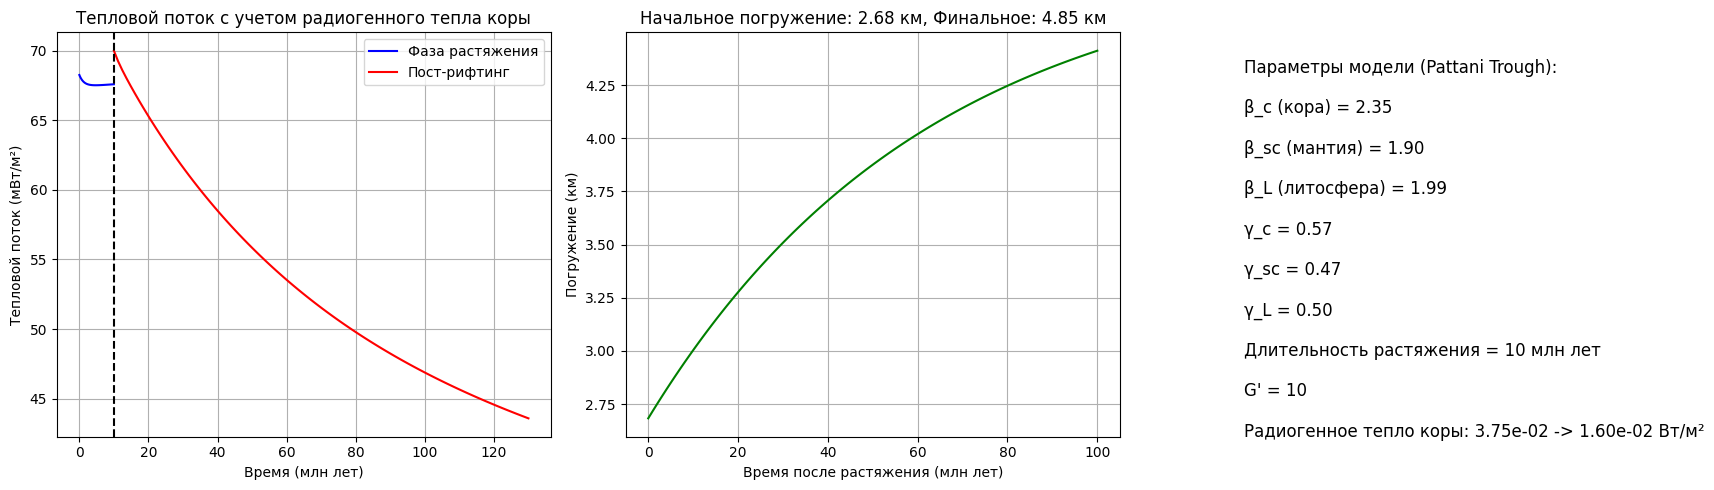

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import root_scalar

# Параметры модели (из статьи Hellinger and Sclater, 1983)
a = 125e3  # толщина литосферы (м)
t_c = 30e3  # толщина коры (м)
kappa = 1.234 * 1e-6   # тепловая диффузия (m^2/s)
k = 2.6  # теплопроводность (W/m/K)
T_m = 1330  # температура астеносферы (°C)
alpha = 3.28e-5  # коэффициент теплового расширения (1/°C)
rho_m = 3.33  # плотность мантии при 0°C (g/cm^3)
rho_c = 2.8  # плотность коры при 0°C (g/cm^3)
rho_w = 1.03  # плотность воды (g/cm^3)

# Два коэффициента растяжения (как в статье)
beta_c = 2.35  # для коры (из анализа Pattani Trough)
beta_sc = 1.90  # для субкоровой литосферы

# Параметры радиогенного тепла коры
A0 = 1.25e-6  # теплопродукция коры (Вт/м³) - типичное значение для континентальной коры
A0 = A0 * t_c  # интегральная теплопродукция (Вт/м²)
a_r = 8e3  # 8 км, глубина залегания радиоактивных элементов
tau_r = 2.5e9 * 365.25 * 24 * 3600  # ~2.5 млрд лет (характерное время затухания)

# Расчет эквивалентного растяжения для всей литосферы (уравнение 1 из статьи)
beta_L = 1 / ( (t_c/a)/beta_c + (1 - t_c/a)/beta_sc )

# Параметры для модели растяжения
G_prime = 10  # безразмерный параметр
duration_myr = 10  # продолжительность растяжения (млн лет) для Pattani Trough
duration = duration_myr * (1e6 * 365.25 * 24 * 3600)  # в секундах

class TwoLayerMcKenzieModel:
    def __init__(self, beta_c, beta_sc, G_prime=10, n_eigenvalues=10):
        self.beta_c = beta_c
        self.beta_sc = beta_sc
        self.G_prime = G_prime
        self.n_eigenvalues = n_eigenvalues
        self.z_points = np.linspace(0, 1, 1000)
        
        # Расчет параметров gamma (уравнения после (1) в статье)
        self.gamma_c = 1 - 1/beta_c
        self.gamma_sc = 1 - 1/beta_sc
        self.gamma_L = (t_c/a)*self.gamma_c + (1 - t_c/a)*self.gamma_sc
        
        # Радиогенное тепло коры (уменьшается с растяжением)
        self.A_crust = A0 / beta_c  # теплопродукция после растяжения
        
        # Инициализация массивов
        self.eigenvalues = []
        self.eigenfunctions = []
        self.dtheta_n = []
        self.coefficients = []
    
    def diff_eq(self, z, y, K):
        """Уравнение (A-3) из McKenzie (1978)"""
        theta, dtheta = y
        return [dtheta, -self.G_prime*(1-z)*dtheta - K*theta]
    
    def propagator_matrix(self, K):
        """Решение уравнения для матрицы propagator"""
        sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                        (0, 1), [0, 1],  # Начальные условия: θ(0)=0, dθ/dz(0)=1
                        method='RK45', dense_output=True)
        return sol.sol(1)[0]  # Возвращаем θ(1)
    
    def find_eigenvalues(self):
        """Нахождение собственных значений K_n"""
        K_guesses = [(n+1)**2 * np.pi**2 + self.G_prime/2 for n in range(self.n_eigenvalues)]
        
        for guess in K_guesses:
            try:
                res = root_scalar(self.propagator_matrix, 
                                 x0=guess, 
                                 method='newton',
                                 fprime=lambda K: (self.propagator_matrix(K+1e-6) - self.propagator_matrix(K-1e-6))/2e-6)
                if res.converged and res.root > 0:
                    self.eigenvalues.append(res.root)
            except:
                continue
        
        self.eigenvalues = sorted(list(set(self.eigenvalues))[:self.n_eigenvalues])
    
    def compute_eigenfunctions(self):
        """Вычисление собственных функций θ_n(z)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1],
                           t_eval=self.z_points, 
                           method='RK45')
            self.eigenfunctions.append(sol.y[0])
    
    def compute_derivatives(self):
        """Вычисление производных dθ_n/dz на поверхности (z=1)"""
        for K in self.eigenvalues:
            sol = solve_ivp(lambda z, y: self.diff_eq(z, y, K), 
                           (0, 1), [0, 1], 
                           t_eval=[1], 
                           method='RK45')
            self.dtheta_n.append(sol.y[1][0])
    
    def _compute_normalization(self, theta_n):
        """Вычисление нормировочного интеграла для θ_n"""
        integrand = np.exp((self.z_points - 1)**2 * self.G_prime/2) * theta_n**2
        return trapezoid(integrand, self.z_points)
    
    def _compute_coefficient(self, initial_condition, theta_n, norm):
        """Вычисление коэффициента a_n"""
        integrand = initial_condition(self.z_points) * theta_n * np.exp((self.z_points - 1)**2 * self.G_prime/2)
        return trapezoid(integrand, self.z_points) / norm
    
    def compute_coefficients(self):
        """Вычисление всех коэффициентов a_n"""
        def initial_condition(z):
            return (1 - z) + erf((z - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        for theta_n in self.eigenfunctions:
            norm = self._compute_normalization(theta_n)
            an = self._compute_coefficient(initial_condition, theta_n, norm)
            self.coefficients.append(an)
    
    def initial_subsidence(self, water_loaded=True):
        """Начальное погружение (уравнение 3 или 4 из статьи)"""
        if water_loaded:
            return 7.27*self.gamma_c - 3.00*self.gamma_L  # в км (уравнение 3)
        else:
            return 4.99*self.gamma_c - 2.06*self.gamma_L  # в км (уравнение 4)
    
    def final_subsidence(self):
        """Финальное погружение (уравнение 6 из статьи)"""
        return 8.44 * self.gamma_c  # в км
    
    def heat_flow_during_stretching(self, t):
        t_dimless = kappa * t / (a**2 * self.beta_sc**2)
        steady_term = np.sqrt(2 * self.G_prime / np.pi) / erf(np.sqrt(self.G_prime / 2))
        transient_term = 0
        
        for an, Kn, dtheta in zip(self.coefficients, self.eigenvalues, self.dtheta_n):
            transient_term += an * np.exp(-Kn * t_dimless) * dtheta
        
        # Новая радиогенная составляющая
        crustal_heat = (A0 / self.beta_c) * (a_r / t_c) * (1 - np.exp(-t_c / a_r)) * np.exp(-t / tau_r)
        return (k * T_m / a) * (steady_term - transient_term) + crustal_heat
    
    def compute_post_rift_coefficients(self):
        """Коэффициенты для пост-рифтинговой фазы"""
        z_points = self.z_points
        T_final = np.zeros_like(z_points)
        
        # Стационарный член
        T_final += -erf((z_points - 1) * np.sqrt(self.G_prime/2)) / erf(np.sqrt(self.G_prime/2))
        
        # Транзиентный член
        t_final = (a**2 * np.log(beta_L)) / (kappa * self.G_prime)
        t_dimless = kappa * t_final / a**2
        
        for an, Kn, theta_n in zip(self.coefficients, self.eigenvalues, self.eigenfunctions):
            T_final += an * np.exp(-Kn * t_dimless) * theta_n
        
        # Коэффициенты b_n
        b_coeffs = []
        for n in range(1, self.n_eigenvalues + 1):
            integrand = (T_final + (z_points - 1)) * np.sin(n * np.pi * z_points)
            bn = 2 * trapezoid(integrand, z_points)
            b_coeffs.append(bn)
        
        return b_coeffs
        
    def heat_flow_post_rift(self, t_post, b_coeffs):
        t_dimless = kappa * t_post / (a**2 * self.beta_sc**2)
        steady_term = 1
        transient_term = 0
        
        for n, bn in enumerate(b_coeffs, start=1):
            transient_term += n * bn * (-1)**(n+1) * np.exp(-n**2 * np.pi**2 * t_dimless)
        
        # Новая радиогенная составляющая
        crustal_heat = (A0 / self.beta_c) * (a_r / t_c) * (1 - np.exp(-t_c / a_r)) * np.exp(-(t_post + duration) / tau_r)
        return (k * T_m / a) * (steady_term + np.pi * transient_term) + crustal_heat
    
    def thermal_subsidence(self, t_post):
        """Термическое погружение после растяжения"""
        tau = a**2 / (np.pi^2 * kappa)  # характерное время
        subsidence = 0
        for n in range(1, 20):
            term = (1 - np.exp(-n^2 * t_post / tau)) / n^2
            subsidence += term
        return (4 * a * alpha * rho_m * T_m / (np.pi^2 * (rho_m - rho_w))) * subsidence

# Инициализация модели с двумя коэффициентами растяжения
model = TwoLayerMcKenzieModel(beta_c=beta_c, beta_sc=beta_sc, G_prime=G_prime)
model.find_eigenvalues()
model.compute_eigenfunctions()
model.compute_derivatives()
model.compute_coefficients()
b_coeffs = model.compute_post_rift_coefficients()

# Расчет теплового потока
time_stretch = np.linspace(0, duration, 100)  # фаза растяжения
time_post = np.linspace(0, 120e6*365.25*24*3600, 100)  # пост-рифтинг (100 млн лет)

F_stretch = [model.heat_flow_during_stretching(t) for t in time_stretch]
F_post = [model.heat_flow_post_rift(t, b_coeffs) for t in time_post]

# Конвертация единиц
F_stretch_mW = np.array(F_stretch) * 1e3  # мВт/м²
F_post_mW = np.array(F_post) * 1e3        # мВт/м²
mW_to_mkcal = 0.0238846  # коэффициент перевода
F_stretch_mkcal = F_stretch_mW * mW_to_mkcal
F_post_mkcal = F_post_mW * mW_to_mkcal

# Временные оси
t_stretch_myr = time_stretch / (1e6 * 365.25 * 24 * 3600)
t_post_myr = time_post / (1e6 * 365.25 * 24 * 3600) + duration_myr

# Расчет погружения
S_i = model.initial_subsidence(water_loaded=True)
S_inf = model.final_subsidence()
time_subsidence = np.linspace(0, 100, 100)  # млн лет после растяжения
S_t = S_i + (S_inf - S_i) * (1 - np.exp(-time_subsidence/62.5))  # упрощенная модель

# Визуализация результатов
plt.figure(figsize=(18, 5))

# 1. Тепловой поток
plt.subplot(1, 3, 1)
plt.plot(t_stretch_myr, F_stretch_mW, 'b-', label='Фаза растяжения')
plt.plot(t_post_myr, F_post_mW, 'r-', label='Пост-рифтинг')
plt.axvline(duration_myr, color='k', linestyle='--')
plt.xlabel('Время (млн лет)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title('Тепловой поток с учетом радиогенного тепла коры')
plt.grid()
plt.legend()

# 2. Погружение
plt.subplot(1, 3, 2)
plt.plot(time_subsidence, S_t, 'g-')
plt.xlabel('Время после растяжения (млн лет)')
plt.ylabel('Погружение (км)')
plt.title(f'Начальное погружение: {S_i:.2f} км, Финальное: {S_inf:.2f} км')
plt.grid()

# 3. Параметры модели
plt.subplot(1, 3, 3)
plt.axis('off')
plt.text(0.1, 0.9, f'Параметры модели (Pattani Trough):', fontsize=12)
plt.text(0.1, 0.8, f'β_c (кора) = {beta_c:.2f}', fontsize=12)
plt.text(0.1, 0.7, f'β_sc (мантия) = {beta_sc:.2f}', fontsize=12)
plt.text(0.1, 0.6, f'β_L (литосфера) = {beta_L:.2f}', fontsize=12)
plt.text(0.1, 0.5, f'γ_c = {model.gamma_c:.2f}', fontsize=12)
plt.text(0.1, 0.4, f'γ_sc = {model.gamma_sc:.2f}', fontsize=12)
plt.text(0.1, 0.3, f'γ_L = {model.gamma_L:.2f}', fontsize=12)
plt.text(0.1, 0.2, f'Длительность растяжения = {duration_myr} млн лет', fontsize=12)
plt.text(0.1, 0.1, f'G\' = {G_prime}', fontsize=12)
plt.text(0.1, 0.0, f'Радиогенное тепло коры: {A0:.2e} -> {model.A_crust:.2e} Вт/м²', fontsize=12)

plt.tight_layout()
plt.show()

<div style="background:#f8f9fa;padding:20px;border-radius:10px;font-size:14px">

## Полный тепловой поток с радиогенным теплом:

$$
Q(t, \beta) = \underbrace{\frac{\lambda T_1}{a} \left(1 + \sum_{n=1}^{\infty} \frac{2\beta}{n\pi} \sin\left(\frac{n\pi}{\beta}\right) \exp\left(-\frac{n^2\pi^2\kappa t}{a^2}\right)\right)}_{\text{Кондуктивная составляющая}} 
+ \underbrace{A_0 a_r \left(1 - \exp\left(-\frac{a}{a_r}\right)\right) \exp\left(-\frac{t}{\tau_r}\right)}_{\text{Радиогенная составляющая}}
$$

**Параметры:**
| Символ | Описание | Единицы измерения |
|--------|----------|-------------------|
| $\lambda$ | Теплопроводность литосферы | Вт/(м·K) |
| $T_1$ | Температура астеносферы | K |
| $a$ | Толщина литосферы | м |
| $\beta$ | Коэффициент растяжения ($\beta > 1$) | - |
| $\kappa$ | Температуропроводность | м²/с |
| $A_0$ | Поверхностная генерация радиогенного тепла | Вт/м³ |
| $a_r$ | Масштаб глубины затухания радиогенного тепла | м |
| $\tau_r$ | Характерное время затухания радиогенного тепла (~800 млн лет) | с |
| $t$ | Время с момента растяжения | с |

**Особые случаи:**
1. При $\beta = 1$ (нет растяжения):
$$
Q(t) = \frac{\lambda T_1}{a} + A_0 a_r \left(1 - e^{-a/a_r}\right) e^{-t/\tau_r}
$$

2. Для тонкой литосферы ($a \ll a_r$):
$$
Q_{rad} \approx A_0 a e^{-t/\tau_r}
$$

</div>

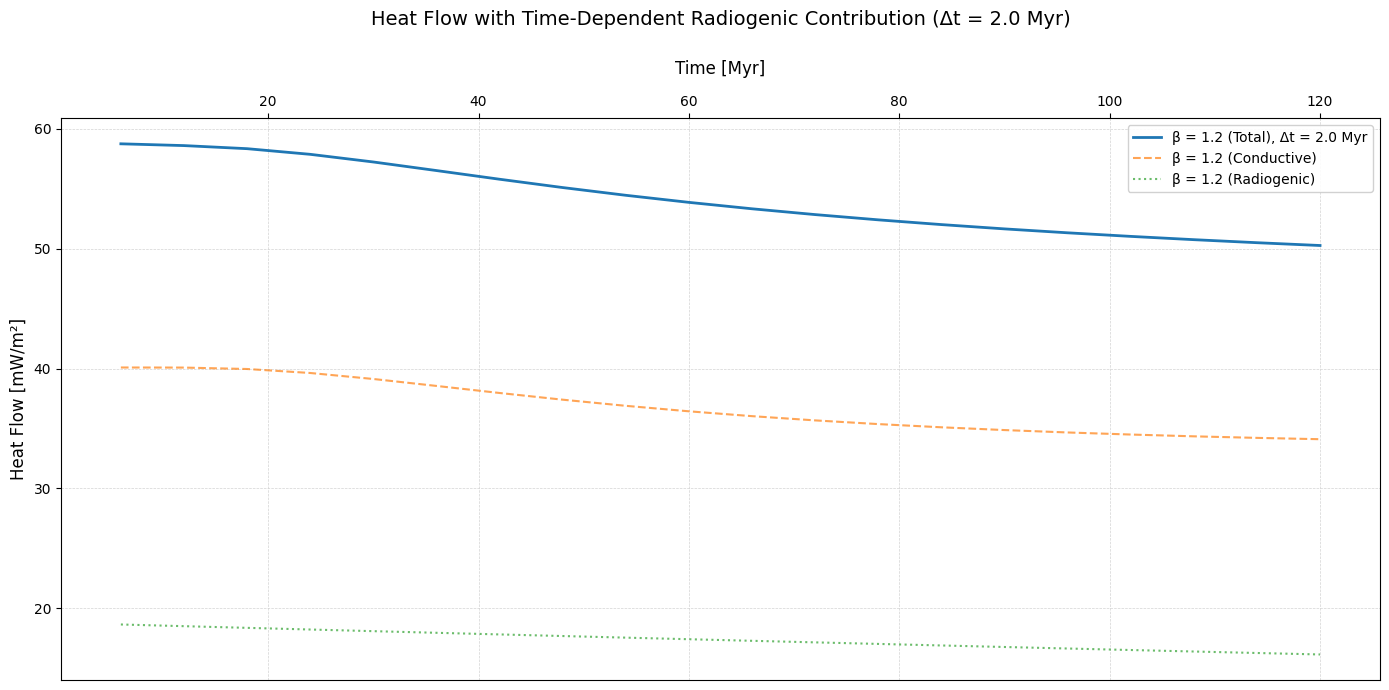

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional

# Constants
MY_TO_S = 1e6 * 365.25 * 24 * 3600  # Myr to seconds conversion
DEFAULT_PARAMS = {
    'Q_const': 63e-3,    # W/m²
    'a': 125e3,          # m (125 km)
    'kappa': 1.234e-6,       # m²/s (thermal diffusivity)
    'lam': 2.6,          # W/mK (thermal conductivity)
    'T1': 1333 + 273.15, # K (1606.15 K)
    'n_terms': 100,
    'delta_t': 0.0,      # Myr (time shift)
    'A0': 2.5e-6,        # W/m³ (surface radiogenic heat production)
    'ar': 7.5e3,          # m (10 km decay scale)
    'radiogenic_decay_time': 2.5e16  # seconds (~800 Myr decay time)
}

def calculate_heat_flow(
    beta: float,
    time_myr: float,
    Q_const: Optional[float] = None,
    constant: bool = False,
    params: Optional[dict] = None
) -> float:
    """
    Calculate heat flow with time-dependent radiogenic heat contribution.
    
    Args:
        beta: Stretching factor (β > 1)
        time_myr: Time since stretching event (Myr)
        Q_const: Constant heat flow value (W/m²)
        constant: If True, returns Q_const
        params: Dictionary of physical parameters (overrides defaults)
        
    Returns:
        Heat flow in W/m² (conductive + radiogenic components)
    """
    # Merge default and provided parameters
    p = {**DEFAULT_PARAMS, **(params or {})}
    
    if constant:
        return Q_const or p['Q_const']

    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if time_myr < 0:
        raise ValueError("Time must be non-negative")

    # Convert time to seconds
    t_sec = max(0, (time_myr - p['delta_t'])) * MY_TO_S
    
    # 1. Conductive component (lithospheric stretching)
    n = np.arange(1, p['n_terms'] + 1)
    term = (2 * beta / (n * np.pi)) * np.sin(n * np.pi / beta)
    exponent = np.exp(-(n**2 * np.pi**2 * p['kappa'] * t_sec) / p['a']**2)
    F_sum = np.sum(term * exponent)
    Q_conductive = (p['lam'] * p['T1'] / p['a']) * (1 + F_sum)
    
    # 2. Radiogenic component (time-dependent exponential model)
    # Exponential decay of radiogenic heat production with time
    decay_factor = np.exp(-t_sec / p['radiogenic_decay_time'])
    Q_radiogenic = p['A0'] * p['ar'] * (1 - np.exp(-p['a']/p['ar'])) * decay_factor
    
    return Q_conductive + Q_radiogenic

def plot_heat_flow_curves(
    time_points: np.ndarray,
    betas: List[float],
    Q_const: float = 53.7e-3,
    max_age: float = 125.0,
    delta_t: float = 0.0,
    show_components: bool = True
):
    """
    Plot heat flow curves with time-dependent radiogenic heat contribution.
    
    Args:
        time_points: Time points in Myr
        betas: List of stretching factors
        Q_const: Maximum heat flow value (W/m²)
        max_age: Maximum age threshold in Myr
        delta_t: Time shift Δt in Myr
        show_components: Show conductive/radiogenic breakdown
    """
    plt.figure(figsize=(14, 7))
    
    for beta in betas:
        total_flows = []
        conductive_flows = []
        radiogenic_flows = []
        
        params = {'delta_t': delta_t}
        
        for t in time_points:
            if t <= max_age:
                q_total = calculate_heat_flow(beta, t, params=params)
                # Get components by calculating without radiogenic heat
                params_no_rad = {**params, 'A0': 0}
                q_cond = calculate_heat_flow(beta, t, params=params_no_rad)
                q_rad = q_total - q_cond
            else:
                q_total = calculate_heat_flow(beta, max_age, params=params)
                params_no_rad = {**params, 'A0': 0}
                q_cond = calculate_heat_flow(beta, max_age, params=params_no_rad)
                q_rad = q_total - q_cond
                
            total_flows.append(q_total * 1e3)  # mW/m²
            conductive_flows.append(q_cond * 1e3)
            radiogenic_flows.append(q_rad * 1e3)
        
        # Plot total heat flow
        plt.plot(time_points, total_flows, 
                label=f'β = {beta} (Total)' + (f', Δt = {delta_t} Myr' if delta_t else ''),
                marker='', linestyle='-', linewidth=2)

        # plt.plot(time_points_m1[0:20][::-1], heat_flow_m1[0:20], marker='o', color='red', label='beta=1.2') # Petromod
        
        # Plot components if requested
        if show_components:
            plt.plot(time_points, conductive_flows, 
                    label=f'β = {beta} (Conductive)',
                    linestyle='--', linewidth=1.5, alpha=0.7)
            plt.plot(time_points, radiogenic_flows, 
                    label=f'β = {beta} (Radiogenic)',
                    linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Plot formatting
    ax = plt.gca()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', which='both', bottom=False, top=True, 
                  labelbottom=False, labeltop=True)
    
    plt.xlabel('Time [Myr]', labelpad=15, fontsize=12)
    plt.ylabel('Heat Flow [mW/m²]', fontsize=12)
    title = 'Heat Flow with Time-Dependent Radiogenic Contribution'
    if delta_t:
        title += f' (Δt = {delta_t} Myr)'
    plt.title(title, pad=25, fontsize=14)
    
    plt.legend(fontsize=10, framealpha=0.9)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    
    plt.savefig('heat_flow_with_radiogenic.png', dpi=300, bbox_inches='tight')
    plt.show()

# Example usage
time_points = np.array([6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 108, 114, 120])
stretching_factors = [1.2]

# Plot with radiogenic heat components
plot_heat_flow_curves(time_points, stretching_factors, delta_t=2.0, show_components=True)

### Формула для теплового потока с учётом задержки $dt$

$$
F(t) = k\, T_1 \left[ \frac{1}{a} + \frac{\pi}{a} \sum_{n=1}^{N} n\, b_n\, (-1)^{n+1} \exp\left(-\frac{n^2 \pi^2 K (t - t_r)}{a^2}\right) \right]
$$

где $t_r = 50$ млн лет — момент окончания рифтинга.

- $F(t)$ — тепловой поток на поверхности в момент времени $t$ после растяжения,
- $k$ — теплопроводность (cal/(cm·s·°C)),
- $T_1$ — температура астеносферы (°C),
- $a$ — толщина литосферы (см),
- $K$ — температуропроводность (см²/с),
- $dt$ — задержка (например, длительность растяжения или время между событиями),
- $N$ — число членов ряда Фурье,
- $b_n$ — коэффициенты Фурье:

$$
b_n = \frac{2}{\pi} \cdot \frac{(-1)^{n+1}}{n} \left( \frac{\beta}{n\pi} \sin\left(\frac{n\pi}{\beta}\right) \right)
$$


#### Растяжение за конечное время (Model 2)

$$
b_n = \frac{2}{a T_1} \int_0^a \left[ T(z) + T_1 \left( \frac{z}{a} - 1 \right) \right] \sin\left(\frac{n\pi z}{a}\right) dz
$$


In [9]:
time_points_m1 = np.array([6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 
                        108, 114, 120, 121, 122, 123, 124, 125, 126,127, 128, 129, 130])
heat_flow_m1 = np.array([26.97, 27.43, 27.93, 28.45, 29.02, 29.62, 30.26, 30.94, 31.67, 32.45, 33.28, 34.16, 
             35.09, 36.06, 37.08, 38.12, 39.17, 40.19, 41.13, 41.89, 39.01, 36.3, 33.76, 31.39, 
             29.17, 27.11, 25.2, 23.43, 21.79, 20.28])

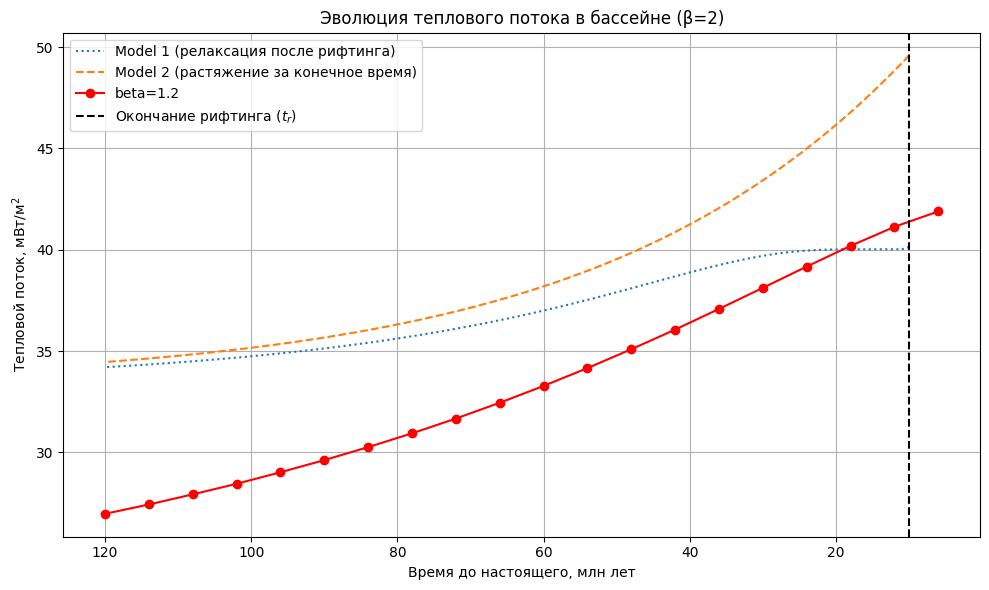

In [10]:
import numpy as np
from scipy.integrate import quad
from scipy.special import erf
import matplotlib.pyplot as plt

# Физические параметры (по статье)
a = 125e5         # Толщина литосферы, см (125 км)
T1 = 1333 +273        # Температура астеносферы, °C
beta = 1.2        # Коэффициент растяжения
# k = 0.0075        # Теплопроводность, cal/(cm s °C)
# K = 0.00804       # Термическая диффузия, cm^2/s

k = 0.620        # Теплопроводность, cal/(cm s °C)
K = 1.234e-2     # Термическая диффузия, cm^2/s

N = 30            # Число членов ряда Фурье
At = 50e6 * 3.1536e7  # Длительность растяжения (пример: 20 млн лет в секундах)

# Перевод теплового потока в мВт/м2
def to_mW(F):
    return F * 418680

# 1. Мгновенное растяжение (Model 1)
def bn_analytical(n, beta):
    return (2/np.pi) * ((-1)**(n+1) / n) * (beta / (n * np.pi) * np.sin(n * np.pi / beta))

def heat_flow_model1(t, k, T1, a, K, N, beta, t_r=0):
    if t < t_r:
        return np.nan  # До завершения рифтинга не считаем Model 1
    sum_series = 0
    for n in range(1, N+1):
        bn_val = bn_analytical(n, beta)
        term = n * bn_val * (-1)**(n+1) * np.exp(-n**2 * np.pi**2 * K * (t - t_r) / a**2)
        sum_series += term
    F = k * T1 * (1/a + np.pi / a * sum_series)
    return F 

# 2. Растяжение за конечное время (Model 2)
def T_profile_finite(z, a, T1, K, At, Gprime, Nterms=100):
    z_norm = z / a
    steady = -T1 * erf((z_norm - 1) * np.sqrt(Gprime) / 2) / erf(np.sqrt(Gprime) / 2)
    return steady

def bn_integral(n, a, T1, T_profile, *args):
    integrand = lambda z: (T_profile(z, a, T1, *args) + T1 * (z/a - 1)) * np.sin(n * np.pi * z / a)
    result, _ = quad(integrand, 0, a)
    return 2 / (a * T1) * result

def heat_flow_model2(t, k, T1, a, K, N, T_profile, *args):
    sum_series = 0
    for n in range(1, N+1):
        bn_val = bn_integral(n, a, T1, T_profile, *args)
        term = n * bn_val * (-1)**(n+1) * np.exp(-n**2 * np.pi**2 * K * t / a**2)
        sum_series += term
    F = k * T1 * (1/a + np.pi / a * sum_series)
    return F  

# Временная сетка: от 0 до 120 млн лет (шаг 1 млн лет)
years = np.arange(10, 121, 1)
seconds = years * 1e6 * 3.1536e7

# --- Настроим момент окончания рифтинга ---
t_r_Myr = 10  # млн лет назад
t_r_sec = t_r_Myr * 1e6 * 3.1536e7

# --- 1. Мгновенное растяжение (Model 1) ---
F_model1 = [to_mW(heat_flow_model1(t, k, T1, a, K, N, beta, t_r=t_r_sec)) for t in seconds] 

# --- 2. Растяжение за конечное время (Model 2) ---

stretching_time_Myr = 10   # млн лет
t_s = stretching_time_Myr * 1e6 * 3.1536e7  # в секундах
G = np.log(beta) / t_s
G_prime = a**2 * G / K
T_profile2 = lambda z, a, T1, *args: T_profile_finite(z, a, T1, K, At, G_prime)
F_model2 = [to_mW(heat_flow_model2(t, k, T1, a, K, N, T_profile2)) for t in seconds]

# Объединяем обе модели: до t_r — Model 2, после t_r — Model 1
F_total = []
for i, t in enumerate(seconds):
    if t < t_r_sec:
        F_total.append(F_model2[i])
    else:
        F_total.append(F_model1[i])

# Преобразуем списки в массивы до всех операций!
F_model1 = np.array(F_model1)
F_model2 = np.array(F_model2)
F_total = np.array(F_total)

# --- Визуализация ---
plt.figure(figsize=(10,6))
# plt.plot(years, F_total, label='Итоговый тепловой поток (Model 2 до $t_r$, Model 1 после $t_r$)')
plt.plot(years, F_model1, ':', label='Model 1 (релаксация после рифтинга)')
plt.plot(years, F_model2, '--', label='Model 2 (растяжение за конечное время)')
plt.plot(time_points_m1[0:20][::-1], heat_flow_m1[0:20], marker='o', color='red', label='beta=1.2')
plt.axvline(t_r_Myr, color='k', linestyle='--', label='Окончание рифтинга ($t_r$)')
plt.xlabel('Время до настоящего, млн лет')
plt.ylabel('Тепловой поток, мВт/м$^2$')
plt.title('Эволюция теплового потока в бассейне (β=2)')
plt.gca().invert_xaxis()
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


β = 1.2: Heat flux = -34.06 mW/m²
β = 1.5: Heat flux = -22.09 mW/m²
β = 2.0: Heat flux = -12.01 mW/m²
β = 3.0: Heat flux = -4.64 mW/m²


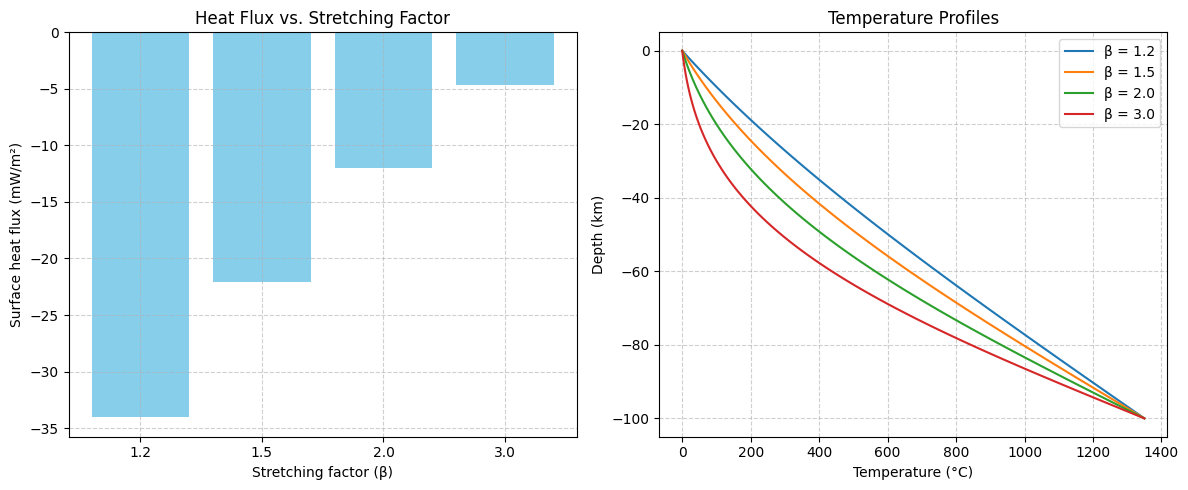

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Parameters (SI units)
# ======================
lambda_ = 3.5           # Thermal conductivity (W/m/K)
rho = 3300              # Density (kg/m³)
c = 1000                # Specific heat capacity (J/kg/K)
h0 = 100e3              # Lithosphere thickness (100 km → m)
Q_r = 0                 # Radiogenic heat production (W/m³)
t_s = 50e6 * 365*24*3600  # Stretching duration (50 Myr → seconds)

# Stretching factors (β)
betas = [1.2, 1.5, 2.0, 3.0]

# Numerical grid
Nz = 100                # Number of depth points
dz = h0 / (Nz - 1)      # Depth step (m)
z = np.linspace(0, h0, Nz)  # Depth array (m)

# Time parameters (adjusted for stability)
dt = 0.01e6 * 365*24*3600  # Smaller time step (0.01 Myr → seconds)
Nt = int(t_s / dt)      # Number of time steps

# ======================
# Finite Difference Solver (Stable)
# ======================
def compute_heat_flux(beta):
    # Initial temperature profile (linear)
    T = 1350 * (z / h0)
    
    for n in range(Nt):
        T_new = T.copy()
        for i in range(1, Nz-1):
            # Vertical velocity due to stretching
            v_z = (np.log(beta) / t_s) * (h0 - z[i])
            
            # Central differences for derivatives
            d2T_dz2 = (T[i+1] - 2*T[i] + T[i-1]) / dz**2
            dT_dz = (T[i+1] - T[i-1]) / (2*dz)
            
            # Update temperature (ensure no overflow)
            term = (lambda_ * d2T_dz2) - (rho * c * v_z * dT_dz) + Q_r
            T_new[i] = T[i] + (dt / (rho * c)) * term
        
        # Boundary conditions
        T_new[0] = 0           # Surface temperature fixed (0°C)
        T_new[-1] = 1350       # Mantle temperature fixed (1350°C)
        T = T_new
    
    # Surface heat flux (q = -λ ∂T/∂z at z=0)
    dT_dz_surface = (T[1] - T[0]) / dz
    q = -lambda_ * dT_dz_surface * 1e3  # mW/m²
    return q, T

# ======================
# Compute for all β values
# ======================
heat_fluxes = []
temperature_profiles = []

for beta in betas:
    q, T = compute_heat_flux(beta)
    heat_fluxes.append(q)
    temperature_profiles.append(T)
    print(f"β = {beta}: Heat flux = {q:.2f} mW/m²")

# ======================
# Plotting
# ======================
plt.figure(figsize=(12, 5))

# Plot 1: Heat flux vs β
plt.subplot(1, 2, 1)
plt.bar([str(b) for b in betas], heat_fluxes, color='skyblue')
plt.xlabel("Stretching factor (β)")
plt.ylabel("Surface heat flux (mW/m²)")
plt.title("Heat Flux vs. Stretching Factor")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Temperature profiles
plt.subplot(1, 2, 2)
for beta, T in zip(betas, temperature_profiles):
    plt.plot(T, -z/1e3, label=f'β = {beta}')
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (km)")
plt.title("Temperature Profiles")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Parameters (SI units)
# ======================
lambda_ = 3.5           # Thermal conductivity (W/m/K)
rho = 3300              # Density (kg/m³)
c = 1000                # Specific heat capacity (J/kg/K)
h0 = 100e3              # Lithosphere thickness (100 km → m)
Q_r = 0                 # Radiogenic heat production (W/m³)
t_s = 50e6 * 365*24*3600  # Stretching duration (50 Myr → seconds)

# Stretching factors (β)
betas = [1.2, 1.5, 2.0, 3.0]

# Numerical grid
Nz = 100                # Number of depth points
dz = h0 / (Nz - 1)      # Depth step (m)
z = np.linspace(0, h0, Nz)  # Depth array (m)

# Time parameters (adjusted for stability)
dt = 0.01e6 * 365*24*3600  # Time step (0.01 Myr → seconds)
Nt = int(t_s / dt)      # Number of time steps
time_myr = np.linspace(0, 50, Nt)  # Time array (Myr)

# ======================
# Finite Difference Solver (Stable)
# ======================
def compute_heat_flux_history(beta):
    # Initial temperature profile (linear)
    T = 1350 * (z / h0)
    q_history = np.zeros(Nt)  # Store heat flux at each time step
    
    for n in range(Nt):
        T_new = T.copy()
        for i in range(1, Nz-1):
            # Vertical velocity due to stretching
            v_z = (np.log(beta) / t_s) * (h0 - z[i])
            
            # Central differences for derivatives
            d2T_dz2 = (T[i+1] - 2*T[i] + T[i-1]) / dz**2
            dT_dz = (T[i+1] - T[i-1]) / (2*dz)
            
            # Update temperature
            term = (lambda_ * d2T_dz2) - (rho * c * v_z * dT_dz) + Q_r
            T_new[i] = T[i] + (dt / (rho * c)) * term
        
        # Boundary conditions
        T_new[0] = 0           # Surface temperature fixed (0°C)
        T_new[-1] = 1350       # Mantle temperature fixed (1350°C)
        T = T_new
        
        # Compute and store heat flux at current time
        dT_dz_surface = (T[1] - T[0]) / dz
        q_history[n] = -lambda_ * dT_dz_surface * 1e3  # mW/m²
    
    return q_history, T

# ======================
# Compute heat flux history for all β
# ======================
heat_flux_histories = []
temperature_profiles = []

for beta in betas:
    q_history, T = compute_heat_flux_history(beta)
    heat_flux_histories.append(q_history)
    temperature_profiles.append(T)
    print(f"β = {beta}: Max heat flux = {np.max(q_history):.2f} mW/m²")

# ======================
# Plotting
# ======================
plt.figure(figsize=(12, 5))

# Plot 1: Heat flux vs time for different β
plt.subplot(1, 2, 1)
for beta, q_history in zip(betas, heat_flux_histories):
    plt.plot(time_myr, q_history, label=f'β = {beta}')
plt.xlabel("Time (Myr)")
plt.ylabel("Surface heat flux (mW/m²)")
plt.title("Heat Flux Evolution During Stretching")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Temperature profiles at t = t_s
plt.subplot(1, 2, 2)
for beta, T in zip(betas, temperature_profiles):
    plt.plot(T, -z/1e3, label=f'β = {beta}')
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (km)")
plt.title("Temperature Profiles at 50 Myr")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

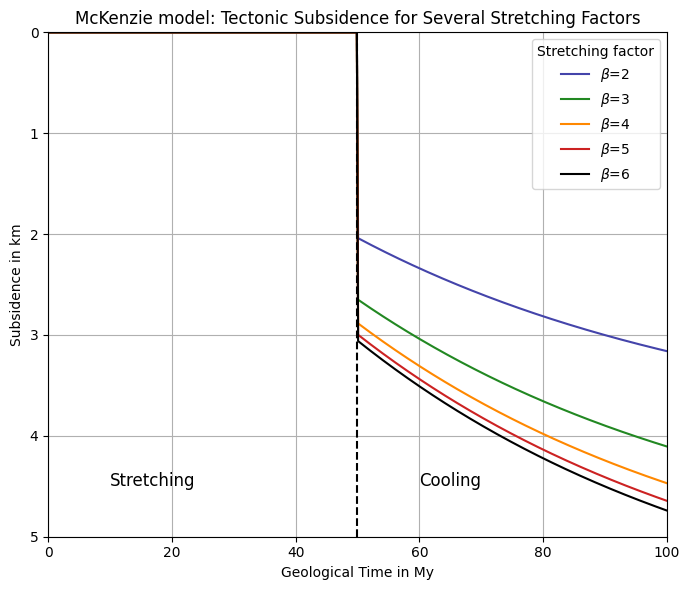

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
kappa = 0.804e-6  # м^2/с
h_c = 30e3        # м
h_m = 95e3        # м
h0 = h_c + h_m    # м
ts_My = 50
t_max_My = 100

E0 = 3.2          # км (масштаб осадки, Parsons & Sclater, 1977)
t_My = np.linspace(0, t_max_My, 500)
t_sec = t_My * 1e6 * 365.25 * 24 * 3600

betas = [2, 3, 4, 5, 6]
colors = ['#4444aa', '#228822', '#ff8800', '#cc2222', '#000000']

plt.figure(figsize=(7,6))
for idx, beta in enumerate(betas):
    r = beta / np.pi * np.sin(np.pi / beta)
    tau = h0**2 / (kappa * (np.pi**2))
    # Осадка после растяжения (t > ts)
    e = np.zeros_like(t_My)
    e[t_My < ts_My] = 0
    e[t_My >= ts_My] = E0 * r * (1 - np.exp(-(t_My[t_My >= ts_My] - ts_My) * 1e6 * 365.25 * 24 * 3600 / tau))
    # Суммарная осадка (стартовая + пост-рифтовая)
    subsidence = E0 * r * (t_My >= ts_My) + e
    plt.plot(t_My, subsidence, color=colors[idx], label=f'$\\beta$={beta}')

plt.axvline(ts_My, color='k', linestyle='--')
plt.xlabel('Geological Time in My')
plt.ylabel('Subsidence in km')
plt.ylim(0, 5)
plt.xlim(0, 100)
plt.title('McKenzie model: Tectonic Subsidence for Several Stretching Factors')
plt.legend(title='Stretching factor')
plt.gca().invert_yaxis()  # как на оригинальном графике: осадка вниз
plt.text(10, 4.5, 'Stretching', fontsize=12)
plt.text(60, 4.5, 'Cooling', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


# HeatFlow Computation | New version | 2010

A MATLAB program for 1D strain rate inversion: https://doi.org/10.1016/j.cageo.2009.08.002

## 1. Основное уравнение теплопередачи
Уравнение теплопроводности с адвективным членом (формула 2 в статье):

$$
\frac{\partial T}{\partial t} + G(t)(a - z) \frac{\partial T}{\partial z} = \kappa \frac{\partial^2 T}{\partial z^2}
$$

Где:
- $T$ - температура (°C)
- $t$ - время (Ma)
- $G(t)$ - скорость деформации (1/Ma)
- $a$ - толщина литосферы (km)
- $z$ - глубина (km)
- $\kappa$ - температуропроводность (m²/s)

## 2. Связь скорости деформации и растяжения
Связь между скоростью деформации $G(t)$ и коэффициентом растяжения $\beta$:

$$
\beta = \exp\left( \int_{0}^{\Delta t} G(t) dt \right)
$$

Для частных случаев:
- **Постоянная скорость деформации**:
  $$
  \beta = \exp(G \cdot \Delta t)
  $$
- **Экспоненциально убывающая** (формула 16-17):
  $$
  G(t) = G_0 e^{-t/\tau}, \quad G_0 = \frac{\ln \beta}{\tau(1 - e^{-\Delta t/\tau})}
  $$
- **Экспоненциально возрастающая** (формула 18-19):
  $$
  G(t) = G_0 e^{t/\tau}, \quad G_0 = \frac{\ln \beta}{\tau(e^{\Delta t/\tau} - 1)}
  $$

## 3. Численная схема (Crank-Nicolson)
Дискретизация уравнения (формула 13):

$$
\left[-\lambda - \frac{r}{2}G(n\tau)(a-jh)\right]T_{j+1}^{n+1} + 2(1+\lambda)T_j^{n+1} + \left[-\lambda + \frac{r}{2}G(n\tau)(a-jh)\right]T_{j-1}^{n+1} = \\
\left[\lambda + \frac{r}{2}G(n\tau)(a-jh)\right]T_{j-1}^n + 2(1-\lambda)T_j^n + \left[\lambda - \frac{r}{2}G(n\tau)(a-jh)\right]T_{j+1}^n
$$

Где:
- $\lambda = \kappa(\tau/h^2)$
- $r = \tau/h$
- $\tau$ - шаг по времени
- $h$ - шаг по глубине

## 4. Расчет теплового потока
Тепловой поток на поверхности (формула в коде):

$$
q = -k \left( \frac{-3T_0 + 4T_1 - T_2}{2\Delta z} \right)
$$

Где:
- $k$ - теплопроводность (W/m/°C)
- $T_0, T_1, T_2$ - температуры на поверхности и двух нижележащих узлах
- $\Delta z$ - шаг по глубине (в метрах)

## 5. Параметры модели (Таблица 1)
| Параметр       | Значение | Единицы измерения |
|----------------|----------|-------------------|
| $T_1$          | 1333     | °C                |
| $a$            | 120      | km                |
| $\kappa$       | 1e-6     | m²/s              |
| $\rho_m$       | 3300     | kg/m³             |
| $\rho_c$       | 2800     | kg/m³             |
| $\rho_w$       | 1000     | kg/m³             |
| $\alpha$       | 3.28e-5  | 1/°C              |
| $k$            | 3.138    | W/m/°C            |

## 6. Начальные и граничные условия
- **Начальное условие** (формула 14):
  $$
  T(z,0) = T_1 \left(1 - \frac{z}{a}\right)
  $$
  
- **Граничные условия** (формула 15):
  $$
  T(0,t) = T_1, \quad T(a,t) = 0
  $$

## 7. Алгоритм инверсии (формула 11)
Целевая функция для минимизации:

$$
H = \left[ \frac{1}{N}\sum_{k=1}^N \left(\frac{S_k^o - S_k^c}{\sigma_i}\right)^2 \right]^{1/2} + W_1 \left[ \frac{1}{M-1}\sum_{k=2}^M \left(\frac{G_k - G_{k-1}}{\delta t}\right)^2 \right]^{1/2} + \\ W_2 \left[ \frac{1}{M}\sum_{k=1}^M \left(\frac{G_k''}{\delta t}\right)^2 \right]^{1/2} + W_3 \left[ \frac{1}{M}\sum_{k=1}^M \log(G_k) \right]
$$

Где:
- $S_k^o, S_k^c$ - наблюдаемое и расчетное осаждение
- $W_1=0.5, W_2=0.5, W_3=0.05$ - весовые коэффициенты

# Сравнение моделей с одним и двумя коэффициентами растяжения

##  Разница между моделями

**Модель с одним β**:
- **Единый коэффициент растяжения** для всей литосферы
- **Однородная деформация**: 
  $$ G_{crust}(t) = G_{mantle}(t) $$
- **Упрощенное уравнение**:
  $$ \frac{\partial T}{\partial t} + G(t)(a-z)\frac{\partial T}{\partial z} = \kappa \frac{\partial^2 T}{\partial z^2} $$

**Модель с двумя β**:
- **Разные коэффициенты** для коры (β<sub>crust</sub>) и мантии (β<sub>mantle</sub>)
- **Независимая деформация**:
  $$ G_{crust}(t) \neq G_{mantle}(t) $$
- **Слоистые уравнения**:
  ```math
1. Кора: 
   $$\frac{\partial T}{\partial t} + G_c(t)(a_c - z)\frac{\partial T}{\partial z} = \kappa \frac{\partial^2 T}{\partial z^2}$$

2. Мантия:
   $$\frac{\partial T}{\partial t} + G_m(t)(a - z)\frac{\partial T}{\partial z} = \kappa \frac{\partial^2 T}{\partial z^2}$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

### Модель с одним β

In [4]:
def single_beta_model(beta=2.0, tau=50.0, k=2, a_crust=30.0, plot=False):
    """Модель с одним коэффициентом растяжения для всей литосферы.
    
    Параметры:
        beta - коэффициент растяжения
        tau - временной параметр экспоненциального затухания (Ma)
        k - теплопроводность (W/m/°C)
        a_crust - толщина коры (km)
        plot - отображать график (True/False)
        
    Возвращает:
        time, heat_flow - массивы времени и теплового потока
    """
    # Основные параметры
    T1 = 1330          # Температура астеносферы
    a = 125            # Толщина литосферы
    kappa = 1.234e-6   # Температуропроводность
    
    # Временные параметры
    t_total = 130; dt = 0.1
    nt = int(t_total/dt) + 1
    time = np.linspace(0, t_total, nt)
    
    # Пространственные параметры
    nz = 200; dz = a/(nz-1)
    z = np.linspace(0, a, nz)
    
    # Инициализация температуры
    T = np.zeros((nz, nt))
    T[:,0] = T1 * (1 - z/a)
    
    # Профили скорости деформации
    delta_t = 10  # Длительность рифтинга
    
    # Экспоненциально убывающая скорость деформации
    G0 = np.log(beta)/(tau*(1 - np.exp(-delta_t/tau)))
    G = np.zeros(nt)
    G[time <= delta_t] = G0 * np.exp(-time[time <= delta_t]/tau)
    
    # Численное решение
    dt_sec = dt * 1e6 * 365.25 * 24 * 3600
    dz_m = dz * 1000
    lambda_ = kappa * dt_sec / dz_m**2
    r = dt_sec / dz_m
    
    for i in range(1, nt):
        ab = np.zeros((3, nz))
        b_vec = np.zeros(nz)
        
        ab[1,0] = 1; b_vec[0] = T1  # Граничные условия
        ab[1,-1] = 1; b_vec[-1] = 0
        
        G_curr = G[i-1] / (1e6 * 365.25 * 24 * 3600)
        
        for j in range(1, nz-1):
            z_pos = (a - z[j]) * 1000
            ab[0,j+1] = -lambda_ + (r/2)*G_curr*z_pos
            ab[1,j] = 2*(1 + lambda_)
            ab[2,j-1] = -lambda_ - (r/2)*G_curr*z_pos
            
            b_vec[j] = (lambda_ + (r/2)*G_curr*z_pos)*T[j-1,i-1] + \
                       2*(1-lambda_)*T[j,i-1] + \
                       (lambda_ - (r/2)*G_curr*z_pos)*T[j+1,i-1]
        
        T[:,i] = solve_banded((1, 1), ab, b_vec)
    
    # Расчет теплового потока
    heat_flow = k * (-3*T[-1,:] + 4*T[-2,:] - T[-3,:])/(2*dz_m) * 1e3
    
    if plot:
        plt.figure(figsize=(10,5))
        plt.plot(time[::-1], heat_flow, 'b-', label=f'Single β={beta}, τ={tau}Ma')
        plt.gca().invert_xaxis()
        plt.xlabel('Time (Ma)'); plt.ylabel('Heat Flow (mW/m²)')
        plt.title('Single Beta Model'); plt.grid(); plt.legend()
        plt.show()
    
    return time, heat_flow

### Модель с двумя β

In [14]:
def two_beta_model(beta_crust=1.2, beta_mantle=1.2, tau=50.0, 
                  k_crust=2, k_mantle=2, a_crust=30.0, plot=False):
    """Модель с разными коэффициентами растяжения для коры и мантии.
    
    Параметры:
        beta_crust - коэффициент растяжения коры
        beta_mantle - коэффициент растяжения мантии
        tau - временной параметр для коры (Ma)
        k_crust, k_mantle - теплопроводности (W/m/°C)
        a_crust - толщина коры (km)
        plot - отображать график (True/False)
        
    Возвращает:
        time, heat_flow - массивы времени и теплового потока
    """
    # Основные параметры
    T1 = 1330; a = 125; kappa = 1.234e-6
    
    # Временные параметры
    t_total = 130; dt = 0.1
    nt = int(t_total/dt) + 1
    time = np.linspace(0, t_total, nt)
    
    # Пространственные параметры
    nz = 300; dz = a/(nz-1)
    z = np.linspace(0, a, nz)
    crust_idx = int(a_crust/dz)
    
    # Инициализация температуры
    T = np.zeros((nz, nt))
    T[:,0] = T1 * (1 - z/a)
    
    # Профили скорости деформации
    delta_t = 10  # Длительность рифтинга
    
    # Кора: экспоненциально убывающая
    G0_crust = np.log(beta_crust)/(tau*(1 - np.exp(-delta_t/tau)))
    G_crust = np.zeros(nt)
    G_crust[time <= delta_t] = G0_crust * np.exp(-time[time <= delta_t]/tau)
    
    # Мантия: постоянная скорость
    G_mantle = np.zeros(nt)
    G_mantle[time <= delta_t] = np.log(beta_mantle)/delta_t
    
    # Численное решение
    dt_sec = dt * 1e6 * 365.25 * 24 * 3600
    dz_m = dz * 1000
    lambda_ = kappa * dt_sec / dz_m**2
    r = dt_sec / dz_m
    
    for i in range(1, nt):
        ab = np.zeros((3, nz))
        b_vec = np.zeros(nz)
        
        ab[1,0] = 1; b_vec[0] = T1  # Граничные условия
        ab[1,-1] = 1; b_vec[-1] = 0
        
        for j in range(1, nz-1):
            if z[j] <= a_crust:
                G_curr = G_crust[i-1] / (1e6 * 365.25 * 24 * 3600)
                k = k_crust
            else:
                G_curr = G_mantle[i-1] / (1e6 * 365.25 * 24 * 3600)
                k = k_mantle
            
            z_pos = (a - z[j]) * 1000
            ab[0,j+1] = -lambda_ + (r/2)*G_curr*z_pos
            ab[1,j] = 2*(1 + lambda_)
            ab[2,j-1] = -lambda_ - (r/2)*G_curr*z_pos
            
            b_vec[j] = (lambda_ + (r/2)*G_curr*z_pos)*T[j-1,i-1] + \
                       2*(1-lambda_)*T[j,i-1] + \
                       (lambda_ - (r/2)*G_curr*z_pos)*T[j+1,i-1]
        
        T[:,i] = solve_banded((1, 1), ab, b_vec)
        
        # Условие на границе коры и мантии
        T[crust_idx,i] = (k_crust*T[crust_idx-1,i] + k_mantle*T[crust_idx+1,i])/(k_crust + k_mantle)
    
    # Расчет теплового потока
    heat_flow = np.zeros(nt)
    for i in range(nt):
        if z[-1] <= a_crust:
            k = k_crust
        else:
            k = k_mantle
        heat_flow[i] = k * (-3*T[-1,i] + 4*T[-2,i] - T[-3,i])/(2*dz_m) * 1e3
    
    if plot:
        plt.figure(figsize=(10,5))
        plt.plot(time[::-1], heat_flow, 'r-', 
                label=f'Two β: crust={beta_crust}, mantle={beta_mantle}, τ={tau}Ma')
        plt.gca().invert_xaxis()
        plt.xlabel('Time (Ma)'); plt.ylabel('Heat Flow (mW/m²)')
        plt.title('Two Beta Model'); plt.grid(); plt.legend()
        plt.show()
    
    return time, heat_flow

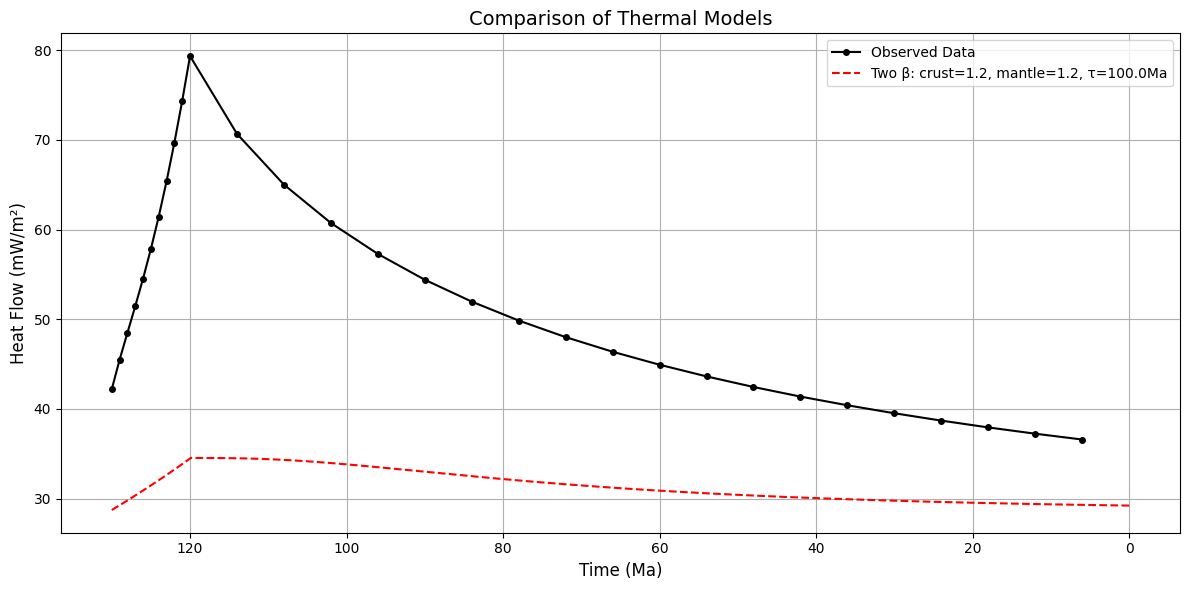

In [ ]:
def compare_models(beta=3, beta_crust=3, beta_mantle=3, tau=10.0):

    # Данные наблюдений
    # beta = 1.2
    # time_data = np.array([130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
    #                       120, 114, 108, 102, 96, 90, 84, 78, 72, 66,
    #                       60, 54, 48, 42, 36, 30, 24, 18, 12, 6])
    # hf_data = np.array([20.28, 21.79, 23.43, 25.20, 27.11, 29.17, 31.39, 33.76, 36.30, 39.01,
    #                     41.89, 41.13, 40.19, 39.17, 38.12, 37.08, 36.06, 35.09, 34.16, 33.28,
    #                     32.45, 31.67, 30.94, 30.26, 29.62, 29.02, 28.45, 27.93, 27.43, 26.97])

    # beta = 3
    time_data = np.array([130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
                      120, 114, 108, 102, 96, 90, 84, 78, 72, 66,
                      60, 54, 48, 42, 36, 30, 24, 18, 12, 6])

    hf_data = np.array([42.2, 45.49, 48.49, 51.46, 54.54, 57.85, 61.45, 65.39, 69.69, 74.36,
                    79.36, 70.68, 65.02, 60.74, 57.29, 54.41, 51.97, 49.86, 48.01, 46.38,
                    44.93, 43.63, 42.45, 41.38, 40.41, 39.52, 38.7, 37.94, 37.24, 36.59])


    
    # Расчет моделей
    # t1, hf1 = single_beta_model(beta=beta, tau=tau, k=1, plot=False)
    t2, hf2 = two_beta_model(beta_crust=beta_crust, beta_mantle=beta_mantle, tau=tau, k_crust=2.7, k_mantle=2.7, plot=False)
    
    # Визуализация
    plt.figure(figsize=(12,6))
    plt.plot(time_data, hf_data, 'ko-', label='Observed Data', markersize=4)
    # plt.plot(t1[::-1], hf1, 'b-', label=f'Single β={beta}, τ={tau}Ma')
    plt.plot(t2[::-1], hf2, 'r--', label=f'Two β: crust={beta_crust}, mantle={beta_mantle}, τ={tau}Ma')

    # plt.ylim(25, 85)
    
    plt.gca().invert_xaxis()
    plt.xlabel('Time (Ma)', fontsize=12)
    plt.ylabel('Heat Flow (mW/m²)', fontsize=12)
    plt.title('Comparison of Thermal Models', fontsize=14)
    plt.grid(True)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# Пример использования с параметрами по умолчанию
compare_models()

# Или с другими параметрами:
# compare_models(beta=2.5, beta_crust=2.0, beta_mantle=3.0, tau=10)

In [ ]:
class Student:
    def __init__(self, name):
        self.name = name
        self.grade = []
    
    def add_grade(self, grade):
        self.grade.append(grade)
        print(f'Оценка {grade} добавлена к {self.name}')

    def get_average(self):
        if not self.grade:
            return None
        else:
            return np.mean(self.grade)

              
student = Student("Анна")
student.add_grade(5)
student.add_grade(4)
student.add_grade(5)
print(f"Средний балл: {student.get_average():.2f}")  # 4.67




Оценка 5 добавлена к Анна
Оценка 4 добавлена к Анна
Оценка 5 добавлена к Анна


ValueError: Unknown format code 'f' for object of type 'str'

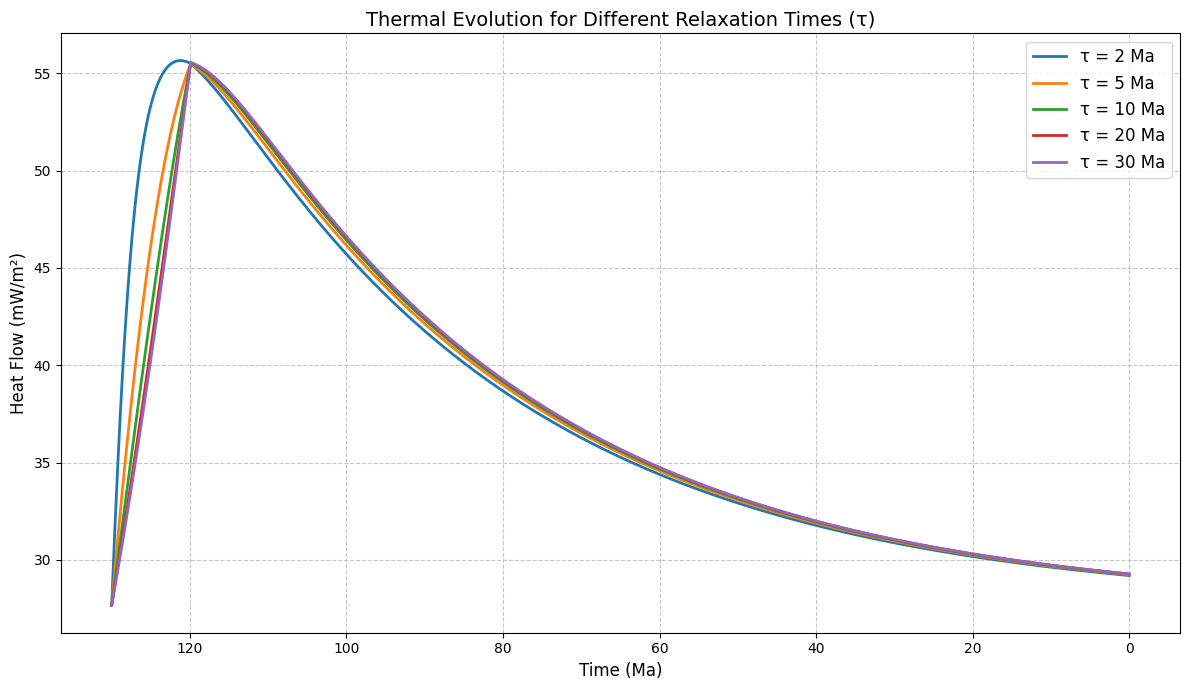

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def calculate_heat_flow_multiple_tau(tau_values=[2, 5, 10, 20, 30]):
    """
    Рассчитывает и визуализирует тепловой поток для разных значений tau.
    
    Параметры:
        tau_values - список значений параметра tau (в Ma)
    """
    plt.figure(figsize=(12, 7))
    
    for tau in tau_values:
        time, heat_flow = single_beta_model(beta=2.0, tau=tau, k=2.6, 
                                          a_crust=30.0, plot=False)
        plt.plot(time[::-1], heat_flow, label=f'τ = {tau} Ma', linewidth=2)
    
    plt.gca().invert_xaxis()
    plt.xlabel('Time (Ma)', fontsize=12)
    plt.ylabel('Heat Flow (mW/m²)', fontsize=12)
    plt.title('Thermal Evolution for Different Relaxation Times (τ)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# Вызов функции с заданными параметрами
calculate_heat_flow_multiple_tau(tau_values=[2, 5, 10, 20, 30])

In [7]:
# # beta = 3
# time_data = np.array([130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
#                   120, 114, 108, 102, 96, 90, 84, 78, 72, 66,
#                   60, 54, 48, 42, 36, 30, 24, 18, 12, 6])

# hf_data = np.array([42.2, 45.49, 48.49, 51.46, 54.54, 57.85, 61.45, 65.39, 69.69, 74.36,
#                 79.36, 70.68, 65.02, 60.74, 57.29, 54.41, 51.97, 49.86, 48.01, 46.38,
#                 44.93, 43.63, 42.45, 41.38, 40.41, 39.52, 38.7, 37.94, 37.24, 36.59])


time_data = np.array([
    130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
    120, 119, 118, 117, 116, 115, 114, 113, 112, 111,
    110, 109, 108, 107, 106, 105, 104, 103, 102, 101,
    100, 99, 98, 97, 96, 95, 94, 93, 92, 91,
    90, 89, 88, 87, 86, 85, 84, 83, 82, 81,
    80, 79, 78, 77, 76, 75, 74, 73, 72, 71,
    70, 69, 68, 67, 66, 65, 64, 63, 62, 61,
    60, 59, 58, 57, 56, 55, 54, 53, 52, 51,
    50, 49, 48, 47, 46, 45, 44, 43, 42, 41,
    40, 39, 38, 37, 36, 35, 34, 33, 32, 31,
    30, 29, 28, 27, 26, 25, 24, 23, 22, 21
])

hf_data = np.array([
    21.25, 21.65, 22.07, 22.51, 22.96, 23.42, 23.90, 24.39, 24.89, 25.39,
    25.92, 25.95, 25.97, 25.99, 26.00, 26.01, 26.01, 26.02, 26.02, 26.01,
    26.01, 26.01, 26.00, 26.00, 25.99, 25.98, 25.97, 25.96, 25.96, 25.95,
    25.94, 25.93, 25.91, 25.90, 25.89, 25.88, 25.86, 25.85, 25.84, 25.82,
    25.81, 25.79, 25.78, 25.76, 25.74, 25.73, 25.71, 25.69, 25.67, 25.66,
    25.64, 25.62, 25.60, 25.58, 25.56, 25.53, 25.51, 25.49, 25.47, 25.45,
    25.43, 25.40, 25.38, 25.36, 25.33, 25.31, 25.28, 25.26, 25.24, 25.21,
    25.19, 25.16, 25.14, 25.11, 25.09, 25.06, 25.03, 25.01, 24.98, 24.96,
    24.93, 24.91, 24.88, 24.85, 24.83, 24.80, 24.78, 24.75, 24.72, 24.70,
    24.67, 24.64, 24.62, 24.59, 24.57, 24.54, 24.52, 24.49, 24.46, 24.44,
    24.41, 24.39, 24.36, 24.34, 24.31, 24.29, 24.26, 24.24, 24.21, 24.19
])



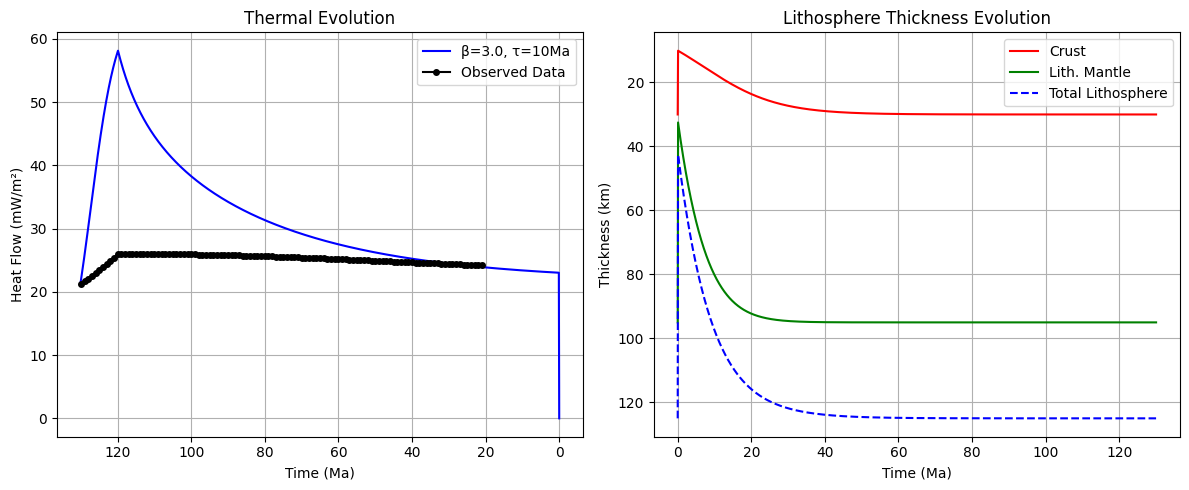

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def sikiguchi_conductivity(T, k0=2.6, a=0.003, b=0.0005):
    """Температурозависимая теплопроводность по модели Сикигучи"""
    return k0 / (1 + a*T + b*T**2)

def single_beta_model(beta=3.0, tau=20.0, k0=2.0, a_crust_init=30.0, plot=False):
    """Модель с одним коэффициентом растяжения с учетом:
    - температурозависимой теплопроводности
    - динамической мощности литосферы
    
    Параметры:
        beta - коэффициент растяжения
        tau - временной параметр экспоненциального затухания (Ma)
        k0 - теплопроводность при 0°C (W/m/°C)
        a_crust_init - начальная толщина коры (km)
        plot - отображать график (True/False)
        
    Возвращает:
        time, heat_flow - массивы времени и теплового потока
    """
    # Основные параметры
    T1 = 1330          # Температура астеносферы (°C)
    a_lith_init = 125  # Начальная толщина литосферы (km)
    kappa = 1.234e-6   # Температуропроводность (m²/s)
    rho = 3300         # Плотность (kg/m³)
    Cp = 1000          # Теплоемкость (J/kg/°C)
    
    # Временные параметры
    t_total = 130      # Общее время моделирования (Ma)
    dt = 0.1           # Шаг по времени (Ma)
    nt = int(t_total/dt) + 1
    time = np.linspace(0, t_total, nt)
    
    # Инициализация массивов
    a_crust = np.zeros(nt)  # Динамическая толщина коры
    a_lith = np.zeros(nt)   # Динамическая толщина литосферы
    a_total = np.zeros(nt)  # Общая толщина
    
    # Пространственная сетка (будет пересчитываться)
    nz = 200
    z = np.zeros((nz, nt))
    T = np.zeros((nz, nt))
    k = np.zeros((nz, nt))  # Теплопроводность
    
    # Начальные условия
    a_crust[0] = a_crust_init
    a_lith[0] = a_lith_init - a_crust_init
    a_total[0] = a_lith_init
    
    dz = a_total[0]/(nz-1)
    z[:,0] = np.linspace(0, a_total[0], nz)
    T[:,0] = T1 * (1 - z[:,0]/a_total[0])
    k[:,0] = sikiguchi_conductivity(T[:,0], k0)
    
    # Профили скорости деформации
    delta_t = 10  # Длительность рифтинга (Ma)
    G0 = np.log(beta)/(tau*(1 - np.exp(-delta_t/tau)))
    G = np.zeros(nt)
    G[time <= delta_t] = G0 * np.exp(-time[time <= delta_t]/tau)
    
    # Численное решение
    dt_sec = dt * 1e6 * 365.25 * 24 * 3600
    
    for i in range(1, nt):
        # 1. Обновляем геометрию
        beta_eff = 1 + (beta-1)*np.exp(-time[i]/tau)
        a_crust[i] = a_crust_init / beta_eff
        a_lith[i] = (a_lith_init - a_crust_init) * (1 - (1 - 1/beta_eff)*np.exp(-time[i]/tau))
        a_total[i] = a_crust[i] + a_lith[i]
        
        # 2. Пересчет сетки
        dz = a_total[i]/(nz-1)
        dz_m = dz * 1000
        z[:,i] = np.linspace(0, a_total[i], nz)
        lambda_ = kappa * dt_sec / dz_m**2
        r = dt_sec / dz_m
        
        # 3. Температурозависимые параметры
        k[:,i-1] = sikiguchi_conductivity(T[:,i-1], k0)
        
        # 4. Решение уравнения теплопроводности
        ab = np.zeros((3, nz))
        b_vec = np.zeros(nz)
        
        # Граничные условия
        ab[1,0] = 1; b_vec[0] = T1
        ab[1,-1] = 1; b_vec[-1] = 0
        
        G_curr = G[i-1] / (1e6 * 365.25 * 24 * 3600)
        
        for j in range(1, nz-1):
            z_pos = (a_total[i] - z[j,i]) * 1000
            k_avg = 0.5*(k[j,i-1] + k[j-1,i-1])  # Интерполяция теплопроводности
            
            ab[0,j+1] = -lambda_ + (r/2)*G_curr*z_pos
            ab[1,j] = 2*(1 + lambda_)
            ab[2,j-1] = -lambda_ - (r/2)*G_curr*z_pos
            
            b_vec[j] = (lambda_ + (r/2)*G_curr*z_pos)*T[j-1,i-1] + \
                       2*(1-lambda_)*T[j,i-1] + \
                       (lambda_ - (r/2)*G_curr*z_pos)*T[j+1,i-1]
        
        T[:,i] = solve_banded((1, 1), ab, b_vec)
    
    # Расчет теплового потока с учетом температурозависимой k
    heat_flow = np.zeros(nt)
    for i in range(nt):
        k_surface = 0.5*(3*k[-1,i] - k[-2,i])  # Экстраполяция на поверхность
        heat_flow[i] = k_surface * (-3*T[-1,i] + 4*T[-2,i] - T[-3,i])/(2*dz_m) * 1e3
    
    if plot:
        plt.figure(figsize=(12, 5))
        
        # График теплового потока
        plt.subplot(121)
        plt.plot(time[::-1], heat_flow, 'b-', label=f'β={beta}, τ={tau}Ma')
        plt.plot(time_data, hf_data, 'ko-', label='Observed Data', markersize=4)
        # plt.ylim(25, 80)
        plt.gca().invert_xaxis()
        plt.xlabel('Time (Ma)')
        plt.ylabel('Heat Flow (mW/m²)')
        plt.title('Thermal Evolution')
        plt.grid()
        plt.legend()
        
        # График изменения толщины
        plt.subplot(122)
        plt.plot(time, a_crust, 'r-', label='Crust')
        plt.plot(time, a_lith, 'g-', label='Lith. Mantle')
        plt.plot(time, a_total, 'b--', label='Total Lithosphere')
        plt.xlabel('Time (Ma)')
        plt.ylabel('Thickness (km)')
        plt.title('Lithosphere Thickness Evolution')
        plt.gca().invert_yaxis()
        plt.grid()
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    return time, heat_flow, a_crust, a_lith

# Пример использования
time, hf, crust_th, lith_th = single_beta_model(beta=3.0, tau=10, plot=True)

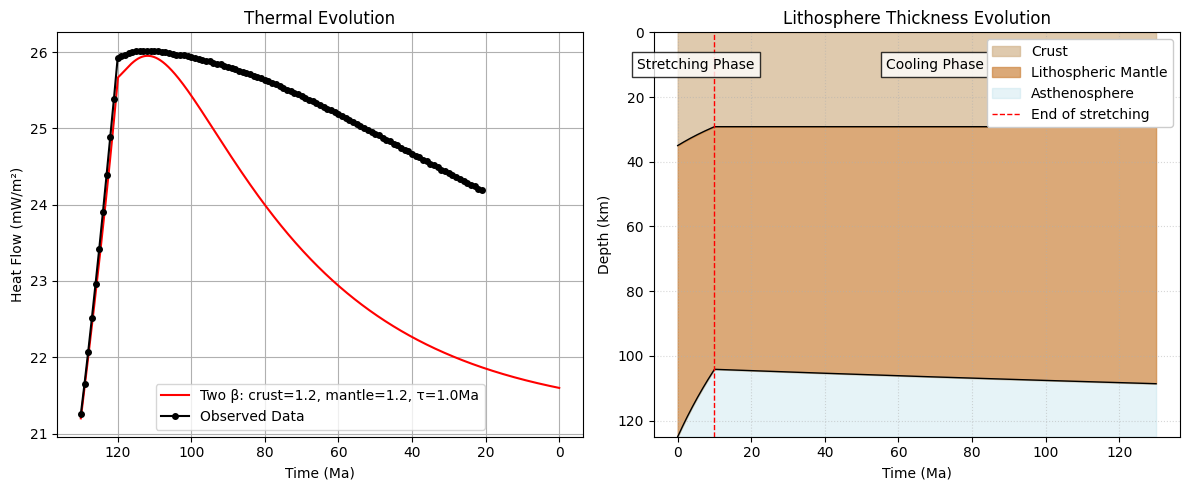

In [12]:
def two_beta_model(beta_crust=1.2, beta_mantle=1.2, tau=5.0, 
                  k0_crust=1.97, k0_mantle=1.97, a_crust=35.0, plot=False):
    """Модель с разными коэффициентами растяжения для коры и мантии.
    
    Параметры:
        beta_crust - коэффициент растяжения коры
        beta_mantle - коэффициент растяжения мантии
        tau - временной параметр для коры (Ma)
        k0_crust, k0_mantle - теплопроводности при 0°C (W/m/°C)
        a_crust - начальная толщина коры (km)
        plot - отображать график (True/False)
        
    Возвращает:
        time, heat_flow, crust_th, mantle_th - массивы времени, теплового потока и толщин
    """
    # Основные параметры
    T1 = 1330; a = 125; kappa = 1.234e-6
    initial_mantle_th = a - a_crust  # Начальная толщина мантийной части литосферы
    cooling_tau = 500.0  # Временной параметр для охлаждения (Ma)
    
    # Временные параметры
    t_total = 130; dt = 0.1
    nt = int(t_total/dt) + 1
    time = np.linspace(0, t_total, nt)
    
    # Инициализация массивов толщин
    crust_th = np.zeros(nt)
    mantle_th = np.zeros(nt)
    crust_th[0] = a_crust
    mantle_th[0] = initial_mantle_th
    
    # Пространственные параметры
    nz = 300; dz = a/(nz-1)
    z = np.linspace(0, a, nz)
    crust_idx = int(a_crust/dz)
    
    # Инициализация температуры и теплопроводности
    T = np.zeros((nz, nt))
    k = np.zeros((nz, nt))
    T[:,0] = T1 * (1 - z/a)
    k[:,0] = np.where(z <= a_crust, 
                     sikiguchi_conductivity(T[:,0], k0_crust),
                     sikiguchi_conductivity(T[:,0], k0_mantle))
    
    # Профили скорости деформации
    delta_t = 10  # Длительность рифтинга
    
    # Кора: экспоненциально убывающая
    G0_crust = np.log(beta_crust)/(tau*(1 - np.exp(-delta_t/tau)))
    G_crust = np.zeros(nt)
    G_crust[time <= delta_t] = G0_crust * np.exp(-time[time <= delta_t]/tau)
    
    # Мантия: постоянная скорость
    G_mantle = np.zeros(nt)
    G_mantle[time <= delta_t] = np.log(beta_mantle)/delta_t
    
    # Численное решение
    dt_sec = dt * 1e6 * 365.25 * 24 * 3600
    dz_m = dz * 1000
    lambda_ = kappa * dt_sec / dz_m**2
    r = dt_sec / dz_m
    
    for i in range(1, nt):
        # 1. Обновляем толщины
        if time[i] <= delta_t:
            # Фаза растяжения - линейное изменение
            beta_eff_crust = 1 + (beta_crust-1)*(time[i]/delta_t)
            beta_eff_mantle = 1 + (beta_mantle-1)*(time[i]/delta_t)
            
            crust_th[i] = a_crust / beta_eff_crust
            mantle_th[i] = initial_mantle_th / beta_eff_mantle
        else:
            # Фаза охлаждения - экспоненциальное восстановление
            stretched_crust = a_crust / beta_crust
            final_mantle = initial_mantle_th + a_crust - stretched_crust
            
            # Начальные значения при начале охлаждения
            start_mantle = initial_mantle_th / beta_mantle
            
            # Время с начала охлаждения
            cooling_time = time[i] - delta_t
            
            # Экспоненциальное приближение к конечной толщине
            crust_th[i] = stretched_crust  # Кора не меняется
            mantle_th[i] = final_mantle + (start_mantle - final_mantle)*np.exp(-cooling_time/cooling_tau)
        
        # 2. Решаем уравнение теплопроводности
        ab = np.zeros((3, nz))
        b_vec = np.zeros(nz)
        
        ab[1,0] = 1; b_vec[0] = T1  # Граничные условия
        ab[1,-1] = 1; b_vec[-1] = 0
        
        for j in range(1, nz-1):
            if z[j] <= a_crust:
                G_curr = G_crust[i-1] / (1e6 * 365.25 * 24 * 3600)
                k_avg = 0.5*(k[j,i-1] + k[j-1,i-1])
            else:
                G_curr = G_mantle[i-1] / (1e6 * 365.25 * 24 * 3600)
                k_avg = 0.5*(k[j,i-1] + k[j-1,i-1])
            
            z_pos = (a - z[j]) * 1000
            ab[0,j+1] = -lambda_ + (r/2)*G_curr*z_pos
            ab[1,j] = 2*(1 + lambda_)
            ab[2,j-1] = -lambda_ - (r/2)*G_curr*z_pos
            
            b_vec[j] = (lambda_ + (r/2)*G_curr*z_pos)*T[j-1,i-1] + \
                       2*(1-lambda_)*T[j,i-1] + \
                       (lambda_ - (r/2)*G_curr*z_pos)*T[j+1,i-1]
        
        T[:,i] = solve_banded((1, 1), ab, b_vec)
        
        # 3. Обновляем теплопроводность
        k[:,i] = np.where(z <= a_crust,
                         sikiguchi_conductivity(T[:,i], k0_crust),
                         sikiguchi_conductivity(T[:,i], k0_mantle))
        
        # 4. Условие на границе коры и мантии
        T[crust_idx,i] = (k0_crust*T[crust_idx-1,i] + k0_mantle*T[crust_idx+1,i])/(k0_crust + k0_mantle)
    
    # Расчет теплового потока с учетом температурозависимой k
    heat_flow = np.zeros(nt)
    for i in range(nt):
        k_surface = 0.5*(3*k[-1,i] - k[-2,i])  # Экстраполяция на поверхность
        heat_flow[i] = k_surface * (-3*T[-1,i] + 4*T[-2,i] - T[-3,i])/(2*dz_m) * 1e3
    
    if plot:
        plt.figure(figsize=(12, 5))
        
        # График теплового потока
        plt.subplot(121)
        plt.plot(time[::-1], heat_flow, 'r-', 
                label=f'Two β: crust={beta_crust}, mantle={beta_mantle}, τ={tau}Ma')
        plt.plot(time_data, hf_data, 'ko-', label='Observed Data', markersize=4)
        plt.gca().invert_xaxis()
        plt.xlabel('Time (Ma)')
        plt.ylabel('Heat Flow (mW/m²)')
        plt.title('Thermal Evolution')
        plt.grid()
        plt.legend()
        
        # 2. NEW: Thickness Evolution Plot matching Figure 3.26 style
        plt.subplot(122)
        
        # Create filled areas
        plt.fill_between(time, 0, crust_th, color='tan', alpha=0.7, label='Crust')
        plt.fill_between(time, crust_th, crust_th+mantle_th, color='peru', alpha=0.7, label='Lithospheric Mantle')
        plt.fill_between(time, crust_th+mantle_th, 125, color='lightblue', alpha=0.3, label='Asthenosphere')
        
        # Add phase boundary lines
        plt.plot(time, crust_th, 'k-', linewidth=1)
        plt.plot(time, crust_th + mantle_th, 'k-', linewidth=1)
        
        # Add stretching phase marker
        plt.axvline(delta_t, color='r', linestyle='--', linewidth=1, label='End of stretching')
        
        # Add text annotations
        plt.text(0.5*delta_t, 10, 'Stretching Phase', ha='center', va='center', 
                bbox=dict(facecolor='white', alpha=0.8))
        plt.text(delta_t + 0.5*(t_total-delta_t), 10, 'Cooling Phase', ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.8))
        
        # Formatting
        plt.xlabel('Time (Ma)')
        plt.ylabel('Depth (km)')
        plt.title('Lithosphere Thickness Evolution')
        plt.ylim(0, 125)
        plt.gca().invert_yaxis()  # Depth increases downward
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.legend(loc='upper right', framealpha=1)
        
        plt.tight_layout()
        plt.show()
    
    return time, heat_flow, crust_th, mantle_th

# Пример использования
time, hf, crust_th, mantle_th = two_beta_model(beta_crust=1.2, beta_mantle=1.2, tau=1.0, plot=True)

In [2]:
print(a)

NameError: name 'a' is not defined

## Thermal Conductivity Models

### 1. Constant Model
$$
\lambda(T) = \lambda_{20}
$$

### 2. Linear Temperature-Dependent Model
$$
\lambda(T) = \lambda_{20} + \lambda_T \cdot (T - 20^\circ \text{C})
$$
where $\lambda_T = -0.001$ W/m/K/$^\circ$C is the temperature coefficient.

### 3. Sekiguchi-Waples Model (Normalized)
$$
\lambda(T) = \left[\frac{358 \cdot (1.0227\lambda_{20} - 1.882)}{T_K + 1.84 - 0.00068}\right] \cdot \left(\frac{\lambda_{20}}{\lambda_{ref}}\right)
$$
where:
- $T_K = T[^\circ \text{C}] + 273.15$ (temperature in Kelvin)
- $\lambda_{ref}$ is the unnormalized conductivity at 20$^\circ$C:
$$
\lambda_{ref} = \frac{358 \cdot (1.0227\lambda_{20} - 1.882)}{293.15 + 1.84 - 0.00068}
$$

## Lithosphere Thickness Evolution

### During Stretching Phase ($t \leq \Delta t$)
$$
\begin{aligned}
h_{\text{crust}}(t) &= \frac{h_{\text{crust}}^0}{\beta_{\text{eff}}^{\text{crust}}(t)} \\
h_{\text{mantle}}(t) &= \frac{h_{\text{mantle}}^0}{\beta_{\text{eff}}^{\text{mantle}}(t)} \\
\beta_{\text{eff}}^{\text{crust}}(t) &= 1 + (\beta_{\text{crust}} - 1)\frac{t}{\Delta t} \\
\beta_{\text{eff}}^{\text{mantle}}(t) &= 1 + (\beta_{\text{mantle}} - 1)\frac{t}{\Delta t}
\end{aligned}
$$

### Post-Stretching Phase ($t > \Delta t$)
$$
\begin{aligned}
h_{\text{crust}}(t) &= \frac{h_{\text{crust}}^0}{\beta_{\text{crust}}} \\
h_{\text{mantle}}(t) &= h_{\text{final}} + \left(\frac{h_{\text{mantle}}^0}{\beta_{\text{mantle}}} - h_{\text{final}}\right) \exp\left(-\frac{t - \Delta t}{\tau_{\text{cooling}}}\right) \\
h_{\text{final}} &= h_{\text{mantle}}^0 + h_{\text{crust}}^0 - \frac{h_{\text{crust}}^0}{\beta_{\text{crust}}}
\end{aligned}
$$

## Strain Rate Profiles

### Crustal Strain Rate
$$
G_{\text{crust}}(t) = 
\begin{cases}
G_0^{\text{crust}} \exp\left(-\frac{t}{\tau}\right) & t \leq \Delta t \\
0 & t > \Delta t
\end{cases}
$$
where:
$$
G_0^{\text{crust}} = \frac{\ln(\beta_{\text{crust}})}{\tau\left(1 - \exp\left(-\frac{\Delta t}{\tau}\right)\right)}
$$

### Mantle Strain Rate
$$
G_{\text{mantle}}(t) = 
\begin{cases}
\frac{\ln(\beta_{\text{mantle}})}{\Delta t} & t \leq \Delta t \\
0 & t > \Delta t
\end{cases}
$$

## Heat Flow Calculation
$$
q(t) = k_{\text{surface}} \cdot \left(\frac{-3T_{-1} + 4T_{-2} - T_{-3}}{2\Delta z}\right) \times 10^3
$$
where $k_{\text{surface}}$ is the surface thermal conductivity.

In [21]:
def two_beta_model_v2(beta_crust=1.2, beta_mantle=1.2, tau=5.0, 
                     k0_crust=2.6, k0_mantle=2.6, a_crust=30.0, tc_model='linear', plot=False):
    """
    Enhanced two-layer stretching model with comparison to simple model.
    Now includes thermal conductivity evolution plots.
    """
    # Constants
    T1 = 1330; a = 125; kappa = 1.234e-6
    initial_mantle_th = a - a_crust
    cooling_tau = 50.0
    
    # Time parameters
    t_total = 130; dt = 0.1
    nt = int(t_total/dt) + 1
    time = np.linspace(0, t_total, nt)
    
    # Initialize arrays for both models
    crust_th = np.zeros(nt)
    mantle_th = np.zeros(nt)
    crust_th[0] = a_crust
    mantle_th[0] = initial_mantle_th
    
    # Spatial parameters
    nz = 300; dz = a/(nz-1)
    z = np.linspace(0, a, nz)
    
    # Main model arrays
    T = np.zeros((nz, nt))
    k = np.zeros((nz, nt))
    
    # Simple model arrays (constant thickness, constant conductivity)
    T_simple = np.zeros((nz, nt))
    k_simple = np.zeros((nz, nt))
    
    # Initial conditions
    initial_temp = T1 * (1 - z/a)
    T[:,0] = initial_temp.copy()
    T_simple[:,0] = initial_temp.copy()
    
    # Conductivity - simple model uses constant values
    k_simple[:,0] = np.where(z <= a_crust, k0_crust, k0_mantle)
    # Upgraded model uses temperature-dependent values
    k[:,0] = np.where(z <= a_crust, 
                      thermal_conductivity(T[:,0], k0_crust, model='sekiguchi'),
                      thermal_conductivity(T[:,0], k0_mantle, model='sekiguchi'))
    
    # Strain rate profiles (same for both models)
    delta_t = 10
    G0_crust = np.log(beta_crust)/(tau*(1 - np.exp(-delta_t/tau)))
    G_crust = np.zeros(nt)
    G_crust[time <= delta_t] = G0_crust * np.exp(-time[time <= delta_t]/tau)
    G_mantle = np.zeros(nt)
    G_mantle[time <= delta_t] = np.log(beta_mantle)/delta_t
    
    # Numerical parameters
    dt_sec = dt * 1e6 * 365.25 * 24 * 3600
    dz_m = dz * 1000
    lambda_ = kappa * dt_sec / dz_m**2
    r = dt_sec / dz_m


    
    for i in range(1, nt):
        # Update thicknesses (only for main model)
        if time[i] <= delta_t:
            beta_eff_crust = 1 + (beta_crust-1)*(time[i]/delta_t)
            beta_eff_mantle = 1 + (beta_mantle-1)*(time[i]/delta_t)
            crust_th[i] = a_crust / beta_eff_crust
            mantle_th[i] = initial_mantle_th / beta_eff_mantle
            
        else:
            stretched_crust = a_crust / beta_crust
            final_mantle = initial_mantle_th + a_crust - stretched_crust
            cooling_time = time[i] - delta_t
            crust_th[i] = stretched_crust
            mantle_th[i] = initial_mantle_th / beta_eff_mantle
            # mantle_th[i] = final_mantle + ((initial_mantle_th/beta_mantle - final_mantle)*np.exp(-cooling_time/cooling_tau))
        
        # Current crust index for main model
        current_crust_idx = np.argmin(np.abs(z - crust_th[i]))
        
        # Solve both models
        for model in ['upgraded', 'simple']:
            if model == 'upgraded':
                T_curr = T
                k_curr = k
                crust_idx = current_crust_idx
            else:
                T_curr = T_simple
                k_curr = k_simple
                crust_idx = int(a_crust/dz)  # Fixed crust index
            
            ab = np.zeros((3, nz))
            b_vec = np.zeros(nz)
            
            ab[1,0] = 1; b_vec[0] = T1  # Boundary conditions
            ab[1,-1] = 1; b_vec[-1] = 0
            
            for j in range(1, nz-1):
                if model == 'upgraded':
                    in_crust = z[j] <= crust_th[i]
                else:
                    in_crust = z[j] <= a_crust
                
                G_curr = (G_crust[i-1] if in_crust else G_mantle[i-1]) / (1e6 * 365.25 * 24 * 3600)
                z_pos = (a - z[j]) * 1000
                
                ab[0,j+1] = -lambda_ + (r/2)*G_curr*z_pos
                ab[1,j] = 2*(1 + lambda_)
                ab[2,j-1] = -lambda_ - (r/2)*G_curr*z_pos
                
                b_vec[j] = (lambda_ + (r/2)*G_curr*z_pos)*T_curr[j-1,i-1] + \
                           2*(1-lambda_)*T_curr[j,i-1] + \
                           (lambda_ - (r/2)*G_curr*z_pos)*T_curr[j+1,i-1]
            
            T_curr[:,i] = solve_banded((1, 1), ab, b_vec)
            
            # Update conductivity (only for upgraded model)
            if model == 'upgraded':
                k[:,i] = np.where(z <= crust_th[i],
                                thermal_conductivity(T[:,i], k0_crust, model='sekiguchi'),
                                thermal_conductivity(T[:,i], k0_mantle, model='sekiguchi'))
            
            # Boundary condition at crust-mantle interface
            if 0 < crust_idx < nz-1:
                if model == 'upgraded':
                    k1, k2 = k[crust_idx,i], k[crust_idx+1,i]
                else:
                    k1, k2 = k0_crust, k0_mantle
                
                T_curr[crust_idx,i] = (k1*T_curr[crust_idx-1,i] + k2*T_curr[crust_idx+1,i])/(k1 + k2)
    
    # Calculate heat flow for both models
    heat_flow = np.zeros(nt)  # Upgraded model
    heat_flow_simple = np.zeros(nt)  # Simple model
    
    for i in range(nt):
        # Upgraded model
        k_surface = 0.5*(3*k[-1,i] - k[-2,i])
        heat_flow[i] = k_surface * (-3*T[-1,i] + 4*T[-2,i] - T[-3,i])/(2*dz_m) * 1e3
        
        # Simple model
        if z[-1] <= a_crust:
            k_surf_simple = k0_crust
        else:
            k_surf_simple = k0_mantle
        heat_flow_simple[i] = k_surf_simple * (-3*T_simple[-1,i] + 4*T_simple[-2,i] - T_simple[-3,i])/(2*dz_m) * 1e3
    
    if plot:
        plt.figure(figsize=(15, 10))
        
        # 1. Heat Flow Comparison Plot
        plt.subplot(221)
        plt.plot(time[::-1], heat_flow, 'r-', label='Upgraded model')
        plt.plot(time[::-1], heat_flow_simple, 'b--', label='Simple model')
        plt.plot(time_data, hf_data, 'ko-', label='Observed Data', markersize=4)
        plt.gca().invert_xaxis()
        plt.xlabel('Time (Ma)')
        plt.ylabel('Heat Flow (mW/m²)')
        plt.title('Heat Flow Comparison')
        plt.grid()
        plt.legend()
        
        # 2. Thickness Evolution
        plt.subplot(222)
        plt.fill_between(time, 0, crust_th, color='tan', alpha=0.7, label='Crust')
        plt.fill_between(time, crust_th, crust_th+mantle_th, color='peru', alpha=0.7, label='Lithospheric Mantle')
        plt.fill_between(time, crust_th+mantle_th, 125, color='lightblue', alpha=0.3, label='Asthenosphere')
        plt.plot(time, crust_th, 'k-', linewidth=1)
        plt.plot(time, crust_th + mantle_th, 'k-', linewidth=1)
        plt.axvline(delta_t, color='r', linestyle='--', label='End stretching')
        plt.xlabel('Time (Ma)')
        plt.ylabel('Depth (km)')
        plt.title('Lithosphere Thickness')
        plt.ylim(0, 125)
        plt.gca().invert_yaxis()
        plt.legend()
        
        # 3. Temperature Evolution Plot
        plt.subplot(223)
        plot_times = [0, delta_t/2, delta_t, delta_t+10, delta_t+50, -1]
        colors = plt.cm.viridis(np.linspace(0, 1, len(plot_times)))
        
        for t_idx, color in zip([int(t/dt) for t in plot_times], colors):
            plt.plot(T[:,t_idx], z, color=color, label=f'{time[t_idx]:.1f} Ma')
        
        plt.xlabel('Temperature (°C)')
        plt.ylabel('Depth (km)')
        plt.title('Temperature Profiles')
        plt.ylim(0, a)
        plt.grid(True, alpha=0.3)
        plt.legend(title='Time:')
        
        # 4. Thermal Conductivity Evolution
        plt.subplot(224)
        # Plot conductivity vs temperature at different times
        for t_idx, color in zip([int(t/dt) for t in plot_times], colors):
            plt.plot(T[:,t_idx], k[:,t_idx], color=color, label=f'{time[t_idx]:.1f} Ma')
        
        plt.xlabel('Thermal Conductivity (W/m/K)')
        plt.ylabel('Temperature (°C)')
        plt.title('Thermal Conductivity vs Temperature')
        plt.grid(True, alpha=0.3)
        plt.legend(title='Time:')
        
        plt.tight_layout()
        plt.show()
    
    return time, heat_flow, heat_flow_simple, crust_th, mantle_th, T, T_simple, k



In [22]:


import matplotlib.pyplot as plt

# # Data (x = first column, y = second column)
# x = [
#     130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
#     120, 119, 118, 117, 116, 115, 114, 113, 112, 111,
#     110, 109, 108, 107, 106, 105, 104, 103, 102, 101,
#     100, 99, 98, 97, 96, 95, 94, 93, 92, 91,
#     90, 89, 88, 87, 86, 85, 84, 83, 82, 81,
#     80, 79, 78, 77, 76, 75, 74, 73, 72, 71,
#     70, 69, 68, 67, 66, 65, 64, 63, 62, 61,
#     60, 59, 58, 57, 56, 55, 54, 53, 52, 51,
#     50, 49, 48, 47, 46, 45, 44, 43, 42, 41,
#     40, 39, 38, 37, 36, 35, 34, 33, 32, 31,
#     30, 29, 28, 27, 26, 25, 24, 23, 22, 21
# ]

# y = [
#     21.4, 24.05, 27.06, 30.49, 34.36, 38.7, 43.55, 48.95, 54.73, 60.96,
#     67.6, 67.14, 66.54, 65.82, 65.06, 64.3, 63.56, 62.83, 62.11, 61.41,
#     60.73, 60.07, 59.42, 58.79, 58.18, 57.58, 56.99, 56.42, 55.86, 55.32,
#     54.79, 54.27, 53.77, 53.28, 52.8, 52.33, 51.87, 51.42, 50.99, 50.56,
#     50.14, 49.73, 49.34, 48.95, 48.56, 48.19, 47.83, 47.47, 47.12, 46.77,
#     46.44, 46.11, 45.79, 45.47, 45.16, 44.86, 44.56, 44.27, 43.98, 43.7,
#     43.42, 43.15, 42.88, 42.62, 42.36, 42.11, 41.86, 41.62, 41.38, 41.14,
#     40.91, 40.68, 40.45, 40.23, 40.01, 39.8, 39.59, 39.38, 39.18, 38.98,
#     38.78, 38.58, 38.39, 38.2, 38.01, 37.83, 37.65, 37.47, 37.29, 37.12,
#     36.95, 36.78, 36.61, 36.44, 36.28, 36.12, 35.96, 35.81, 35.65, 35.5,
#     35.35, 35.2, 35.06, 34.91, 34.77, 34.63, 34.49, 34.35, 34.21, 34.08
# ]



x = np.array([130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
                      120, 114, 108, 102, 96, 90, 84, 78, 72, 66,
                      60, 54, 48, 42, 36, 30, 24, 18, 12, 6])
y = np.array([20.28, 21.79, 23.43, 25.20, 27.11, 29.17, 31.39, 33.76, 36.30, 39.01,
                    41.89, 41.13, 40.19, 39.17, 38.12, 37.08, 36.06, 35.09, 34.16, 33.28,
                    32.45, 31.67, 30.94, 30.26, 29.62, 29.02, 28.45, 27.93, 27.43, 26.97])

In [23]:
def thermal_conductivity(T, lambda_20, model='sekiguchi', direction='v'):
    """
    Calculate temperature-dependent thermal conductivity with multiple model options.
    
    Parameters:
    T : temperature in °C (can be array)
    lambda_20 : thermal conductivity at 20°C in W/m/K
    model : 'sekiguchi' (default), 'linear', or 'constant'
    direction : 'v' (vertical) or 'h' (horizontal) - only for Sekiguchi model
    
    Returns:
    Thermal conductivity in W/m/K at temperature T
    """
    if model == 'constant':
        return lambda_20 * np.ones_like(T)
    
    elif model == 'linear':
        lambda_T = -0.001  # Default slope
        return lambda_20 + lambda_T * (T - 20)
    
    elif model == 'sekiguchi':
        T_K = T + 273.15
        # Calculate normalization factor to ensure λ(20°C) = λ₂₀
        T_ref_K = 20 + 273.15
        numerator_ref = 358 * (1.0227 * lambda_20 - 1.882)
        denominator_ref = T_ref_K - 0.00068 + 1.84
        lambda_ref = numerator_ref / denominator_ref
        
        # Apply normalization
        numerator = 358 * (1.0227 * lambda_20 - 1.882)
        denominator = T_K - 0.00068 + 1.84
        return (numerator / denominator) * (lambda_20 / lambda_ref)
    
    else:
        raise ValueError("Invalid model type")

In [24]:
time_data, hf_data = x, y

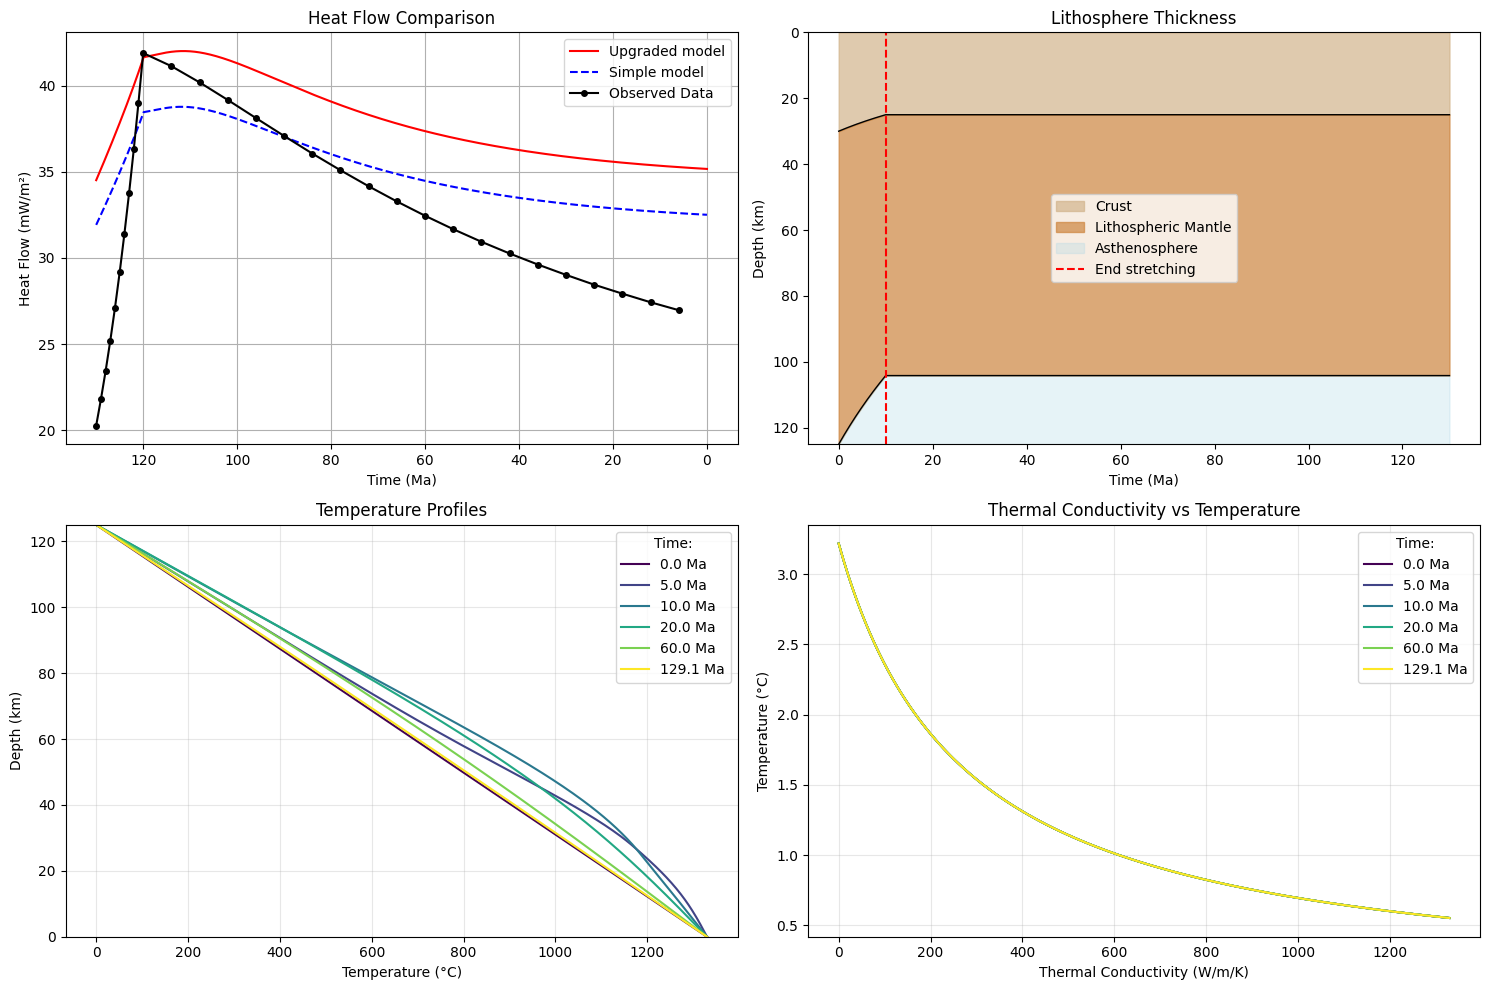

In [25]:
# Example usage
time, hf, hf_simple, crust, mantle, T, T_simple, k = two_beta_model_v2(
    beta_crust=1.2,
    beta_mantle=1.2,
    tau=1.0,
    k0_crust=3, k0_mantle=3, 
    a_crust=30.0, tc_model='linear', 
    plot=True)

# sekiguchi

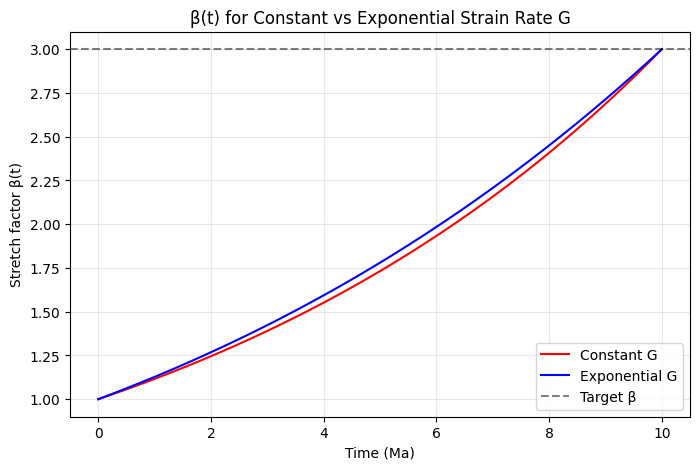

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
beta_target = 3  # desired stretch factor at end of stretching
delta_t = 10.0     # stretching duration (Ma)
tau = 50.0          # decay time constant for exponential G (Ma)
nt = 200           # number of time steps

time = np.linspace(0, delta_t, nt)

# 1. Constant G case
G_const = np.log(beta_target) / delta_t
beta_const = np.exp(G_const * time)

# 2. Exponential G case: G(t) = G0 exp(-t/tau)
# Choose G0 so that beta(delta_t) = beta_target
G0_exp = np.log(beta_target) / (tau * (1 - np.exp(-delta_t / tau)))
G_exp = G0_exp * np.exp(-time / tau)
beta_exp = np.exp(G0_exp * tau * (1 - np.exp(-time / tau)))

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(time, beta_const, 'r-', label='Constant G')
plt.plot(time, beta_exp, 'b-', label='Exponential G')
plt.axhline(beta_target, color='k', linestyle='--', alpha=0.5, label='Target β')
plt.xlabel('Time (Ma)')
plt.ylabel('Stretch factor β(t)')
plt.title('β(t) for Constant vs Exponential Strain Rate G')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def thermal_conductivity(T, k0):
    alpha = 2e-4
    k = k0 * (1 - alpha * (T - 273.15))
    print(k)
    return np.maximum(k, 0.1)

def two_beta_model_combined(beta_crust=3, beta_mantle=3, tau=50.0,
                           k0_crust=2.6, k0_mantle=2.6, a_crust=30.0,
                           cooling_tau_crust=50.0, cooling_tau_mantle=50.0,
                           plot=True):

    # Constants
    T1 = 1330.0
    a = 125.0
    kappa = 1.234e-6
    initial_mantle_th = a - a_crust

    # Time setup
    t_total = 130.0
    dt = 0.1
    nt = int(t_total / dt) + 1
    time = np.linspace(0, t_total, nt)

    # Depth grid
    nz = 300
    dz = a / (nz - 1)
    z = np.linspace(0, a, nz)

    # Stretching parameters
    delta_t = 10.0
    year_sec = 365.25 * 24 * 3600.0
    dt_sec = dt * 1e6 * year_sec

    # Initial G0 for stretching
    G0_crust = np.log(beta_crust) / (tau * (1 - np.exp(-delta_t / tau)))
    G0_mantle = np.log(beta_mantle) / (tau * (1 - np.exp(-delta_t / tau)))
    G_crust = np.zeros(nt)
    G_mantle = np.zeros(nt)
    mask = time <= delta_t
    G_crust[mask] = G0_crust * np.exp(-time[mask] / tau)
    G_mantle[mask] = G0_mantle * np.exp(-time[mask] / tau)

    # Cooling phase rates (1/s)
    G_cool_crust = 1.0 / (cooling_tau_crust * 1e6 * year_sec)
    G_cool_mantle = 1.0 / (cooling_tau_mantle * 1e6 * year_sec)

    # Initialize arrays for beta(t)
    beta_exp_crust = np.ones(nt)
    beta_exp_mantle = np.ones(nt)
    beta_const_crust = np.ones(nt)
    beta_const_mantle = np.ones(nt)

    # Initial thicknesses for both models
    crust_th_exp = np.zeros(nt)
    mantle_th_exp = np.zeros(nt)
    crust_th_const = np.zeros(nt)
    mantle_th_const = np.zeros(nt)

    crust_th_exp[0] = a_crust
    mantle_th_exp[0] = initial_mantle_th
    crust_th_const[0] = a_crust
    mantle_th_const[0] = initial_mantle_th

    for i in range(1, nt):
        # Stretching phase (same for both)
        if time[i] <= delta_t:
            beta_exp_crust[i] = beta_exp_crust[i-1] * np.exp(G_crust[i-1] * dt)
            beta_exp_mantle[i] = beta_exp_mantle[i-1] * np.exp(G_mantle[i-1] * dt)
            beta_const_crust[i] = beta_const_crust[i-1] * np.exp(G_crust[i-1] * dt)
            beta_const_mantle[i] = beta_const_mantle[i-1] * np.exp(G_mantle[i-1] * dt)
        else:
            # Cooling phase - exponential decay back to 1
            beta_exp_crust[i] = 1 + (beta_exp_crust[i-1] - 1) * np.exp(-dt_sec * G_cool_crust)
            beta_exp_mantle[i] = 1 + (beta_exp_mantle[i-1] - 1) * np.exp(-dt_sec * G_cool_mantle)
            # Cooling phase - constant beta after stretching ends
            beta_const_crust[i] = beta_const_crust[int(delta_t / dt)]
            beta_const_mantle[i] = beta_const_mantle[int(delta_t / dt)]

        crust_th_exp[i] = a_crust / beta_exp_crust[i]
        mantle_th_exp[i] = initial_mantle_th / beta_exp_mantle[i]

        crust_th_const[i] = a_crust / beta_const_crust[i]
        mantle_th_const[i] = initial_mantle_th / beta_const_mantle[i]

    if plot:
        plt.figure(figsize=(10,6))
        plt.plot(time, beta_exp_crust, label='β_crust(t) Exp. cooling')
        plt.plot(time, beta_exp_mantle, label='β_mantle(t) Exp. cooling')
        plt.plot(time, beta_const_crust, '--', label='β_crust(t) Constant cooling')
        plt.plot(time, beta_const_mantle, '--', label='β_mantle(t) Constant cooling')
        plt.axvline(delta_t, color='red', linestyle='--', label='End stretching')
        plt.xlabel('Time (Ma)')
        plt.ylabel('β(t)')
        plt.title('Comparison of β(t) Cooling Models')
        plt.legend()
        plt.grid(True)
        plt.show()

    return (time,
            beta_exp_crust, beta_exp_mantle, crust_th_exp, mantle_th_exp,
            beta_const_crust, beta_const_mantle, crust_th_const, mantle_th_const)

# Run the combined model and plot results
two_beta_model_combined()


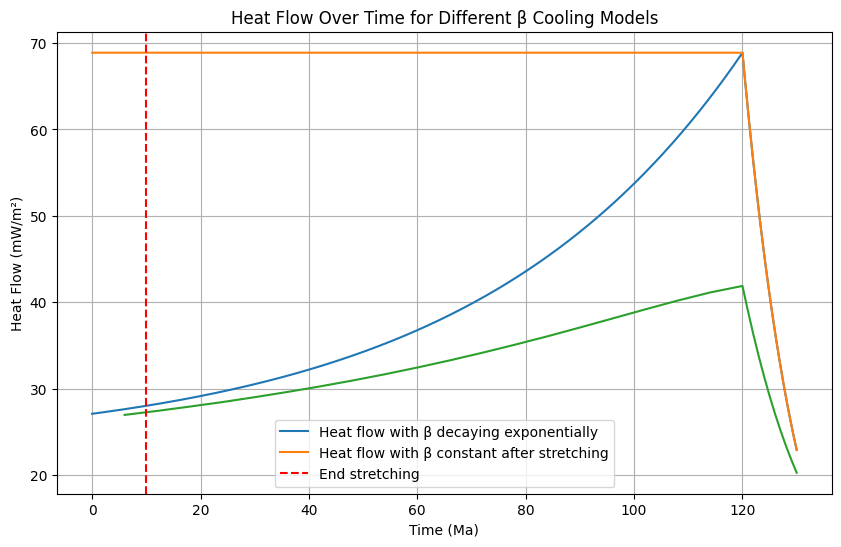

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def thermal_conductivity(T, lambda_20, model='linear'):
    """
    Calculate temperature-dependent thermal conductivity.
    
    Parameters:
    T : temperature in °C (can be array)
    lambda_20 : thermal conductivity at 20°C in W/m/K
    model : 'linear' (default), can extend later
    
    Returns:
    Thermal conductivity in W/m/K at temperature T
    """
    if model == 'linear':
        lambda_T = -0.001  # slope W/m/K per °C
        # return lambda_20 + lambda_T * (T - 20)
        return 2.6
    else:
        # return lambda_20 * np.ones_like(T)
        return  2.6 * np.ones_like(T)

def two_beta_model_combined(beta_crust=3, beta_mantle=3, tau=50.0,
                           k0_crust=10, k0_mantle=4, a_crust=30.0,
                           cooling_tau_crust=50.0, cooling_tau_mantle=50.0,
                           plot=True):

    T1 = 1330.0
    a = 125.0
    initial_mantle_th = a - a_crust

    t_total = 130.0
    dt = 0.1
    nt = int(t_total / dt) + 1
    time = np.linspace(0, t_total, nt)

    delta_t = 10.0
    year_sec = 365.25 * 24 * 3600.0
    dt_sec = dt * 1e6 * year_sec

    G0_crust = np.log(beta_crust) / (tau * (1 - np.exp(-delta_t / tau)))
    G0_mantle = np.log(beta_mantle) / (tau * (1 - np.exp(-delta_t / tau)))
    G_crust = np.zeros(nt)
    G_mantle = np.zeros(nt)
    mask = time <= delta_t
    G_crust[mask] = G0_crust * np.exp(-time[mask] / tau)
    G_mantle[mask] = G0_mantle * np.exp(-time[mask] / tau)

    G_cool_crust = 1.0 / (cooling_tau_crust * 1e6 * year_sec)
    G_cool_mantle = 1.0 / (cooling_tau_mantle * 1e6 * year_sec)

    beta_exp_crust = np.ones(nt)
    beta_exp_mantle = np.ones(nt)
    beta_const_crust = np.ones(nt)
    beta_const_mantle = np.ones(nt)

    crust_th_exp = np.zeros(nt)
    mantle_th_exp = np.zeros(nt)
    crust_th_const = np.zeros(nt)
    mantle_th_const = np.zeros(nt)

    crust_th_exp[0] = a_crust
    mantle_th_exp[0] = initial_mantle_th
    crust_th_const[0] = a_crust
    mantle_th_const[0] = initial_mantle_th

    for i in range(1, nt):
        if time[i] <= delta_t:
            beta_exp_crust[i] = beta_exp_crust[i-1] * np.exp(G_crust[i-1] * dt)
            beta_exp_mantle[i] = beta_exp_mantle[i-1] * np.exp(G_mantle[i-1] * dt)
            beta_const_crust[i] = beta_const_crust[i-1] * np.exp(G_crust[i-1] * dt)
            beta_const_mantle[i] = beta_const_mantle[i-1] * np.exp(G_mantle[i-1] * dt)
        else:
            beta_exp_crust[i] = 1 + (beta_exp_crust[i-1] - 1) * np.exp(-dt_sec * G_cool_crust)
            beta_exp_mantle[i] = 1 + (beta_exp_mantle[i-1] - 1) * np.exp(-dt_sec * G_cool_mantle)
            beta_const_crust[i] = beta_const_crust[int(delta_t / dt)]
            beta_const_mantle[i] = beta_const_mantle[int(delta_t / dt)]

        crust_th_exp[i] = a_crust / beta_exp_crust[i]
        mantle_th_exp[i] = initial_mantle_th / beta_exp_mantle[i]
        crust_th_const[i] = a_crust / beta_const_crust[i]
        mantle_th_const[i] = initial_mantle_th / beta_const_mantle[i]

    if plot:
        plt.figure(figsize=(10,6))
        plt.plot(time, beta_exp_crust, label='β_crust(t) Exp. cooling')
        plt.plot(time, beta_exp_mantle, label='β_mantle(t) Exp. cooling')
        plt.plot(time, beta_const_crust, '--', label='β_crust(t) Constant cooling')
        plt.plot(time, beta_const_mantle, '--', label='β_mantle(t) Constant cooling')
        plt.axvline(delta_t, color='red', linestyle='--', label='End stretching')
        plt.xlabel('Time (Ma)')
        plt.ylabel('β(t)')
        plt.title('Comparison of β(t) Cooling Models')
        plt.legend()
        plt.grid(True)
        plt.show()

    return (time,
            beta_exp_crust, beta_exp_mantle, crust_th_exp, mantle_th_exp,
            beta_const_crust, beta_const_mantle, crust_th_const, mantle_th_const)

def calculate_heat_flow_with_beta(time, beta_crust, beta_mantle, crust_th, mantle_th,
                                 T1=1330.0, a=125.0, k0_crust=1.90, k0_mantle=1.90):
    heat_flow = np.zeros_like(time)
    
    for i in range(len(time)):
        crust_th_i = crust_th[i] * 1000  # convert km to m
        mantle_th_i = mantle_th[i] * 1000
        
        T_surface = 0.0
        T_mantle = T1
        
        # Approximate temperatures in crust and mantle layers for conductivity calc
        # Midpoints of linear gradients:
        T_crust_mid = T_surface + 0.5 * (T_mantle - T_surface) * (crust_th_i / (crust_th_i + mantle_th_i))
        T_mantle_mid = T_crust_mid + 0.5 * (T_mantle - T_crust_mid)
        
        k_crust = thermal_conductivity(T_crust_mid, k0_crust, model='linear')
        k_mantle = thermal_conductivity(T_mantle_mid, k0_mantle, model='linear')
        
        dTdz_crust = (T_crust_mid - T_surface) / crust_th_i
        dTdz_mantle = (T_mantle - T_crust_mid) / mantle_th_i
        
        q_crust = k_crust * dTdz_crust
        q_mantle = k_mantle * dTdz_mantle
        
        # Average heat flow at crust-mantle boundary
        heat_flow[i] = (q_crust + q_mantle) / 2 * 1e3  # Convert W/m² to mW/m²

    return heat_flow

# Run beta model without plotting to get arrays
(time, beta_exp_crust, beta_exp_mantle, crust_th_exp, mantle_th_exp,
 beta_const_crust, beta_const_mantle, crust_th_const, mantle_th_const) = two_beta_model_combined(plot=False)

# Calculate heat flow for both beta scenarios
heat_flow_exp = calculate_heat_flow_with_beta(time, beta_exp_crust, beta_exp_mantle, crust_th_exp, mantle_th_exp)
heat_flow_const = calculate_heat_flow_with_beta(time, beta_const_crust, beta_const_mantle, crust_th_const, mantle_th_const)

# Plot heat flow comparison
plt.figure(figsize=(10,6))
plt.plot(time[::-1], heat_flow_exp, label='Heat flow with β decaying exponentially')
plt.plot(time[::-1], heat_flow_const, label='Heat flow with β constant after stretching')
plt.plot(x, y)
plt.axvline(10, color='red', linestyle='--', label='End stretching')
plt.xlabel('Time (Ma)')
plt.ylabel('Heat Flow (mW/m²)')
plt.title('Heat Flow Over Time for Different β Cooling Models')
plt.legend()
plt.grid(True)
plt.show()


In [28]:
import numpy as np
import pandas as pd

# Time array provided by the user
x = [
    130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
    120, 119, 118, 117, 116, 115, 114, 113, 112, 111,
    110, 109, 108, 107, 106, 105, 104, 103, 102, 101,
    100, 99, 98, 97, 96, 95, 94, 93, 92, 91,
    90, 89, 88, 87, 86, 85, 84, 83, 82, 81,
    80, 79, 78, 77, 76, 75, 74, 73, 72, 71,
    70, 69, 68, 67, 66, 65, 64, 63, 62, 61,
    60, 59, 58, 57, 56, 55, 54, 53, 52, 51,
    50, 49, 48, 47, 46, 45, 44, 43, 42, 41,
    40, 39, 38, 37, 36, 35, 34, 33, 32, 31,
    30, 29, 28, 27, 26, 25, 24, 23, 22, 21
]

# Model parameters from two_beta_model_v2
beta_crust = 3.0
beta_mantle = 3.0
a_crust = 30.0  # Initial crustal thickness (km)
a = 125.0       # Total lithospheric thickness (km)
initial_mantle_th = a - a_crust  # Initial mantle thickness (95 km)
delta_t = 10.0  # Stretching phase duration (Ma)
cooling_tau = 50.0  # Cooling timescale (Ma)

# Initialize arrays for the table
time = np.array(x)
beta_eff_crust = np.zeros(len(time))
beta_eff_mantle = np.zeros(len(time))
crust_th = np.zeros(len(time))
mantle_th_active = np.zeros(len(time))
mantle_th_commented = np.zeros(len(time))

# Calculate values for each time point
for i, t in enumerate(time):
    # All times are in cooling phase (t > delta_t = 10 Ma)
    # Effective beta values (constant after stretching)
    beta_eff_crust[i] = beta_crust  # 3.0
    beta_eff_mantle[i] = beta_mantle  # 3.0

    # Crust thickness: constant at stretched value
    stretched_crust = a_crust / beta_crust  # 30 / 3 = 10 km
    crust_th[i] = stretched_crust

    # Mantle thickness (active code): constant at stretched value
    mantle_th_active[i] = initial_mantle_th / beta_mantle  # 95 / 3 ≈ 31.6667 km

    # Mantle thickness (commented-out code): thermal relaxation
    final_mantle = initial_mantle_th + a_crust - stretched_crust  # 95 + 30 - 10 = 115 km
    cooling_time = t - delta_t
    mantle_th_commented[i] = final_mantle + ((initial_mantle_th / beta_mantle - final_mantle) * 
                                            np.exp(-cooling_time / cooling_tau))

# Create DataFrame for the table
df = pd.DataFrame({
    'Time (Ma)': time,
    'beta_crust': beta_eff_crust,
    'beta_mantle': beta_eff_mantle,
    'Crust Thickness (km)': crust_th,
    'Mantle Thickness (Active, km)': mantle_th_active,
    'Mantle Thickness (Commented, km)': mantle_th_commented
})

# Format the DataFrame to round numerical values for readability
df = df.round(4)

# Print the table
print(df.to_string(index=False))

# Optionally, save the table to a CSV file
df.to_csv('thickness_table.csv', index=False)

 Time (Ma)  beta_crust  beta_mantle  Crust Thickness (km)  Mantle Thickness (Active, km)  Mantle Thickness (Commented, km)
       130         3.0          3.0                  10.0                        31.6667                          107.4402
       129         3.0          3.0                  10.0                        31.6667                          107.2875
       128         3.0          3.0                  10.0                        31.6667                          107.1316
       127         3.0          3.0                  10.0                        31.6667                          106.9727
       126         3.0          3.0                  10.0                        31.6667                          106.8105
       125         3.0          3.0                  10.0                        31.6667                          106.6451
       124         3.0          3.0                  10.0                        31.6667                          106.4763
       123      

# Test

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded


def thermal_conductivity(T, lambda_20, model='sekiguchi', direction='v'):
    """
    Calculate temperature-dependent thermal conductivity.
    Parameters:
    -----------
    T : array-like, float
        Temperature in °C
    lambda_20 : float
        Conductivity at 20°C (W/m/K)
    model : str
        'linear', 'sekiguchi', or 'constant'
    direction : str
        'v' (vertical) or 'h' (horizontal) – only used in Sekiguchi model (ignored here)
    Returns:
    --------
    k : np.ndarray
        Thermal conductivity at T
    """
    T = np.asarray(T)
    if model == 'constant':
        return lambda_20 * np.ones_like(T)
    elif model == 'linear':
        return lambda_20 - 0.001 * (T - 20)
    elif model == 'sekiguchi':
        T_K = T + 273.15
        T_ref_K = 20 + 273.15
        numerator_ref = 358 * (1.0227 * lambda_20 - 1.882)
        denominator_ref = T_ref_K - 0.00068 + 1.84
        lambda_ref = numerator_ref / denominator_ref
        numerator = 358 * (1.0227 * lambda_20 - 1.882)
        denominator = T_K - 0.00068 + 1.84
        return (numerator / denominator) * (lambda_20 / lambda_ref)
    else:
        raise ValueError("Invalid model: choose 'constant', 'linear', or 'sekiguchi'")


def initialize_model(beta_crust, beta_mantle, k0_crust, k0_mantle, a_crust, tc_model, nz, a):
    """
    Initialize spatial grid, temperature, conductivity, and simple model arrays.
    """
    dz = a / (nz - 1)
    z = np.linspace(0, a, nz)

    # Initial temperature profile: linear from surface (0°C) to base (T1)
    T1 = 1330
    initial_temp = T1 * (1 - z / a)

    # Main model arrays
    T = np.zeros((nz, 1))  # Will grow in time loop or be pre-allocated
    k = np.zeros((nz, 1))
    T[:, 0] = initial_temp
    k[:, 0] = np.where(z <= a_crust,
                       thermal_conductivity(initial_temp, k0_crust, model=tc_model),
                       thermal_conductivity(initial_temp, k0_mantle, model=tc_model))

    # Simple model (constant crust, constant k)
    T_simple = np.zeros((nz, 1))
    k_simple = np.zeros((nz, 1))
    T_simple[:, 0] = initial_temp
    k_simple[:, 0] = np.where(z <= a_crust, k0_crust, k0_mantle)

    return z, dz, T1, T, k, T_simple, k_simple


def get_strain_rates(time, t_total, delta_t, beta_crust, beta_mantle, tau):
    """
    Compute strain rates for crust and mantle over time.
    """
    G0_crust = np.log(beta_crust) / tau
    G0_mantle = np.log(beta_mantle) / delta_t

    G_crust = np.zeros_like(time)
    G_mantle = np.zeros_like(time)

    stretching_period = (time >= (t_total - delta_t))
    elapsed_times = t_total - time[stretching_period]

    G_crust[stretching_period] = G0_crust * np.exp(-elapsed_times / tau)
    G_mantle[stretching_period] = G0_mantle  # Constant during stretching

    return G_crust, G_mantle


def update_thickness_and_beta(time, i, t_total, delta_t, cooling_tau,
                              a_crust, initial_mantle_th,
                              beta_crust, beta_mantle):
    """
    Update crust/mantle thickness and effective beta values at time step i.
    """
    if time[i] >= (t_total - delta_t):  # Stretching phase
        elapsed_time = t_total - time[i]
        beta_eff_crust = 1 + (beta_crust - 1) * (elapsed_time / delta_t)
        beta_eff_mantle = 1 + (beta_mantle - 1) * (elapsed_time / delta_t)
        crust_th = a_crust / beta_eff_crust
        mantle_th = initial_mantle_th / beta_eff_mantle
    else:  # Post-stretching cooling
        stretched_crust = a_crust / beta_crust
        stretched_mantle = initial_mantle_th / beta_mantle
        cooling_time = (t_total - time[i]) - delta_t
        crust_th = stretched_crust
        mantle_th = stretched_mantle + (initial_mantle_th - stretched_mantle) * (1 - np.exp(-cooling_time / cooling_tau))
        beta_eff_crust = beta_crust
        beta_eff_mantle = beta_mantle

    return crust_th, mantle_th, beta_eff_crust, beta_eff_mantle


def build_tridiagonal_matrix(z, T_prev, k_curr, i, lambda_, r, dz_m,
                             G_crust_i, G_mantle_i, crust_th, a_crust, model_type):
    """
    Build the banded matrix and RHS vector for the implicit solver.
    Handles both upgraded and simple models.
    """
    nz = len(z)
    ab = np.zeros((3, nz))  # Upper, diagonal, lower
    b_vec = np.zeros(nz)

    # Boundary conditions
    b_vec[0] = T1  # Base fixed at T1
    b_vec[-1] = 0  # Surface fixed at 0°C
    ab[1, 0] = 1
    ab[1, -1] = 1

    for j in range(1, nz - 1):
        if model_type == 'upgraded':
            in_crust = z[j] <= crust_th
            G_curr = G_crust_i if in_crust else G_mantle_i
        else:
            in_crust = z[j] <= a_crust
            G_curr = G_crust_i if in_crust else G_mantle_i

        # Convert G to 1/s
        G_curr /= (1e6 * 365.25 * 24 * 3600)
        z_pos = (a - z[j]) * 1000  # Depth from base in meters

        # Off-diagonals
        ab[0, j + 1] = -lambda_ + (r / 2) * G_curr * z_pos
        ab[2, j - 1] = -lambda_ - (r / 2) * G_curr * z_pos
        ab[1, j] = 2 * (1 + lambda_)

        # RHS vector
        b_vec[j] = (lambda_ + (r / 2) * G_curr * z_pos) * T_prev[j - 1] + \
                   2 * (1 - lambda_) * T_prev[j] + \
                   (lambda_ - (r / 2) * G_curr * z_pos) * T_prev[j + 1]

    return ab, b_vec


def apply_interface_condition(T_curr, k_curr, crust_idx, model_type, k0_crust, k0_mantle):
    """
    Apply thermal equilibrium at crust-mantle interface.
    """
    if 0 < crust_idx < len(T_curr) - 1:
        if model_type == 'upgraded':
            k1, k2 = k_curr[crust_idx], k_curr[crust_idx + 1]
        else:
            k1, k2 = k0_crust, k0_mantle
        T_curr[crust_idx] = (k1 * T_curr[crust_idx - 1] + k2 * T_curr[crust_idx + 1]) / (k1 + k2)


def calculate_heat_flow(T, k, dz_m, crust_th, k0_crust, k0_mantle):
    """
    Compute surface heat flow in mW/m².
    """
    # Upgraded model: use actual surface conductivity
    k_surface = k[-1]
    hf_upgraded = k_surface * (T[-2] - T[-1]) / dz_m * 1e3

    # Simple model: assume fixed surface layer
    k_surf_simple = k0_crust if crust_th >= 0 else k0_mantle  # Always crust in this setup
    hf_simple = k_surf_simple * (T[-2] - T[-1]) / dz_m * 1e3

    return hf_upgraded, hf_simple


def store_observed_parameters(param_values, time, i, time_data, crust_th, mantle_th,
                             beta_eff_crust, beta_eff_mantle, G_crust, G_mantle,
                             k, T, heat_flow_upgraded, heat_flow_simple):
    """
    Store model parameters at observed time points.
    """
    for j, t_obs in enumerate(time_data):
        if np.isclose(time[i], t_obs, atol=dt / 2):
            param_values['crust_th'][j] = crust_th
            param_values['mantle_th'][j] = mantle_th
            param_values['beta_eff_crust'][j] = beta_eff_crust
            param_values['beta_eff_mantle'][j] = beta_eff_mantle
            param_values['G_crust'][j] = G_crust[i]
            param_values['G_mantle'][j] = G_mantle[i]
            param_values['k_surface'][j] = k[-1]
            param_values['T_surface'][j] = T[-1]
            param_values['heat_flow_upgraded'][j] = heat_flow_upgraded[i]   # ← Use correct one
            param_values['heat_flow_simple'][j] = heat_flow_simple[i]       # ← And this one


def plot_results(time, heat_flow, heat_flow_simple, crust_th, mantle_th, T, k, z,
                 hf_data=None, time_data=None):
    """
    Generate 2x2 diagnostic plots: heat flow, thickness, temperature, conductivity.
    """
    plt.figure(figsize=(15, 10))

    # 1. Heat Flow
    plt.subplot(2, 2, 1)
    plt.plot(time, heat_flow, 'r-', label='Upgraded Model')
    plt.plot(time, heat_flow_simple, 'b--', label='Simple Model')
    if hf_data is not None and time_data is not None:
        plt.plot(time_data, hf_data, 'ko-', label='Observed', markersize=4)
    plt.gca().invert_xaxis()
    plt.ylim(20, 90)
    plt.xlabel('Time (Ma)')
    plt.ylabel('Heat Flow (mW/m²)')
    plt.title('Heat Flow Comparison')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 2. Thickness Evolution
    plt.subplot(2, 2, 2)
    plt.fill_between(time, 0, crust_th, color='tan', alpha=0.7, label='Crust')
    plt.fill_between(time, crust_th, crust_th + mantle_th, color='peru', alpha=0.7, label='Mantle')
    plt.fill_between(time, crust_th + mantle_th, a, color='lightblue', alpha=0.3, label='Asthenosphere')
    plt.plot(time, crust_th, 'k-', lw=1)
    plt.plot(time, crust_th + mantle_th, 'k-', lw=1)
    plt.axvline(130 - 10, color='r', linestyle='--', label='End of Stretching')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.xlabel('Time (Ma)')
    plt.ylabel('Depth (km)')
    plt.title('Lithosphere Thickness Evolution')
    plt.ylim(0, a)
    plt.legend()

    # 3. Temperature Profiles
    plt.subplot(2, 2, 3)
    plot_times = [130, 125, 120, 110, 60, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(plot_times)))
    for t, c in zip(plot_times, colors):
        idx = np.argmin(np.abs(time - t))
        plt.plot(T[:, idx], z, color=c, label=f'{t} Ma')
    plt.gca().invert_yaxis()
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Depth (km)')
    plt.title('Temperature Evolution')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Time')

    # 4. Conductivity vs Temperature
    plt.subplot(2, 2, 4)
    for t, c in zip(plot_times, colors):
        idx = np.argmin(np.abs(time - t))
        plt.plot(T[:, idx], k[:, idx], color=c, label=f'{t} Ma')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Thermal Conductivity (W/m/K)')
    plt.title('Conductivity-Temperature Relationship')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Time')

    plt.tight_layout()
    plt.show()


def two_beta_model_v2_dict(
    beta_crust=3.0, beta_mantle=3.0, tau=50.0,
    k0_crust=2.6, k0_mantle=2.6, a_crust=30.0,
    tc_model='linear', plot=False, time_data=None, hf_data=None
):
    """
    Enhanced two-layer stretching model with variable thermal conductivity and strain.
    Now modularized for readability.
    """
    # Constants
    global a, dt, t_total, dz_m, lambda_, r, T1  # For access in subfunctions
    a = 125        # Total lithosphere thickness (km)
    kappa = 1.234e-6  # Thermal diffusivity (m²/s)
    t_total = 130  # Total model time (Ma)
    dt = 0.1       # Time step (Myr)
    nt = int(t_total / dt) + 1
    time = np.linspace(t_total, 0, nt)

    # Derived constants
    initial_mantle_th = a - a_crust
    cooling_tau = 50.0
    delta_t = 10.0  # Stretching duration (Myr)

    # Discretization
    nz = 300
    z, dz, T1, T, k, T_simple, k_simple = initialize_model(
        beta_crust, beta_mantle, k0_crust, k0_mantle, a_crust, tc_model, nz, a
    )

    # Expand arrays for time dimension
    T = np.hstack([T, np.zeros((nz, nt - 1))])
    k = np.hstack([k, np.zeros((nz, nt - 1))])
    T_simple = np.hstack([T_simple, np.zeros((nz, nt - 1))])
    k_simple = np.hstack([k_simple, np.zeros((nz, nt - 1))])

    # Strain rates
    G_crust, G_mantle = get_strain_rates(time, t_total, delta_t, beta_crust, beta_mantle, tau)

    # Initialize output arrays
    crust_th = np.zeros(nt)
    mantle_th = np.zeros(nt)
    beta_eff_crust = np.ones(nt)
    beta_eff_mantle = np.ones(nt)
    heat_flow = np.zeros(nt)
    heat_flow_simple = np.zeros(nt)

    # Initial conditions
    crust_th[0] = a_crust
    mantle_th[0] = initial_mantle_th

    # Numerical parameters
    dt_sec = dt * 1e6 * 365.25 * 24 * 3600  # seconds
    dz_m = dz * 1000  # meters
    lambda_ = kappa * dt_sec / dz_m**2
    r = dt_sec / dz_m

    # Storage for observed times
    param_values = None
    if time_data is not None:
        param_values = {
            'time': time_data,
            'crust_th': np.full_like(time_data, a_crust, dtype=float),
            'mantle_th': np.full_like(time_data, initial_mantle_th, dtype=float),
            'beta_eff_crust': np.ones_like(time_data, dtype=float),
            'beta_eff_mantle': np.ones_like(time_data, dtype=float),
            'G_crust': np.zeros_like(time_data, dtype=float),
            'G_mantle': np.zeros_like(time_data, dtype=float),
            'k_surface': np.full_like(time_data, k0_crust, dtype=float),
            'T_surface': np.zeros_like(time_data, dtype=float),
            'heat_flow_upgraded': np.zeros_like(time_data, dtype=float),   # ← New
            'heat_flow_simple': np.zeros_like(time_data, dtype=float)      # ← New
        }

    # Main time loop
    for i in range(1, nt):
        # Update thickness and beta
        crust_th_i, mantle_th_i, beta_eff_c, beta_eff_m = update_thickness_and_beta(
            time, i, t_total, delta_t, cooling_tau,
            a_crust, initial_mantle_th, beta_crust, beta_mantle
        )
        crust_th[i] = crust_th_i
        mantle_th[i] = mantle_th_i
        beta_eff_crust[i] = beta_eff_c
        beta_eff_mantle[i] = beta_eff_m

        # Find crust index
        crust_idx = np.argmin(np.abs(z - crust_th_i))

        # Solve for both models
        for model_type in ['upgraded', 'simple']:
            if model_type == 'upgraded':
                T_curr = T[:, i-1]
                k_curr = k[:, i-1]
                T_next = T[:, i]
                k_next = k[:, i]
            else:
                T_curr = T_simple[:, i-1]
                k_curr = k_simple[:, i-1]
                T_next = T_simple[:, i]
                k_next = k_simple[:, i]

            # Build and solve matrix
            ab, b_vec = build_tridiagonal_matrix(
                z, T_curr, k_curr, i, lambda_, r, dz_m,
                G_crust[i-1], G_mantle[i-1],
                crust_th_i, a_crust, model_type
            )
            T_next[:] = solve_banded((1, 1), ab, b_vec)

            # Boundary enforcement
            T_next[0] = T1
            T_next[-1] = 0

            # Update conductivity (only for upgraded model)
            if model_type == 'upgraded':
                in_crust = (z <= crust_th_i)
                k_next[in_crust] = thermal_conductivity(T_next[in_crust], k0_crust, tc_model)
                k_next[~in_crust] = thermal_conductivity(T_next[~in_crust], k0_mantle, tc_model)
                k_next[-1] = k_next[-2]  # Surface k = subsurface

            # Interface condition
            apply_interface_condition(T_next, k_next, crust_idx, model_type, k0_crust, k0_mantle)

        # Calculate heat flow
        hf, hf_simple = calculate_heat_flow(
            T[:, i], k[:, i], dz_m, crust_th_i, k0_crust, k0_mantle
        )
        heat_flow[i] = hf
        heat_flow_simple[i] = hf_simple

        # Store at observed times
        if param_values is not None:
            store_observed_parameters(
                param_values, time, i, time_data, crust_th_i, mantle_th_i,
                beta_eff_c, beta_eff_m, G_crust, G_mantle, k[:, i], T[:, i], 
                heat_flow, heat_flow_simple
            )

    # Post-processing
    if plot:
        plot_results(time, heat_flow, heat_flow_simple, crust_th, mantle_th,
                     T, k, z, hf_data, time_data)

    # Return results
    results = {
        'time': time,
        'heat_flow': heat_flow,
        'heat_flow_simple': heat_flow_simple,
        'crust_th': crust_th,
        'mantle_th': mantle_th,
        'T': T,
        'T_simple': T_simple,
        'k': k,
    }
    if param_values is not None:
        results['params_at_observed_times'] = param_values

    return results

## Thermal conductivity

In [30]:
def thermal_conductivity(T, lambda_20, model='sekiguchi', direction='v'):
    """
    Calculate temperature-dependent thermal conductivity.
    Parameters:
    -----------
    T : array-like, float
        Temperature in °C
    lambda_20 : float
        Conductivity at 20°C (W/m/K)
    model : str
        'linear', 'sekiguchi', or 'constant'
    direction : str
        'v' (vertical) or 'h' (horizontal) – only used in Sekiguchi model (ignored here)
    Returns:
    --------
    k : np.ndarray
        Thermal conductivity at T
    """
    T = np.asarray(T)
    if model == 'constant':
        return lambda_20 * np.ones_like(T)
    elif model == 'linear':
        return lambda_20 - 0.001 * (T - 20)
    elif model == 'sekiguchi':
        T_K = T + 273.15
        T_ref_K = 20 + 273.15
        numerator_ref = 358 * (1.0227 * lambda_20 - 1.882)
        denominator_ref = T_ref_K - 0.00068 + 1.84
        lambda_ref = numerator_ref / denominator_ref
        numerator = 358 * (1.0227 * lambda_20 - 1.882)
        denominator = T_K - 0.00068 + 1.84
        print(T_ref_K - 273.15, (numerator / denominator) * (lambda_20 / lambda_ref))
        return (numerator / denominator) * (lambda_20 / lambda_ref)
    else:
        raise ValueError("Invalid model: choose 'constant', 'linear', or 'sekiguchi'")

def thermal_conductivity_depth_temp(z, T, crust_th, k0_crust, k0_mantle, model='sekiguchi'):
    """Calculate temperature-dependent thermal conductivity"""
    k = np.zeros_like(T)
    for i in range(len(T)):
        if z[i] <= crust_th:
            k[i] = thermal_conductivity(T[i], k0_crust, model=model)
        else:
            k[i] = thermal_conductivity(T[i], k0_mantle, model=model)
    return k



## Plots

In [31]:
def plot_results(time, heat_flow, heat_flow_simple, crust_th, mantle_th, T, k, z,
                 hf_data=None, time_data=None, t_total=130, delta_t=10):
    """
    Generate 2x2 diagnostic plots: heat flow, thickness, temperature, conductivity.
    Now accepts t_total and delta_t to draw 'End of Stretching' line.
    """
    plt.figure(figsize=(15, 10))
    
    # 1. Heat Flow
    plt.subplot(2, 2, 1)
    plt.plot(time, heat_flow, 'r-', label='Upgraded Model')
    plt.plot(time, heat_flow_simple, 'b--', label='Simple Model')
    if hf_data is not None and time_data is not None:
        plt.plot(time_data, hf_data, 'ko-', label='Observed', markersize=4)
    plt.plot(t_myr[::-1], heat_flux_manual_tau[1], 'r--', label='Manual τ (50 Myr)')
    plt.gca().invert_xaxis()
    plt.ylim(20, 90)
    plt.xlabel('Time (Ma)')
    plt.ylabel('Heat Flow (mW/m²)')
    plt.title('Heat Flow Comparison')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 2. Thickness Evolution
    plt.subplot(2, 2, 2)
    plt.fill_between(time, 0, crust_th, color='tan', alpha=0.7, label='Crust')
    plt.fill_between(time, crust_th, crust_th + mantle_th, color='peru', alpha=0.7, label='Mantle')
    plt.fill_between(time, crust_th + mantle_th, a, color='lightblue', alpha=0.3, label='Asthenosphere')
    plt.plot(time, crust_th, 'k-', lw=1)
    plt.plot(time, crust_th + mantle_th, 'k-', lw=1)
    plt.axvline(t_total - delta_t, color='r', linestyle='--', label='End of Stretching')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.xlabel('Time (Ma)')
    plt.ylabel('Depth (km)')
    plt.title('Lithosphere Thickness Evolution')
    plt.ylim(0, a)
    plt.legend()

    # 3. Temperature Profiles
    plt.subplot(2, 2, 3)
    plot_times = [130, 125, 120, 110, 60, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(plot_times)))
    for t, c in zip(plot_times, colors):
        idx = np.argmin(np.abs(time - t))
        plt.plot(T[:, idx], z, color=c, label=f'{t} Ma')
    plt.gca().invert_yaxis()
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Depth (km)')
    plt.title('Temperature Evolution')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Time')

    # 4. Conductivity vs Temperature
    plt.subplot(2, 2, 4)
    for t, c in zip(plot_times, colors):
        idx = np.argmin(np.abs(time - t))
        plt.plot(T[:, idx], k[:, idx], color=c, label=f'{t} Ma')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Thermal Conductivity (W/m/K)')
    plt.title('Conductivity-Temperature Relationship')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Time')

    plt.tight_layout()
    plt.show()

## Main calcutions

In [32]:
def initialize_model(beta_crust, beta_mantle, k0_crust, k0_mantle, a_crust, tc_model, nz, a):
    dz = a / (nz - 1)
    z = np.linspace(0, a, nz)
    T1 = 1330
    initial_temp = T1 * (1 - z / a)
    T = np.zeros((nz, 1))
    k = np.zeros((nz, 1))
    T[:, 0] = initial_temp
    k[:, 0] = np.where(z <= a_crust,
                       thermal_conductivity(initial_temp, k0_crust, model=tc_model),
                       thermal_conductivity(initial_temp, k0_mantle, model=tc_model))

    T_simple = np.zeros((nz, 1))
    k_simple = np.zeros((nz, 1))
    T_simple[:, 0] = initial_temp
    k_simple[:, 0] = np.where(z <= a_crust, k0_crust, k0_mantle)

    return z, dz, T1, T, k, T_simple, k_simple

# -----------------------------
#  FIXED: get_strain_rates
# -----------------------------
def get_strain_rates(time, t_total, delta_t, beta_crust, beta_mantle, tau):
    """
    Compute exponentially decaying strain rate G(t) during stretching.
    G(t) = G0 * exp(-t_elapsed / tau)
    """
    # Time since start of stretching
    t_start = t_total - delta_t
    t_elapsed = t_total - time  # physical time since start (Ma)
    stretching_mask = (t_elapsed >= 0) & (t_elapsed <= delta_t)

    # Crust: exponential decay
    G0_crust = np.log(beta_crust) / (tau * (1 - np.exp(-delta_t / tau)))
    G_crust = np.zeros_like(time)
    G_crust[stretching_mask] = G0_crust * np.exp(-t_elapsed[stretching_mask] / tau)

    # Mantle: can be constant or same as crust
    G0_mantle = np.log(beta_mantle) / delta_t
    G_mantle = np.zeros_like(time)
    G_mantle[stretching_mask] = G0_mantle  # or use same decay as crust

    return G_crust, G_mantle

# -----------------------------
#  FIXED: update_thickness_and_beta
# -----------------------------
def update_thickness_and_beta(i, time, t_total, delta_t,
                              strain_cum_crust, strain_cum_mantle,
                              a_crust, initial_mantle_th, beta_crust, beta_mantle):
    t_elapsed = t_total - time[i]  # Time since start of rifting
    if t_elapsed <= delta_t:  # During stretching phase
        beta_eff_crust = np.exp(strain_cum_crust[i])
        beta_eff_mantle = np.exp(strain_cum_mantle[i])
        crust_th = a_crust / beta_eff_crust
        mantle_th = initial_mantle_th / beta_eff_mantle
    else:  # Post-stretching cooling
        beta_eff_crust = beta_crust
        beta_eff_mantle = beta_mantle
        crust_th = a_crust / beta_crust
        mantle_th = initial_mantle_th / beta_mantle
    return crust_th, mantle_th, beta_eff_crust, beta_eff_mantle

def build_tridiagonal_matrix(z, T_prev, k_curr, i, lambda_, r, dz_m,
                             G_crust_i, G_mantle_i, crust_th, a_crust, model_type):
    nz = len(z)
    ab = np.zeros((3, nz))
    b_vec = np.zeros(nz)
    b_vec[0] = T1
    b_vec[-1] = 0
    ab[1, 0] = 1
    ab[1, -1] = 1

    for j in range(1, nz - 1):
        if model_type == 'upgraded':
            in_crust = z[j] <= crust_th
            G_curr = G_crust_i if in_crust else G_mantle_i
        else:
            in_crust = z[j] <= a_crust
            G_curr = G_crust_i if in_crust else G_mantle_i

        G_curr /= (1e6 * 365.25 * 24 * 3600)  # Convert /Myr → /s
        z_pos = (a - z[j]) * 1000  # m

        ab[0, j + 1] = -lambda_ + (r / 2) * G_curr * z_pos
        ab[2, j - 1] = -lambda_ - (r / 2) * G_curr * z_pos
        ab[1, j] = 2 * (1 + lambda_)

        b_vec[j] = (lambda_ + (r / 2) * G_curr * z_pos) * T_prev[j - 1] + \
                   2 * (1 - lambda_) * T_prev[j] + \
                   (lambda_ - (r / 2) * G_curr * z_pos) * T_prev[j + 1]

    return ab, b_vec

def apply_interface_condition(T_curr, k_curr, crust_idx, model_type, k0_crust, k0_mantle):
    if 0 < crust_idx < len(T_curr) - 1:
        # Always use current conductivity values for upgraded model
        k1 = k_curr[crust_idx] if model_type == 'upgraded' else k0_crust
        k2 = k_curr[crust_idx + 1] if model_type == 'upgraded' else k0_mantle
        T_curr[crust_idx] = (k1 * T_curr[crust_idx - 1] + k2 * T_curr[crust_idx + 1]) / (k1 + k2)

def calculate_heat_flow(T, k, dz_m, crust_th, k0_crust, k0_mantle, background_heat_flux=5.0):
    # Use actual temperature-dependent conductivity at surface
    k_surface = k[-1] if np.any(k) else k0_crust  # Fallback if k not initialized
    hf_upgraded = k_surface * (T[-2] - T[-1]) / dz_m * 1e3 + background_heat_flux
    
    # Simple model uses constant conductivity
    hf_simple = k0_crust * (T[-2] - T[-1]) / dz_m * 1e3 + background_heat_flux
    
    return hf_upgraded, hf_simple

def store_observed_parameters(param_values, time, i, time_data, crust_th, mantle_th,
                             beta_eff_crust, beta_eff_mantle, G_crust, G_mantle,
                             k, T, heat_flow, heat_flow_simple):
    """Fixed version - properly updates k_surface"""
    for j, t_obs in enumerate(time_data):
        if np.isclose(time[i], t_obs, atol=dt/2):
            # Get the ACTUAL surface conductivity from the model
            current_k_surface = k[0]  # Surface is at index 0 (top of array)
            
            param_values['crust_th'][j] = crust_th
            param_values['mantle_th'][j] = mantle_th
            param_values['beta_eff_crust'][j] = beta_eff_crust
            param_values['beta_eff_mantle'][j] = beta_eff_mantle
            param_values['G_crust'][j] = G_crust[i]
            param_values['G_mantle'][j] = G_mantle[i]
            param_values['k_surface'][j] = current_k_surface  # Updated!
            param_values['T_surface'][j] = T[0]              # Surface temp
            param_values['heat_flow_upgraded'][j] = heat_flow[i]
            param_values['heat_flow_simple'][j] = heat_flow_simple[i]

# -----------------------------
#  MAIN MODEL: two_beta_model_v2_dict
# -----------------------------
def two_beta_model_v2_dict(
    beta_crust=3.0, beta_mantle=3.0, tau=10.0,
    k0_crust=2.6, k0_mantle=2.6, a_crust=30.0,
    tc_model='linear', plot=False, time_data=None, hf_data=None
):
  
    a = 125.0
    kappa = 1.234e-6
    t_total = 130.0
    dt = 0.1
    nt = int(t_total / dt) + 1
    time = np.linspace(t_total, 0, nt)

    initial_mantle_th = a - a_crust
    cooling_tau = 50.0
    delta_t = 10.0

    nz = 300
    z, dz, T1, T, k, T_simple, k_simple = initialize_model(
        beta_crust, beta_mantle, k0_crust, k0_mantle, a_crust, tc_model, nz, a
    )

    T = np.hstack([T, np.zeros((nz, nt - 1))])
    k = np.hstack([k, np.zeros((nz, nt - 1))])
    T_simple = np.hstack([T_simple, np.zeros((nz, nt - 1))])
    k_simple = np.hstack([k_simple, np.zeros((nz, nt - 1))])

    # Get strain rates
    G_crust, G_mantle = get_strain_rates(time, t_total, delta_t, beta_crust, beta_mantle, tau)

    # Initialize cumulative strain arrays
    strain_cum_crust = np.zeros(nt)
    strain_cum_mantle = np.zeros(nt)

    # Output arrays
    crust_th = np.zeros(nt)
    mantle_th = np.zeros(nt)
    beta_eff_crust = np.ones(nt)
    beta_eff_mantle = np.ones(nt)
    heat_flow = np.zeros(nt)
    heat_flow_simple = np.zeros(nt)

    crust_th[0] = a_crust
    mantle_th[0] = initial_mantle_th

    dt_sec = dt * 1e6 * 365.25 * 24 * 3600
    dz_m = dz * 1000
    lambda_ = kappa * dt_sec / dz_m**2
    r = dt_sec / dz_m

    param_values = None
    if time_data is not None:
        param_values = {
            'time': time_data,
            'crust_th': np.full_like(time_data, a_crust),
            'mantle_th': np.full_like(time_data, initial_mantle_th),
            'beta_eff_crust': np.ones_like(time_data),
            'beta_eff_mantle': np.ones_like(time_data),
            'G_crust': np.zeros_like(time_data),
            'G_mantle': np.zeros_like(time_data),
            'k_surface': np.full_like(time_data, k0_crust),
            'T_surface': np.zeros_like(time_data),
            'heat_flow_upgraded': np.zeros_like(time_data),
            'heat_flow_simple': np.zeros_like(time_data),
        }

    # Main time loop
    for i in range(1, nt):
        # Update cumulative strain (integrate G(t) from start to now)
        if i == 1:
            dstrain_c = G_crust[i-1] * dt
            dstrain_m = G_mantle[i-1] * dt
        else:
            dstrain_c = (G_crust[i-1] + G_crust[i-2]) * dt / 2
            dstrain_m = (G_mantle[i-1] + G_mantle[i-2]) * dt / 2
        
        strain_cum_crust[i] = strain_cum_crust[i-1] + dstrain_c
        strain_cum_mantle[i] = strain_cum_mantle[i-1] + dstrain_m

        crust_th_i, mantle_th_i, beta_eff_c, beta_eff_m = update_thickness_and_beta(
            i, time, t_total, delta_t,
            strain_cum_crust, strain_cum_mantle,
            a_crust, initial_mantle_th, beta_crust, beta_mantle
        )


        crust_th[i] = crust_th_i
        mantle_th[i] = mantle_th_i
        beta_eff_crust[i] = beta_eff_c
        beta_eff_mantle[i] = beta_eff_m

        crust_idx = np.argmin(np.abs(z - crust_th_i))

        for model_type in ['upgraded', 'simple']:
            if model_type == 'upgraded':
                T_curr = T[:, i-1]
                k_curr = k[:, i-1]
                T_next = T[:, i]
                k_next = k[:, i]
            else:
                T_curr = T_simple[:, i-1]
                k_curr = k_simple[:, i-1]
                T_next = T_simple[:, i]
                k_next = k_simple[:, i]

            ab, b_vec = build_tridiagonal_matrix(
                z, T_curr, k_curr, i, lambda_, r, dz_m,
                G_crust[i-1], G_mantle[i-1],
                crust_th_i, a_crust, model_type
            )
            T_next[:] = solve_banded((1, 1), ab, b_vec)
            T_next[0] = T1
            T_next[-1] = 0

            if model_type == 'upgraded':
                # Update conductivity FIRST before any boundary conditions
                k_next[:] = thermal_conductivity_depth_temp(z, T_next, crust_th_i, k0_crust, k0_mantle, model=tc_model)
                
                # Then apply boundary conditions
                k_next[0] = k_next[1]  # Surface conductivity matches first interior point
                k_next[-1] = k_next[-2]  # Bottom conductivity

                if i % 100 == 0 or i == 1 or i == nt-1:  
                    print(f"Time {time[i]:.1f} Ma | "
                          f"T_surface={T_next[-1]:.1f}°C | " f"k_surface={k_next[-1]:.3f} W/m/K | " f"Model: {model_type}")

            apply_interface_condition(T_next, k_next, crust_idx, model_type, k0_crust, k0_mantle)

        hf, hf_simple = calculate_heat_flow(
            T[:, i], k[:, i], dz_m, crust_th_i, k0_crust, k0_mantle
        )
        heat_flow[i] = hf
        heat_flow_simple[i] = hf_simple


        if param_values is not None:
            store_observed_parameters(
                param_values, time, i, time_data, crust_th_i, mantle_th_i,
                beta_eff_c, beta_eff_m, G_crust, G_mantle, k[:, i], T[:, i],
                heat_flow, heat_flow_simple
            )

    results = {
        'time': time,
        'heat_flow': heat_flow,
        'heat_flow_simple': heat_flow_simple,
        'crust_th': crust_th,
        'mantle_th': mantle_th,
        'T': T,
        'T_simple': T_simple,
        'k': k,
        'G_crust': G_crust,
        'G_mantle': G_mantle,
        'strain_cum_crust': strain_cum_crust,
        'strain_cum_mantle': strain_cum_mantle,
        'beta_eff_crust': beta_eff_crust,
        'beta_eff_mantle': beta_eff_mantle,
    }
    if param_values is not None:
        results['params_at_observed_times'] = param_values

    if plot:
        plot_results(time, heat_flow, heat_flow_simple, crust_th, mantle_th,
                     T, k, z, hf_data, time_data, t_total=t_total, delta_t=delta_t)

    return results

## Reference Data

In [33]:
time_data_petromod = np.array([130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
                  120, 114, 108, 102, 96, 90, 84, 78, 72, 66,
                  60, 54, 48, 42, 36, 30, 24, 18, 12, 6])

# Example heat flow data (mock values)
hf_data_petromod = np.array([42.2, 45.49, 48.49, 51.46, 54.54, 57.85, 61.45, 65.39, 69.69, 74.36,
            79.36, 70.68, 65.02, 60.74, 57.29, 54.41, 51.97, 49.86, 48.01, 46.38,
            44.93, 43.63, 42.45, 41.38, 40.41, 39.52, 38.7, 37.94, 37.24, 36.59])

Time 129.9 Ma | T_surface=0.0°C | k_surface=2.616 W/m/K | Model: upgraded
Time 120.0 Ma | T_surface=0.0°C | k_surface=2.607 W/m/K | Model: upgraded
Time 110.0 Ma | T_surface=0.0°C | k_surface=2.609 W/m/K | Model: upgraded
Time 100.0 Ma | T_surface=0.0°C | k_surface=2.610 W/m/K | Model: upgraded
Time 90.0 Ma | T_surface=0.0°C | k_surface=2.612 W/m/K | Model: upgraded
Time 80.0 Ma | T_surface=0.0°C | k_surface=2.612 W/m/K | Model: upgraded
Time 70.0 Ma | T_surface=0.0°C | k_surface=2.613 W/m/K | Model: upgraded
Time 60.0 Ma | T_surface=0.0°C | k_surface=2.613 W/m/K | Model: upgraded
Time 50.0 Ma | T_surface=0.0°C | k_surface=2.614 W/m/K | Model: upgraded
Time 40.0 Ma | T_surface=0.0°C | k_surface=2.614 W/m/K | Model: upgraded
Time 30.0 Ma | T_surface=0.0°C | k_surface=2.614 W/m/K | Model: upgraded
Time 20.0 Ma | T_surface=0.0°C | k_surface=2.614 W/m/K | Model: upgraded
Time 10.0 Ma | T_surface=0.0°C | k_surface=2.615 W/m/K | Model: upgraded
Time 0.0 Ma | T_surface=0.0°C | k_surface=2.615

NameError: name 'heat_flux_manual_tau' is not defined

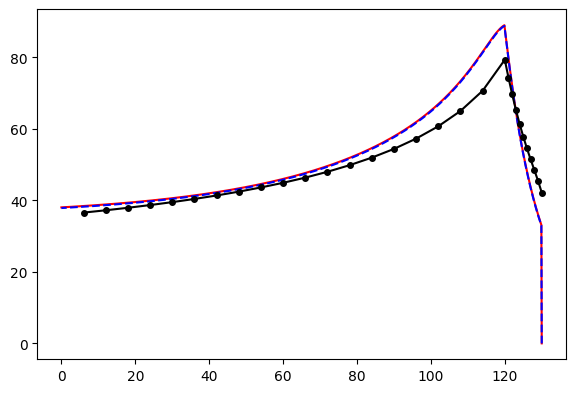

In [34]:
if __name__ == "__main__":
    time_data = time_data_petromod
    hf_data = hf_data_petromod

    result = two_beta_model_v2_dict(
        beta_crust=3,
        beta_mantle=3.0,
        tau=31.8,
        k0_crust=2.6,
        k0_mantle=2.6,
        tc_model='linear',
        plot=True,
        time_data=time_data,
        hf_data=hf_data
    )

    # 'linear', 'sekiguchi', or 'constant'

    # Access results
    # Print table
    print(f"\n{'Time':<6} {'Crust':<6} {'Mantle':<6} {'β_c':<6} {'β_m':<6} "
          f"{'G_c':<10} {'G_m':<10} {'k_surf':<6} {'HF_up':<7} {'HF_simp':<7}")
    print("-" * 60)
    params = results['params_at_observed_times']
    for i, t in enumerate(params['time']):
        print(f"{t:<6.0f} "
              f"{params['crust_th'][i]:<6.2f} "
              f"{params['mantle_th'][i]:<6.2f} "
              f"{params['beta_eff_crust'][i]:<6.2f} "
              f"{params['beta_eff_mantle'][i]:<6.2f} "
              f"{params['G_crust'][i]:<10.2e} "
              f"{params['G_mantle'][i]:<10.2e} "
              f"{params['k_surface'][i]:<6.3f} "
              f"{params['heat_flow_upgraded'][i]:<7.2f} "
              f"{params['heat_flow_simple'][i]:<7.2f}")

# Tectonic water depths 

Tectonic Water Depth Calculations
--------------------------------
Input parameters:
Mantle thickness (hm): 95.0 km
Crustal thickness (hc): 30.0 km
Mantle density (ρm0): 3300 kg/m³
Crustal density (ρc0): 2800 kg/m³
Water density (ρw): 1000 kg/m³
Thermal expansion coeff (α): 3.28e-05 1/°C
Asthenosphere temp (Ta): 1333 °C


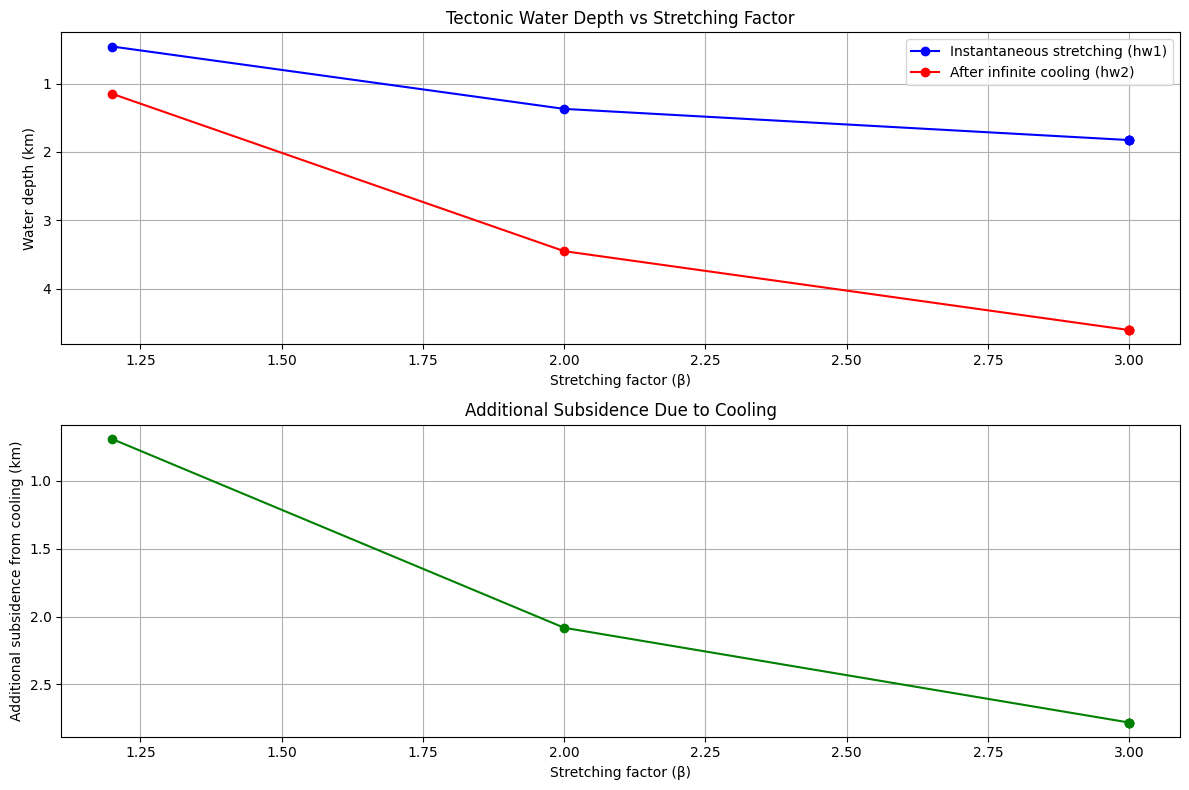


Example values:

For β = 1.20:
  Instantaneous stretching water depth (hw1): 0.46 km
  Infinite cooling water depth (hw2): 1.15 km
  Additional subsidence from cooling: 0.69 km

For β = 3.00:
  Instantaneous stretching water depth (hw1): 1.83 km
  Infinite cooling water depth (hw2): 4.61 km
  Additional subsidence from cooling: 2.78 km


In [35]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_tectonic_water_depths(hm, hc, ρm0, ρc0, ρw, α, Ta, β):
    """
    Calculate tectonic water depths after instantaneous stretching (hw1) and after infinite cooling (hw2).
    
    Parameters:
    hm (float): Mantle thickness before stretching [m]
    hc (float): Crustal thickness before stretching [m]
    ρm0 (float): Mantle density at 0°C [kg/m³]
    ρc0 (float): Crustal density at 0°C [kg/m³]
    ρw (float): Water density [kg/m³]
    α (float): Thermal expansion coefficient [1/°C]
    Ta (float): Asthenosphere temperature [°C]
    β (float): Stretching factor (β > 1)
    
    Returns:
    tuple: (hw1, hw2) water depths in meters
    """
    
    # Calculate hw1 (instantaneous stretching)
    numerator_hw1 = (hm + hc) * (
        (ρm0 - ρc0) * (hc / (hm + hc)) * (1 - (α * Ta * hc) / (2 * hm + 2 * hc)) - 
        (α * Ta * ρm0 / 2)
    ) * (1 - 1/β)
    
    denominator_hw1 = ρm0 * (1 - α * Ta) - ρw
    
    hw1 = numerator_hw1 / denominator_hw1
    
    # Calculate hw2 (infinite cooling)
    term1 = (ρm0 - ρc0) * hc / (ρm0 * (1 - α * Ta) - ρw)
    term2 = (1 - 1/β) - (α * Ta * hc / (2 * hm + 2 * hc)) * (1 - 1/β**2)
    
    hw2 = term1 * term2
    
    return hw1, hw2

def plot_water_depths(hm, hc, ρm0, ρc0, ρw, α, Ta, β_values):
    """
    Plot the relationship between stretching factor (β) and water depths (hw1, hw2)
    """
    hw1_list = []
    hw2_list = []
    cooling_subsidence = []
    
    for β in β_values:
        hw1, hw2 = calculate_tectonic_water_depths(hm, hc, ρm0, ρc0, ρw, α, Ta, β)
        hw1_list.append(hw1/1000)  # convert to km
        hw2_list.append(hw2/1000)  # convert to km
        cooling_subsidence.append((hw2-hw1)/1000)  # convert to km
    
    plt.figure(figsize=(12, 8))
    
    # Plot hw1 and hw2
    plt.subplot(2, 1, 1)
    plt.plot(β_values, hw1_list, 'bo-', label='Instantaneous stretching (hw1)')
    plt.plot(β_values, hw2_list, 'ro-', label='After infinite cooling (hw2)')
    plt.gca().invert_yaxis()
    plt.xlabel('Stretching factor (β)')
    plt.ylabel('Water depth (km)')
    plt.title('Tectonic Water Depth vs Stretching Factor')
    plt.grid(True)
    plt.legend()
    
    # Plot the difference between hw2 and hw1
    plt.subplot(2, 1, 2)
    plt.plot(β_values, cooling_subsidence, 'go-')
    plt.gca().invert_yaxis()
    plt.xlabel('Stretching factor (β)')
    plt.ylabel('Additional subsidence from cooling (km)')
    plt.title('Additional Subsidence Due to Cooling')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return hw1_list, hw2_list, cooling_subsidence

# Example usage
if __name__ == "__main__":
    # Input parameters (example values)
    hm = 95e3      # mantle thickness [m]
    hc = 30e3      # crustal thickness [m]
    ρm0 = 3300      # mantle density at 0°C [kg/m³]
    ρc0 = 2800      # crustal density at 0°C [kg/m³]
    ρw = 1000       # water density [kg/m³]
    α = 3.28e-5     # thermal expansion coefficient [1/°C]
    Ta = 1333       # asthenosphere temperature [°C]
    # β_values = np.linspace(1, 5, 10)  # stretching factors to test
    β_values = np.array([1.2, 2, 3, 3, 3])
    
    # Calculate and plot
    print("Tectonic Water Depth Calculations")
    print("--------------------------------")
    print(f"Input parameters:")
    print(f"Mantle thickness (hm): {hm/1000} km")
    print(f"Crustal thickness (hc): {hc/1000} km")
    print(f"Mantle density (ρm0): {ρm0} kg/m³")
    print(f"Crustal density (ρc0): {ρc0} kg/m³")
    print(f"Water density (ρw): {ρw} kg/m³")
    print(f"Thermal expansion coeff (α): {α} 1/°C")
    print(f"Asthenosphere temp (Ta): {Ta} °C")
    
    hw1_list, hw2_list, cooling_subsidence = plot_water_depths(hm, hc, ρm0, ρc0, ρw, α, Ta, β_values)
    
    # Print some example values
    print("\nExample values:")
    for i, β in enumerate(β_values[::4]):  # print every 4th value
        print(f"\nFor β = {β:.2f}:")
        print(f"  Instantaneous stretching water depth (hw1): {hw1_list[i*4]:.2f} km")
        print(f"  Infinite cooling water depth (hw2): {hw2_list[i*4]:.2f} km")
        print(f"  Additional subsidence from cooling: {cooling_subsidence[i*4]:.2f} km")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Given data
hw1 = 1.83  # km at t=0
hw2 = 4.61 # km at t=∞

# Create synthetic data points for fitting (including intermediate points)
fit_time = np.array([0, 10, 50, 100, 1000])  # Myr (1000 represents ∞)
fit_depths = np.array([hw1, 2.5, 4.0, 4.7, hw2])  # Estimated intermediate values

# Exponential function with fixed hw1 and hw2
def depth_evolution(t, tau):
    return hw1 + (hw2 - hw1) * (1 - np.exp(-t/tau))

# Fit only for tau
popt, pcov = curve_fit(depth_evolution, 
                      fit_time[1:-1],  # Exclude the 0 and ∞ points
                      fit_depths[1:-1],
                      p0=50)  # Initial guess for tau

tau_fit = popt[0]
print(f"Fitted tau: {tau_fit:.1f} Myr")
print(f"Equation: h(t) = {hw1} + {hw2-hw1}(1 - exp(-t/{tau_fit:.1f}))")

# Generate full curve
plot_time = np.linspace(0, 300, 100)
fitted_depths = depth_evolution(plot_time, tau_fit)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(plot_time, fitted_depths, 'b-', label=f'Fitted curve (τ={tau_fit:.1f} Myr)')
plt.scatter([0], [hw1], c='r', s=100, label='Instantaneous (0 Myr)')
plt.scatter([200], [hw2], c='g', s=100, label='Infinite cooling (∞)')

plt.title('Water Depth Evolution', fontsize=14)
plt.xlabel('Time Since Stretching (Myr)', fontsize=12)
plt.ylabel('Water Depth (km)', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
tau_manual = 31.8 # Myr (typical lithospheric cooling timescale)

def depth_curve(t):
    return hw1 + (hw2 - hw1) * (1 - np.exp(-t/tau_manual))

# Plotting
plt.figure(figsize=(10,6))
plt.plot(plot_time, depth_curve(plot_time), 'b-', 
        label=f'Manual τ={tau_manual} Myr')
plt.scatter([0, 200], [hw1, hw2], c='red', s=100)
plt.title('Water Depth Evolution', fontsize=14)
plt.xlabel('Time (Myr)', fontsize=12)
plt.ylabel('Depth (km)', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(True)
plt.legend()
plt.show()

### 1. Initial Instantaneous Subsidence Equations (Jarvis & McKenzie, 1980)

**Instantaneous stretching subsidence ($t=0$):**

$
hw_1 = \frac{(h_m + h_c)\left[(\rho_{m0} - \rho_{c0})\frac{h_c}{h_m + h_c}\left(1 - \frac{\alpha T_a h_c}{2h_m + 2h_c}\right) - \frac{\alpha T_a \rho_{m0}}{2}\right]\left(1 - \frac{1}{\beta}\right)}{\rho_{m0}(1 - \alpha T_a) - \rho_w}
$

**Infinite-time subsidence ($t\rightarrow\infty$):**

$
hw_2 = \frac{(\rho_{m0} - \rho_{c0})h_c}{\rho_{m0}(1 - \alpha T_a) - \rho_w}\left(1 - \frac{1}{\beta} - \frac{\alpha T_a h_c}{2h_m + 2h_c}\left(1 - \frac{1}{\beta^2}\right)\right)
$

### 2. Time-Dependent Thermal Subsidence Extension

**Thermal subsidence component:**

$
S_{thermal}(t) = (hw_2 - hw_1)\left(1 - e^{-t/\tau}\right)
$

where the thermal time constant $\tau$ is:

$
\tau = \frac{(h_m + h_c)^2}{4\pi^2 \kappa}
$

**Total time-dependent subsidence:**

$
hw(t) = hw_1 + S_{thermal}(t) = hw_1 + (hw_2 - hw_1)\left(1 - e^{-t/\tau}\right)
$

### 3. Sediment Loading Correction (Total Subsidence)

$
h_t = \frac{\rho_m - \rho_w}{\rho_m - \rho_s} h_w + \frac{1}{\rho_m - \rho_s}\sum_{i=1}^n \rho_{si} h_{si}
$

where:
- $h_w$ is the tectonic subsidence (either $hw_1$, $hw_2$ or $hw(t)$)
- $\rho_s$ is the average sediment density
- $h_{si}$ and $\rho_{si}$ are thickness and density of individual sediment layers

### 4. Complete Time-Dependent System

$
h_{total}(t) = \frac{\rho_m - \rho_w}{\rho_m - \rho_s}\left[hw_1 + (hw_2 - hw_1)\left(1 - e^{-t/\tau}\right)\right] + \frac{1}{\rho_m - \rho_s}\sum_{i=1}^n \rho_{si} h_{si}
$

### Variable Definitions:

| Symbol | Description | Units |
|--------|-------------|-------|
| $h_m$ | Mantle thickness | m |
| $h_c$ | Crustal thickness | m |
| $\rho_{m0}$ | Mantle density at 0°C | kg/m³ |
| $\rho_{c0}$ | Crustal density at 0°C | kg/m³ |
| $\rho_w$ | Water density | kg/m³ |
| $\alpha$ | Thermal expansion coefficient | 1/°C |
| $T_a$ | Asthenosphere temperature | °C |
| $\beta$ | Stretching factor | - |
| $\kappa$ | Thermal diffusivity | m²/s |
| $t$ | Time since stretching | Myr |
| $\tau$ | Thermal time constant | s |


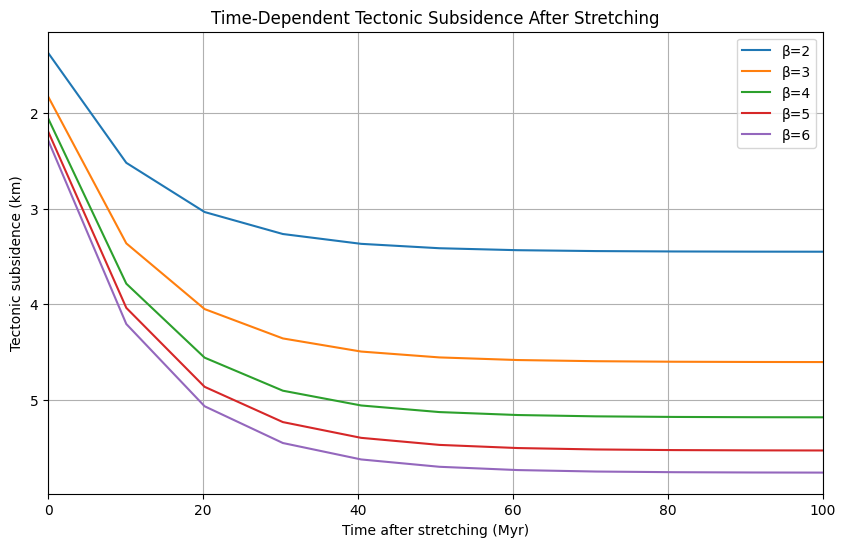


For β=2:
Tectonic subsidence (water-filled): 3.45 km
Total subsidence with 3.0 km sediments: 16.82 km

For β=3:
Tectonic subsidence (water-filled): 4.61 km
Total subsidence with 3.0 km sediments: 19.77 km

For β=4:
Tectonic subsidence (water-filled): 5.18 km
Total subsidence with 3.0 km sediments: 21.25 km

For β=5:
Tectonic subsidence (water-filled): 5.53 km
Total subsidence with 3.0 km sediments: 22.14 km

For β=6:
Tectonic subsidence (water-filled): 5.76 km
Total subsidence with 3.0 km sediments: 22.73 km


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

def calculate_thermal_subsidence_time_series(hm, hc, ρm0, ρc0, ρw, α, Ta, β, κ=1e-6, time_max=100, n_steps=100):
    """
    Calculate time series of tectonic subsidence including thermal cooling phase.
    
    Parameters:
    hm, hc - mantle and crustal thickness [m]
    ρm0, ρc0, ρw - densities [kg/m³]
    α - thermal expansion coeff [1/°C]
    Ta - asthenosphere temp [°C]
    β - stretching factor
    κ - thermal diffusivity [m²/s]
    time_max - maximum time in Myr
    n_steps - number of time steps
    
    Returns:
    tuple: (times, subsidence) where times is in Myr and subsidence in km
    """
    # Convert Myr to seconds for calculations
    seconds_per_myr = 1e6 * 365.25 * 24 * 3600
    
    # Calculate instantaneous components
    hw1, hw2 = calculate_tectonic_water_depths(hm, hc, ρm0, ρc0, ρw, α, Ta, β)
    thermal_subsidence = hw2 - hw1
    
    # Create time array (0 to time_max Myr)
    times = np.linspace(0, time_max, n_steps)  # Myr
    times_sec = times * seconds_per_myr  # Convert to seconds
    
    # Thermal time constant (McKenzie, 1978)
    tau = (hm + hc)**2 / (4 * np.pi**2 * κ)  # Thermal time constant
    
    # Calculate subsidence at each time point
    subsidence = np.zeros_like(times)
    for i, t in enumerate(times_sec):
        if t == 0:
            subsidence[i] = hw1
        else:
            # Thermal subsidence component follows (1 - exp(-t/tau))
            thermal_component = thermal_subsidence * (1 - np.exp(-t/tau))
            subsidence[i] = hw1 + thermal_component
    
    return times, subsidence/1000  # Return times in Myr, subsidence in km

def plot_time_dependent_subsidence(hm, hc, ρm0, ρc0, ρw, α, Ta, β_values, time_max=1000):
    """
    Plot time-dependent subsidence for different β values
    """
    plt.figure(figsize=(10, 6))
    
    for β in β_values:
        times, subsidence = calculate_thermal_subsidence_time_series(
            hm, hc, ρm0, ρc0, ρw, α, Ta, β, time_max=time_max)
        
        plt.plot(times, subsidence, label=f'β={β}')
    plt.gca().invert_yaxis()
    plt.xlabel('Time after stretching (Myr)')
    plt.ylabel('Tectonic subsidence (km)')
    plt.title('Time-Dependent Tectonic Subsidence After Stretching')
    plt.grid(True)
    plt.xlim(0, 100)

    plt.legend()
    plt.show()

# Example usage with time-dependent plots
if __name__ == "__main__":
    # Input parameters
    hm = 95e3      # mantle thickness [m]
    hc = 30e3      # crustal thickness [m]
    ρm0 = 3300      # mantle density [kg/m³]
    ρc0 = 2800      # crustal density [kg/m³]
    ρw = 1000       # water density [kg/m³]
    α = 3.28e-5     # thermal expansion [1/°C]
    Ta = 1333       # asthenosphere temp [°C]
    β_values = [2, 3, 4, 5, 6]  # stretching factors
    
    # Plot time-dependent subsidence
    plot_time_dependent_subsidence(hm, hc, ρm0, ρc0, ρw, α, Ta, β_values, time_max=1000)
    
    # Show sediment loading effect
    ρ_sed = 2400  # Average sediment density [kg/m³]
    h_sed = 3.0   # Sediment thickness [km]
    
    # Calculate tectonic vs total subsidence
    for β in β_values:
        hw1, hw2 = calculate_tectonic_water_depths(hm, hc, ρm0, ρc0, ρw, α, Ta, β)
        hw = hw2/1000  # tectonic subsidence in km
        
        # Total subsidence with sediment loading (eq 3.40)
        ht = ((ρm0 - ρw)/(ρm0 - ρ_sed)) * hw + (ρ_sed/(ρm0 - ρ_sed)) * h_sed
        
        print(f"\nFor β={β}:")
        print(f"Tectonic subsidence (water-filled): {hw:.2f} km")
        print(f"Total subsidence with {h_sed} km sediments: {ht:.2f} km")

50.19478422357412
80


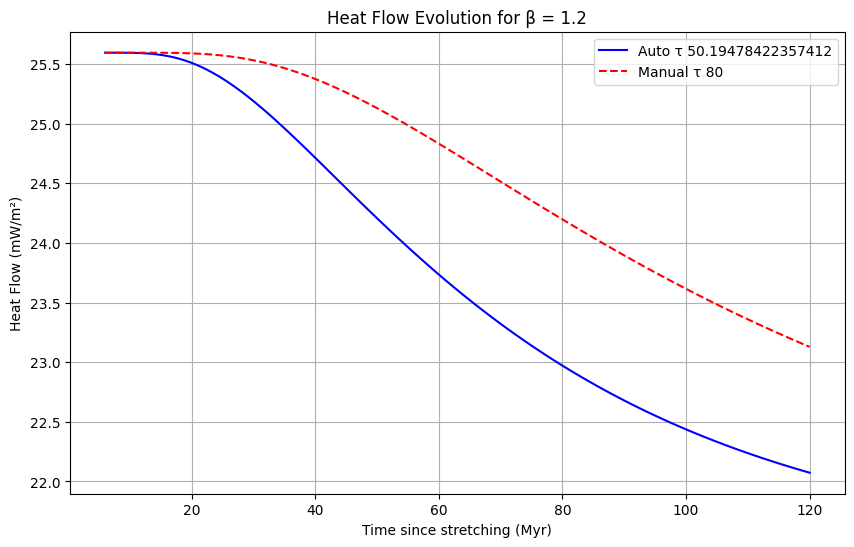

In [37]:
import numpy as np
from typing import Union
import matplotlib.pyplot as plt

def heat_flow_calculation(
    beta: float,
    t: Union[float, np.ndarray],  # Time in Myr
    tau_myr: float = None,        # Thermal time constant in Myr (optional)
    Q_const: float = 63e-3,       # Constant heat flow (W/m²)
    constant: bool = False,       # Flag to return Q_const
    a: float = 125.0,            # Lithosphere thickness (km)
    k: float = 1.0e-6,           # Thermal diffusivity (m²/s)
    lam: float = 2,           # Thermal conductivity (W/m/K)
    T1: float = 1333,            # Asthenosphere temperature (°C)
    n_terms: int = 100           # Number of Fourier terms
) -> Union[float, np.ndarray]:
    """
    Calculate heat flow for lithospheric stretching models with customizable τ.
    
    Parameters:
    - beta: Stretching factor
    - t: Time since stretching (Myr)
    - tau_myr: Thermal time constant (Myr). If None, calculated from a and k.
    - Other parameters as needed
    
    Returns:
    - heat_flux_mucal: Heat flow in µcal/(cm²·s)
    - heat_flux_mw: Heat flow in mW/m²
    """
    if constant:
        heat_flux_mucal = Q_const * 1e7 / 4.184  # Convert to µcal/(cm²·s)
        heat_flux_mw = Q_const * 1e3             # Convert to mW/m²
        return heat_flux_mucal, heat_flux_mw

    # Input validation
    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if np.any(t < 0):
        raise ValueError("Time t must be non-negative")

    # Unit conversions
    MYR_TO_S = 1e6 * 3.154e7  # 1 Myr in seconds
    a_m = a * 1000            # Convert km to m
    
    # Calculate tau if not provided
    if tau_myr is None:
        tau_s = (a_m**2) / (np.pi**2 * k)  # Time constant in seconds
        tau_myr = tau_s / MYR_TO_S          # Convert to Myr
    else:
        tau_s = tau_myr * MYR_TO_S          # Convert Myr to seconds
        # Recalculate k if needed
        k = (a_m**2) / (np.pi**2 * tau_s) if k is None else k
    print(tau_myr)

    # Vectorized Fourier series calculation
    n = np.arange(1, n_terms + 1)
    exponent = -np.outer(n**2, t) / tau_myr
    sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
    Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
    F_sum = np.sum(Cn, axis=0)

    # Calculate heat flow
    heat_flux_w = (lam * T1 / a_m) * (1 + 2 * F_sum)  # W/m²
    heat_flux_mw = heat_flux_w * 1000                 # mW/m²
    heat_flux_mucal = heat_flux_w * 1e7 / 4.184      # µcal/(cm²·s)

    return heat_flux_mucal, heat_flux_mw, tau_myr

# Example usage with different tau values
t_myr = np.linspace(6, 120, 100)
beta = 1.2

# Case 1: Automatic tau calculation
heat_flux_auto_tau = heat_flow_calculation(beta=beta, t=t_myr)
tau_myt_auto = heat_flux_auto_tau[2]
 

# Case 2: Manual tau setting (50 Myr)
tau_myr_manual = 80
heat_flux_manual_tau = heat_flow_calculation(beta=beta, t=t_myr, tau_myr=tau_myr_manual)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_myr, heat_flux_auto_tau[1], 'b-', label=f'Auto τ {tau_myt_auto}')
plt.plot(t_myr, heat_flux_manual_tau[1], 'r--', label=f'Manual τ {tau_myr_manual}')
plt.title(f"Heat Flow Evolution for β = {beta}")
plt.xlabel("Time since stretching (Myr)")
plt.ylabel("Heat Flow (mW/m²)")
plt.grid(True)
plt.legend()
plt.show()

In [38]:
# Extract just the mW/m² values (second element of the returned tuple)
q0 = 5
heat_flux_mw_values = heat_flux_auto_tau[1]  + q0
tau_auto =  heat_flux_auto_tau[2]


heat_flux_manual_tau = heat_flow_calculation(beta=beta, t=t_myr, tau_myr=tau_myr_manual)


# Fit tau to match the model's heat flow curve
from scipy.optimize import curve_fit

# Use the auto-calculated tau as initial guess
# tau_guess = (125 * 1000)**2 / (np.pi**2 * 1e-6) / (1e6 * 3.154e7)  # ~50 Myr
tau_guess = 4
print(tau_guess)
# Define exponential interpolation function
def exponential_interpolation(t, tau):
    """Exponential approach to equilibrium heat flow"""
    return Q_inf + (Q0 - Q_inf) * np.exp(-t/tau)

# Fit to the model's heat flow data
popt, _ = curve_fit(exponential_interpolation, 
                   t_myr, 
                   heat_flux_mw_values,
                   p0=tau_guess)

tau_fit = popt[0]
print(f"Fitted τ: {tau_fit:.1f} Myr")

# Generate interpolated curve
Q_interp = exponential_interpolation(t_myr, tau_fit)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(t_myr[::-1], heat_flux_mw_values, 'b-', label=f'Full model: tau {tau_auto}')
plt.plot(t_myr[::-1], heat_flux_manual_tau[1], 'r-', label=f'Full model: tau {heat_flux_manual_tau[2]}')
plt.plot(t_myr[::-1], Q_interp, 'r--', label=f'Exponential fit (τ={tau_fit:.1f} Myr)')
plt.plot(time_data, hf_data)
plt.title(f"Heat Flow Interpolation (β={beta})")
plt.xlabel("Time since stretching (Myr)")
plt.ylabel("Heat Flow (mW/m²)")
plt.legend()
plt.grid(True)
plt.show()

# Equation output
print(f"\nInterpolation equation:")
print(f"Q(t) = {Q_inf:.1f} + ({Q0:.1f}-{Q_inf:.1f}) * exp(-t/{tau_fit:.1f})")

80
4


NameError: name 'Q_inf' is not defined